# Basic Analysis — Optimized

In [ ]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.functions import (col, count, when, date_format,
                                   array_contains)
from pyspark.ml.functions import vector_to_array
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
spark = (SparkSession.builder
    .appName("Analysis")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

In [ ]:
post    = spark.read.parquet("gs://reddit-6880017126/post-sentiments.parquet/")
comment = spark.read.parquet("gs://reddit-6880017126/comment-sentiments.parquet/")

# post    = spark.read.parquet("/content/process_data_Sampling_Topic_sampling_post.parquet")
# comment = spark.read.parquet("/content/process_data_Sampling_Topic_sampling_comment.parquet")

In [ ]:
post.printSchema()
comment.printSchema()

root
 |-- content_categories: string (nullable = true)
 |-- created_utc: string (nullable = true)
 |-- author: string (nullable = true)
 |-- is_crosspostable: boolean (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- num_crossposts: long (nullable = true)
 |-- selftext: string (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- title: string (nullable = true)
 |-- upvote_ratio: double (nullable = true)
 |-- ups: long (nullable = true)
 |-- downs: long (nullable = true)
 |-- view_count: string (nullable = true)
 |-- AI_Name: string (nullable = true)
 |-- detected_topics: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- title_clean: string (nullable = true)
 |-- rawPrediction: vector (nullable = true)
 |-- prediction: double (nullable = true)
 |-- row_id: long (nullable = true)

root
 |-- body: string (nullable = true)
 |-- created_utc: string (nullable = true)
 |-- is_submitter: boolean (nullable = true)
 |-- author: string (nullabl

In [ ]:
def check_nulls(df, name):
    null_counts = df.select(
        [count(when(col(c).isNull(), c)).alias(c) for c in df.columns]
    ).collect()[0].asDict()
    print(f"\nNull counts — {name}:")
    for k, v in null_counts.items():
        if v > 0:
            print(f"  {k}: {v}")

check_nulls(post, "Post")
check_nulls(comment, "Comment")


Null counts — Post:
  content_categories: 2627
  view_count: 2627

Null counts — Comment:
  removal_reason: 37369


In [ ]:
# # Sampling for Fix Computational problem.
# comment = comment.sample(withReplacement=False, fraction=0.1, seed=42)

# comment.count()

# Data Preparation & Feature Engineering

All transformations applied in one pass before caching to avoid repeated scans.

In [ ]:
TOPIC = ["usecase_code","usecase_write","usecase_data","usecase_creative",
         "usecase_research","prod_affordable","prod_usability","prod_performance",
         "user_churn","sentiment_positive","sentiment_negative"]

AI_NAMES = ["ChatGPT","Claude","DeepSeek","Gemini","Grok"]

TOPICS_8 = ["usecase_code","usecase_write","usecase_data","usecase_creative",
             "usecase_research","prod_affordable","prod_usability","prod_performance"]

def add_features(df, drop_cols):
    """Drop, rename, add month-year, topic dummies, sentiment_score."""
    df = df.drop(*drop_cols).withColumnRenamed("prediction", "sentiment")
    df = df.withColumn("month-year", date_format(col("created_utc"), "MMM yyyy"))
    for t in TOPIC:
        df = df.withColumn(t, when(array_contains(col("detected_topics"), t), 1).otherwise(0))
    # sentiment_score from rawPrediction
    df = df.withColumn("_arr", vector_to_array("rawPrediction"))
    df = (df
        .withColumn("_s0", F.col("_arr").getItem(0))
        .withColumn("_s1", F.col("_arr").getItem(1))
        .withColumn("_s2", F.col("_arr").getItem(2)))
    df = df.withColumn("_len",
        F.abs(F.col("_s2") - F.col("_s0")) + F.abs(F.col("_s2") - F.col("_s1")))
    return df.drop("_arr","_s0","_s1","_s2")

# ── Post ──────────────────────────────────────────────────────────────────────
post = add_features(post, ["title_clean","row_id"])
len_min_p, len_max_p = post.agg(F.min("_len"), F.max("_len")).first()  # single action
post = post.withColumn("sentiment_score",
    (F.col("_len") - len_min_p) / (len_max_p - len_min_p))
post = post.withColumn("impact_score", F.col("upvote_ratio") * F.col("sentiment_score"))
post = post.drop("_len").cache()
post.count()  # materialise cache
print("Post cached.")

# ── Comment ───────────────────────────────────────────────────────────────────
comment = add_features(comment, ["body_clean","row_id"])
len_min_c, len_max_c = comment.agg(F.min("_len"), F.max("_len")).first()  # single action
comment = comment.withColumn("sentiment_score",
    (F.col("_len") - len_min_c) / (len_max_c - len_min_c))

# offset raw score so it is positive, then min-max scale
min_score = comment.agg(F.min("score")).first()[0]
offset = abs(min_score) + 1 if min_score <= 0 else 0
comment = comment.withColumn("score", col("score") + offset)
sc_min, sc_max = comment.agg(F.min("score"), F.max("score")).first()  # single action
comment = comment.withColumn("scaled_score",
    (col("score") - sc_min) / (sc_max - sc_min) if sc_max > sc_min else F.lit(0.0))
comment = comment.withColumn("impact_score", F.col("score") * F.col("sentiment_score"))
comment = comment.drop("_len").cache()
comment.count()  # materialise cache
print("Comment cached.")
print(f"\nPost score offset applied: {offset}")
print(f"Post len_min={len_min_p:.4f}, len_max={len_max_p:.4f}")
print(f"Comment len_min={len_min_c:.4f}, len_max={len_max_c:.4f}")

Post cached.
Comment cached.

Post score offset applied: 203
Post len_min=0.1968, len_max=19.0419
Comment len_min=0.0474, len_max=86.5105


# Data Exploration

## Sentiment Distribution

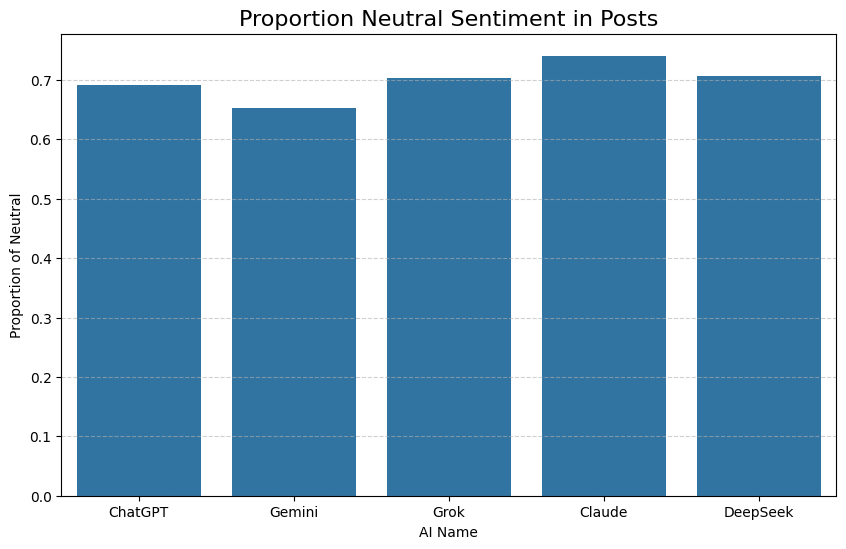

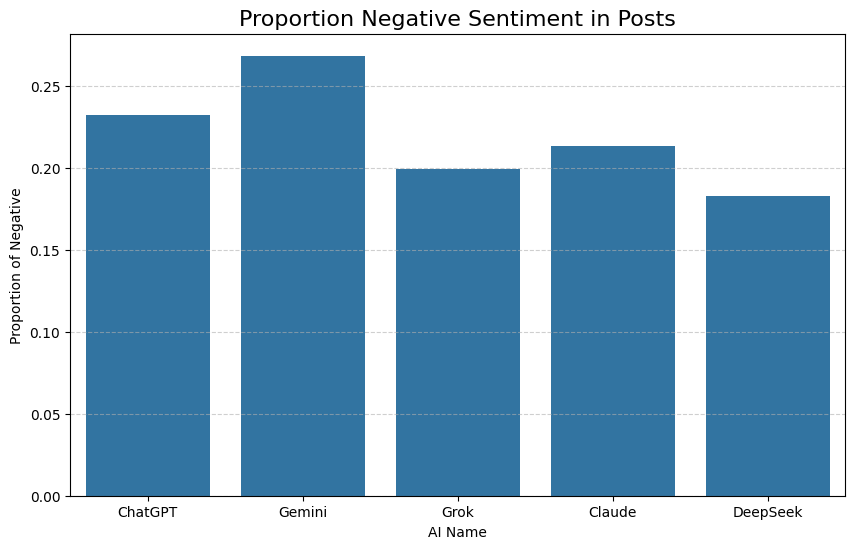

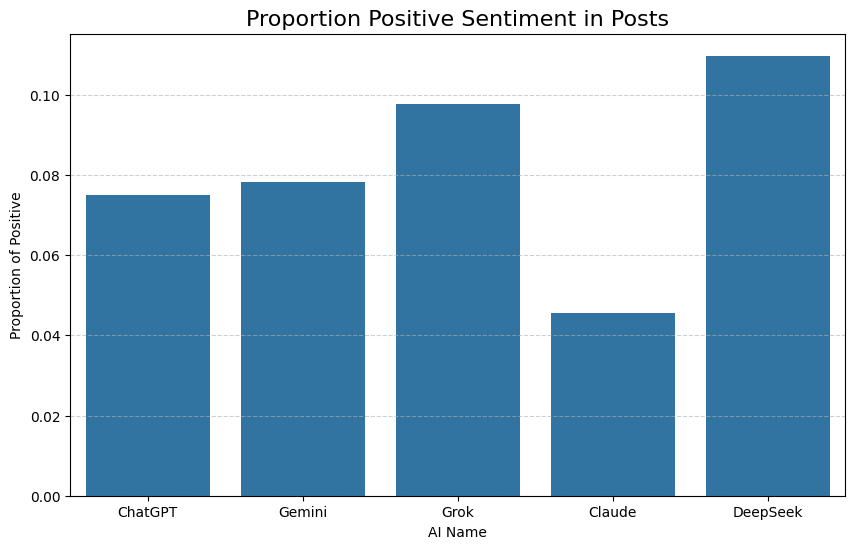

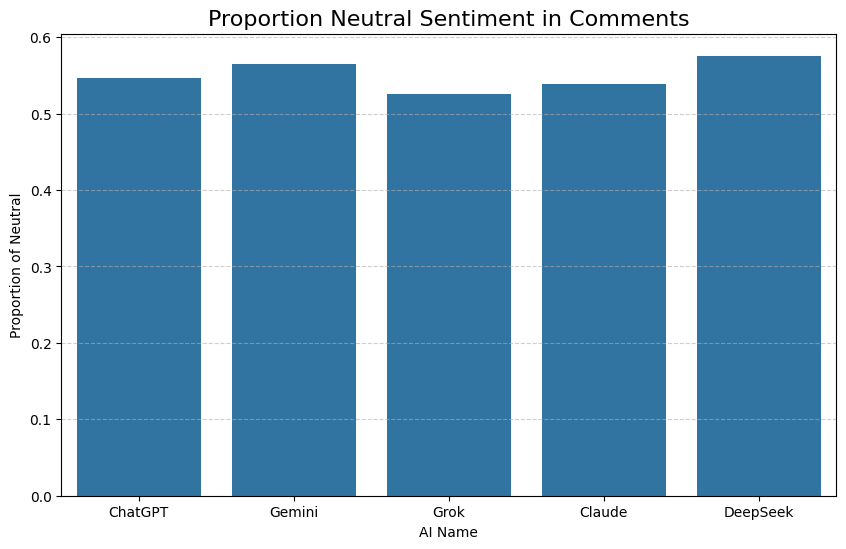

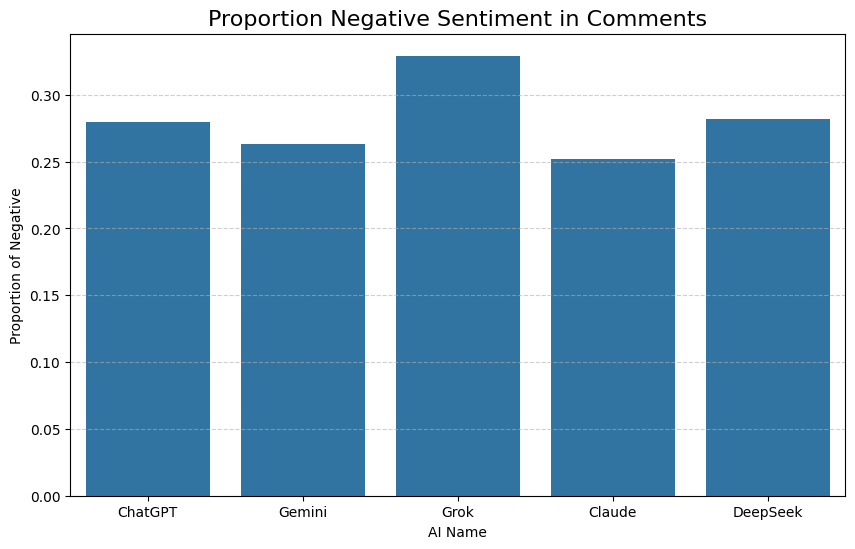

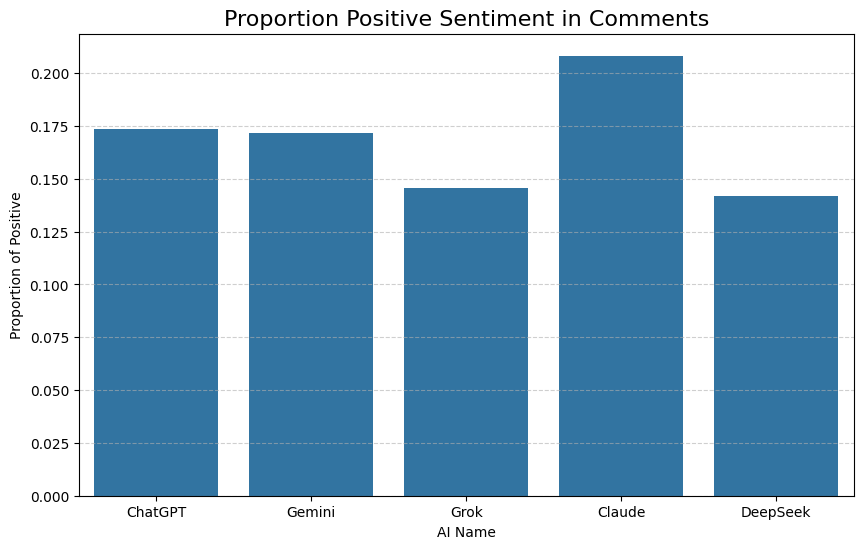

In [ ]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.functions import (col, count, when, date_format,
                                   array_contains)
from pyspark.ml.functions import vector_to_array
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Post sentiment summary ─────────────────────────────
sum_post_sent = (post.groupBy("AI_Name").pivot("sentiment").count()
                 .na.fill(0).toPandas())
sum_post_sent["total"] = sum_post_sent[["0.0","1.0","2.0"]].sum(axis=1)
for lbl in ["0.0","1.0","2.0"]:
    sum_post_sent[f"prop_{lbl}"] = sum_post_sent[lbl] / sum_post_sent["total"]

# ── Comment sentiment summary ─────────────────────────────
sum_com_sent = (comment.groupBy("AI_Name").pivot("sentiment").count()
                .na.fill(0).toPandas())
sum_com_sent["total"] = sum_com_sent[["0.0","1.0","2.0"]].sum(axis=1)
for lbl in ["0.0","1.0","2.0"]:
    sum_com_sent[f"prop_{lbl}"] = sum_com_sent[lbl] / sum_com_sent["total"]

label_map = {"0.0": "Neutral", "1.0": "Negative", "2.0": "Positive"}

for df_pdf, name in [(sum_post_sent,"Post"), (sum_com_sent,"Comment")]:
    for lbl, desc in label_map.items():
        plt.figure(figsize=(10,6))
        sns.barplot(x="AI_Name", y=f"prop_{lbl}", data=df_pdf)
        plt.title(f"Proportion {desc} Sentiment in {name}s", fontsize=16)
        plt.xlabel("AI Name"); plt.ylabel(f"Proportion of {desc}")
        plt.grid(axis="y", linestyle="--", alpha=0.6)
        plt.show()

## Trend Analysis

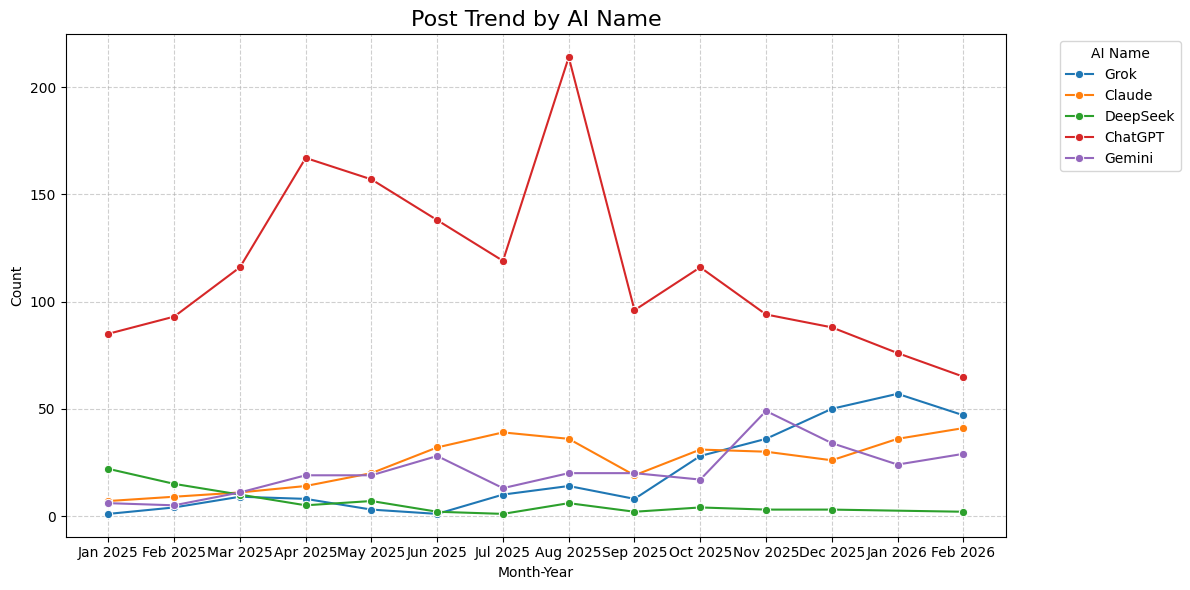

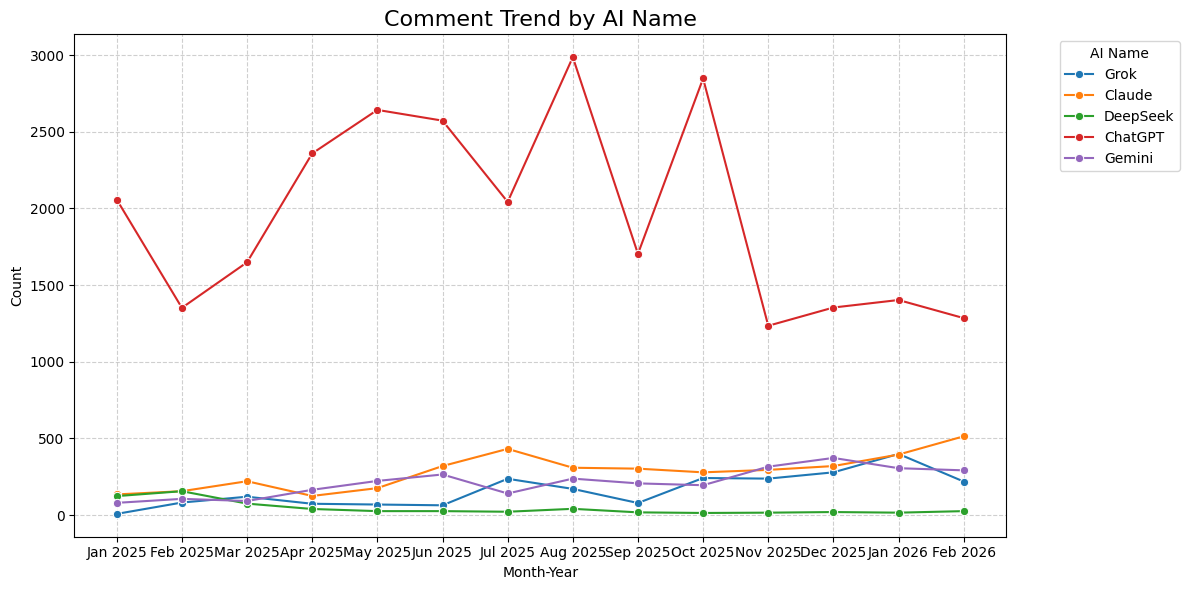

In [ ]:
def trend_line(df, title):
    """Single aggregation → pandas → sorted line chart."""
    pdf = (df.groupBy("month-year","AI_Name").count()
             .na.fill(0).toPandas())
    pdf["dt"] = pd.to_datetime(pdf["month-year"], format="%b %Y")
    pdf = pdf.sort_values("dt")
    plt.figure(figsize=(12,6))
    sns.lineplot(data=pdf, x="month-year", y="count", hue="AI_Name", marker="o")
    plt.title(title, fontsize=16)
    plt.xlabel("Month-Year"); plt.ylabel("Count")
    plt.legend(title="AI Name", bbox_to_anchor=(1.05,1), loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.6); plt.tight_layout(); plt.show()

trend_line(post,    "Post Trend by AI Name")
trend_line(comment, "Comment Trend by AI Name")

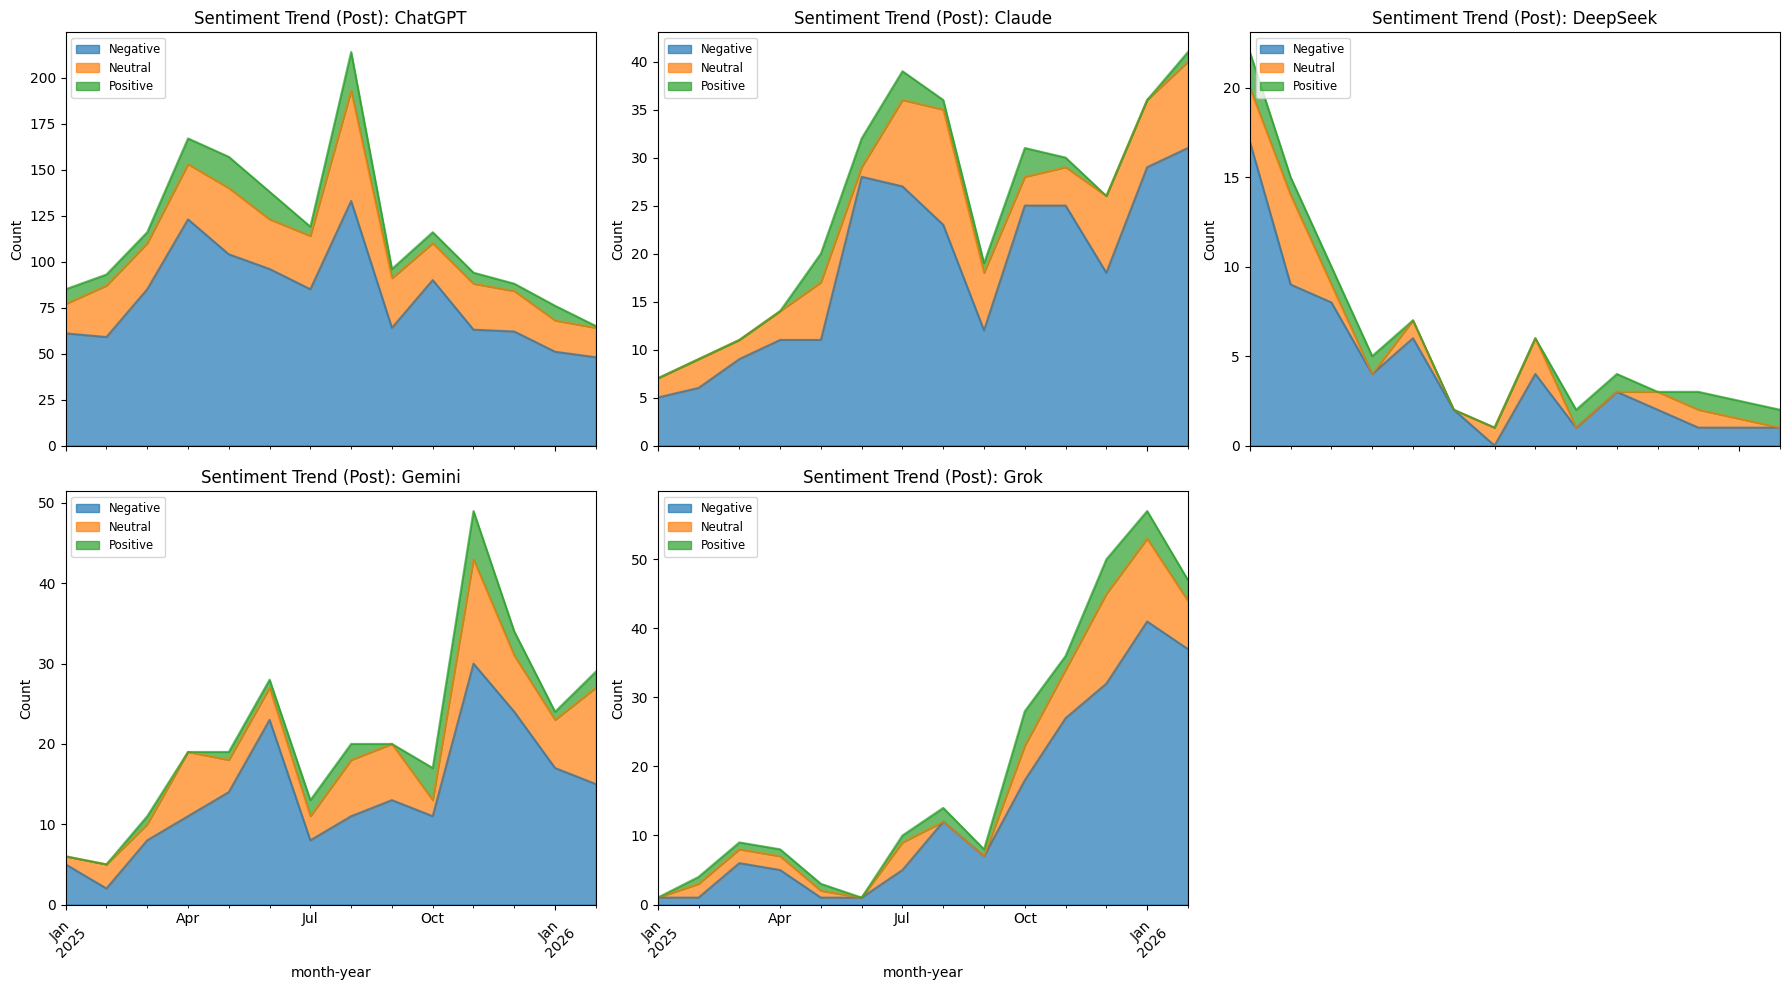

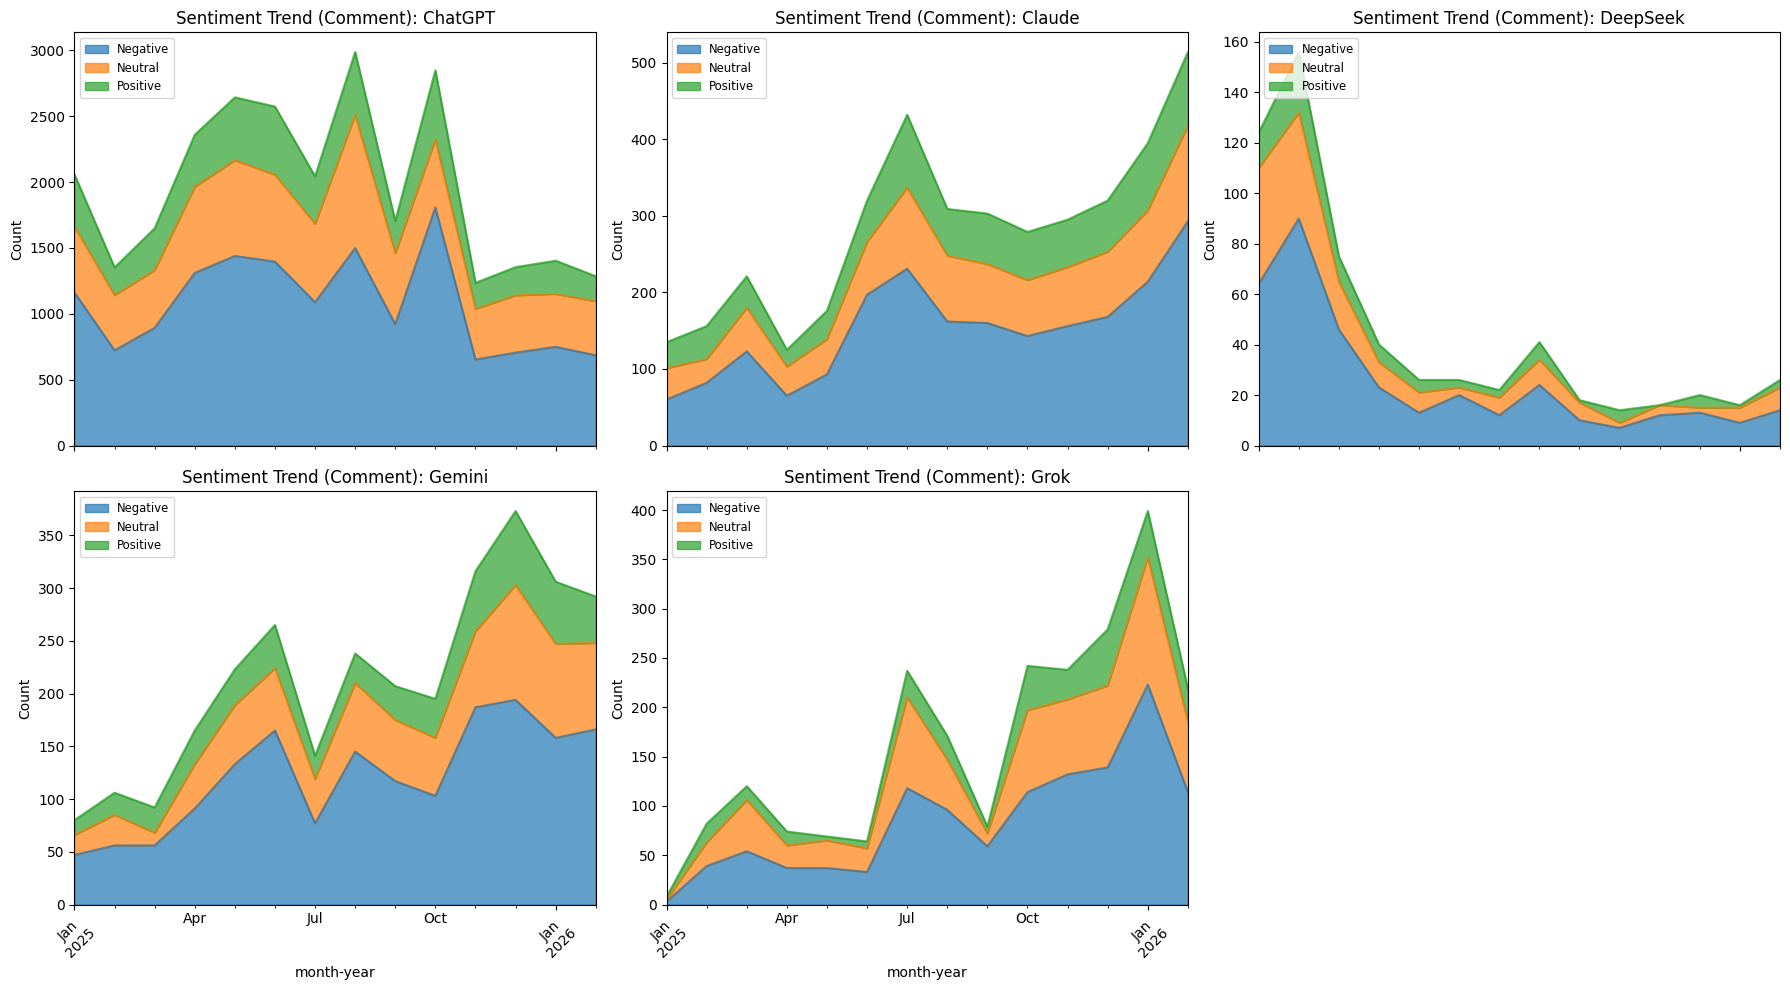

In [ ]:
def stacked_area(df, data_label):
    """One aggregation for all AIs; split in pandas."""
    pdf = (df.groupBy("month-year","AI_Name","sentiment").count()
             .na.fill(0).toPandas())
    pdf["dt"] = pd.to_datetime(pdf["month-year"], format="%b %Y")
    pdf = pdf.sort_values("dt")

    fig, axes = plt.subplots(2, 3, figsize=(18,10), sharex=True)
    axes = axes.flatten()

    for i, ai in enumerate(AI_NAMES):
        sub = pdf[pdf["AI_Name"] == ai]
        if sub.empty:
            axes[i].set_visible(False); continue
        piv = (sub.pivot(index="month-year", columns="sentiment", values="count")
                  .fillna(0))
        piv.index = pd.to_datetime(piv.index, format="%b %Y")
        piv = piv.sort_index()
        piv = piv.rename(columns={0.0:"Neutral",1.0:"Negative",2.0:"Positive"})
        piv.plot.area(ax=axes[i], stacked=True, alpha=0.7)
        axes[i].set_title(f"Sentiment Trend ({data_label}): {ai}", fontsize=12)
        axes[i].set_ylabel("Count")
        axes[i].legend(loc="upper left", fontsize="small")
        axes[i].tick_params(axis="x", rotation=45)

    axes[5].axis("off")
    plt.tight_layout(); plt.show()

stacked_area(post,    "Post")
stacked_area(comment, "Comment")

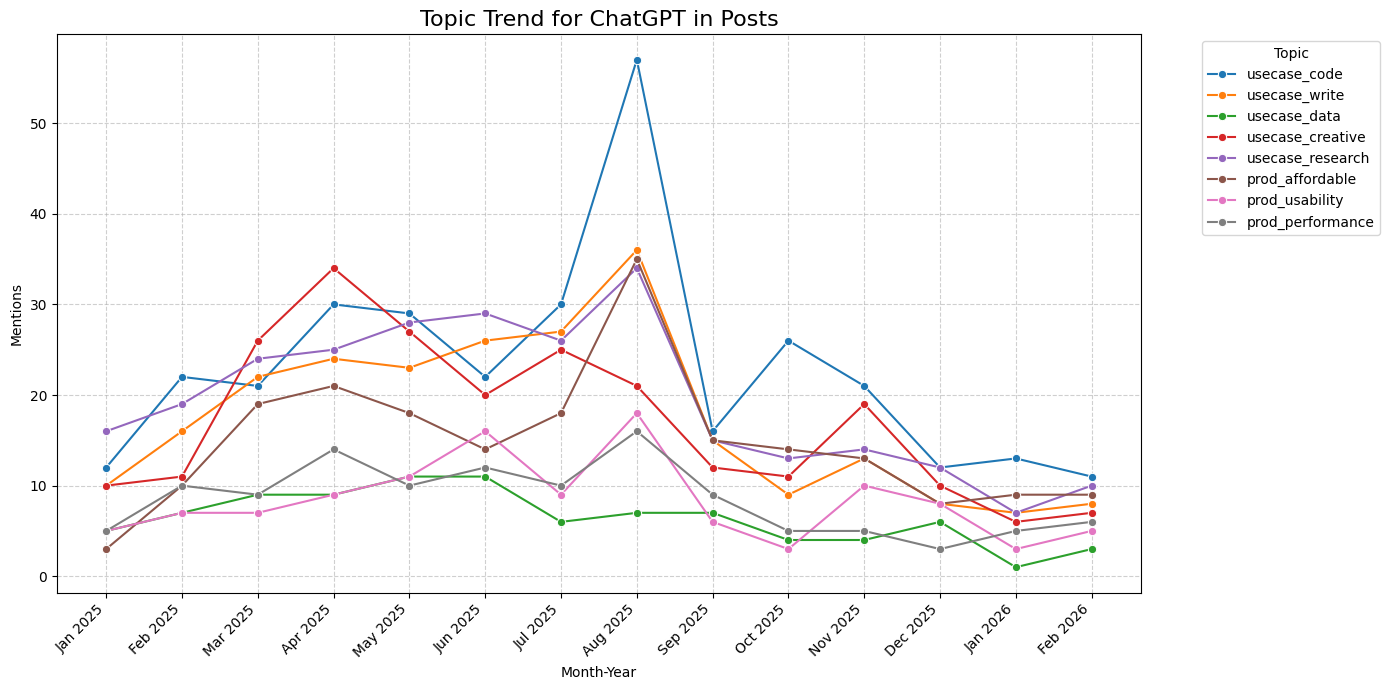

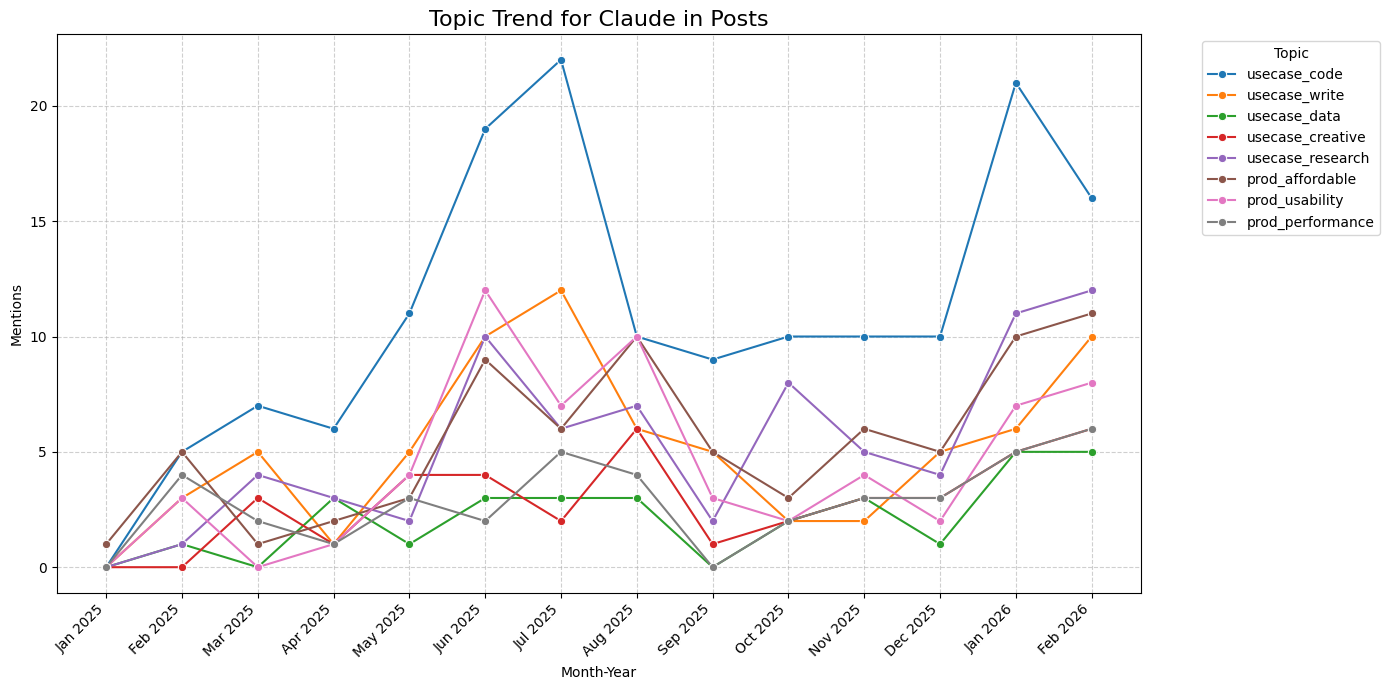

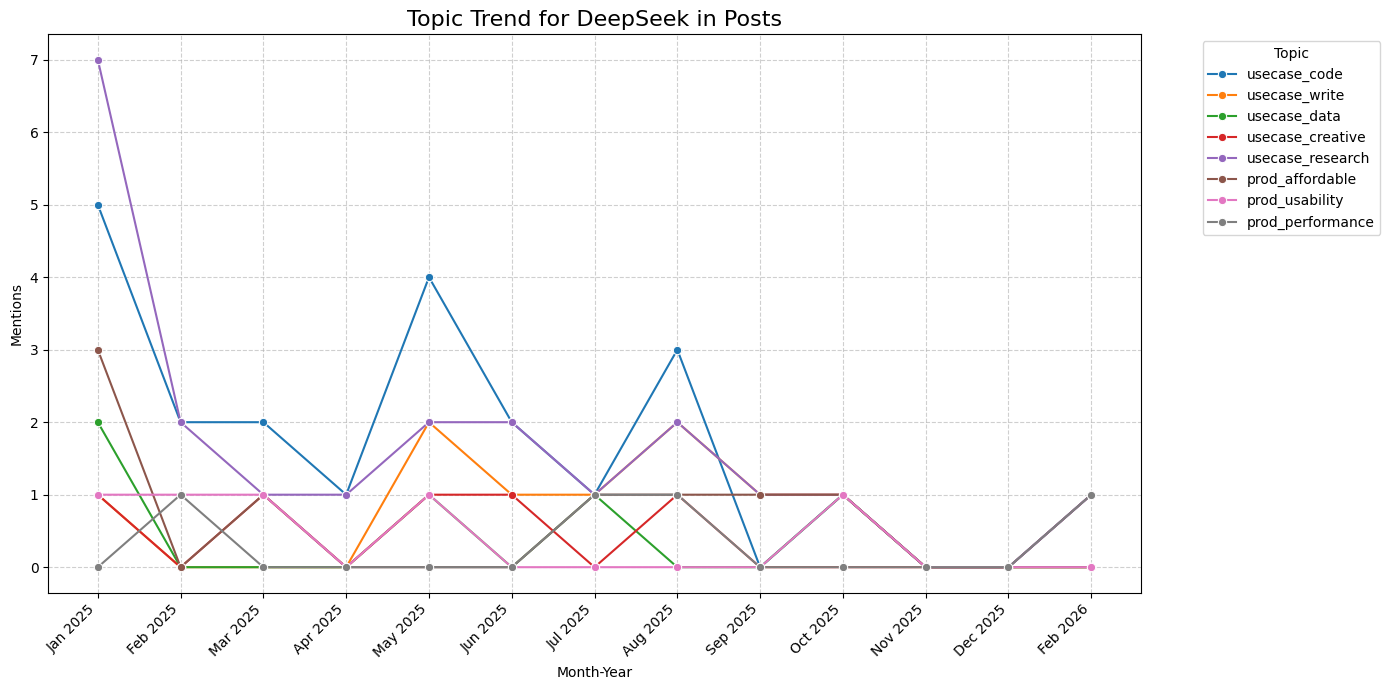

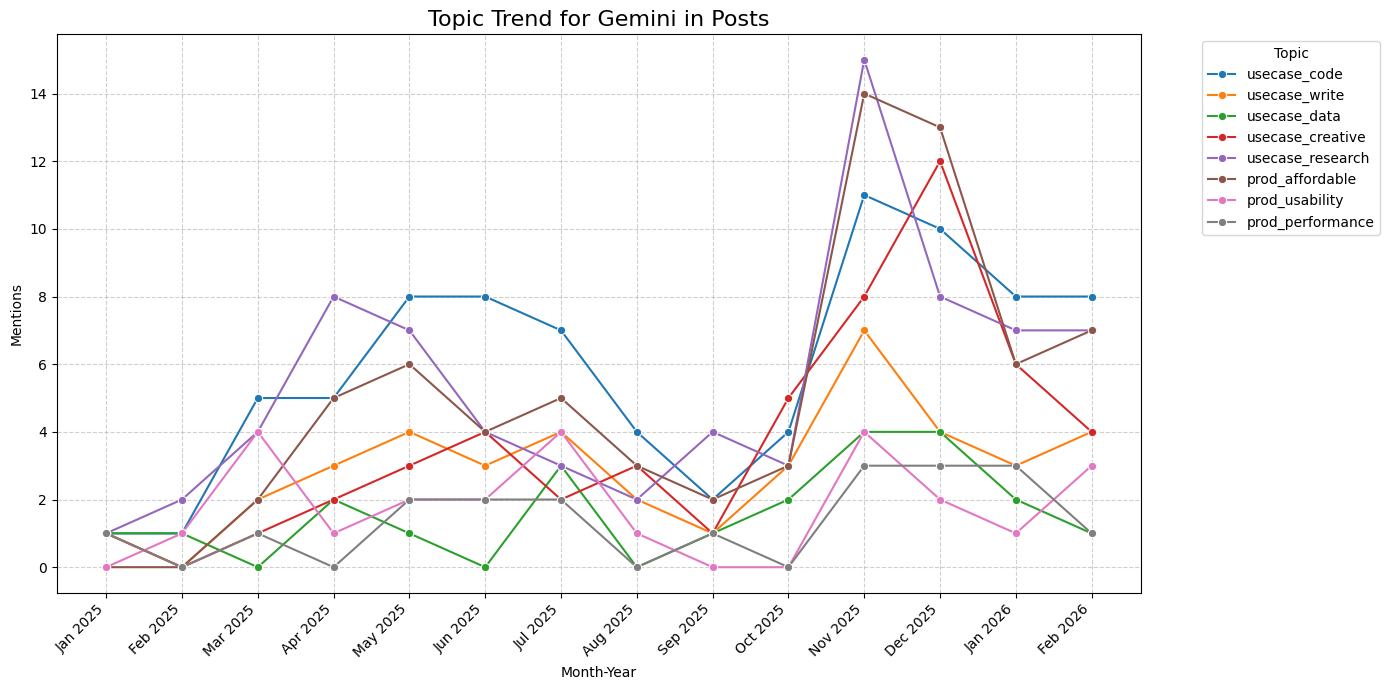

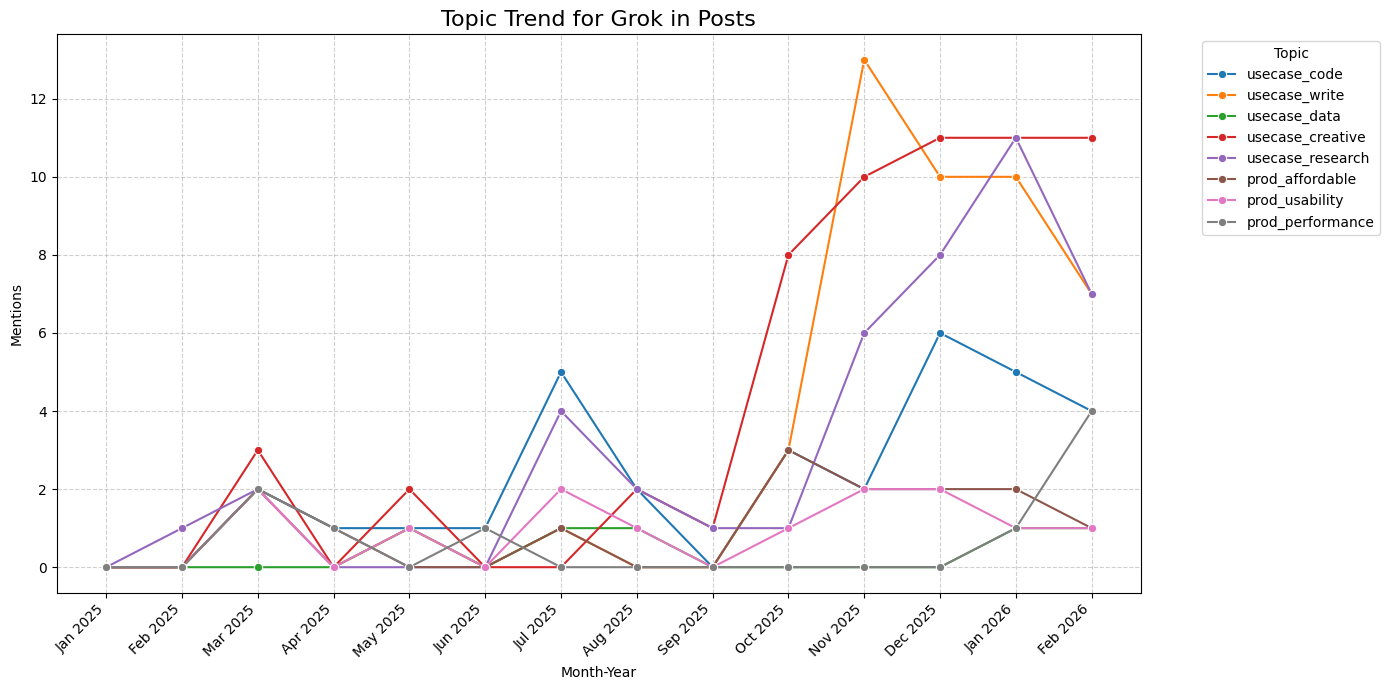

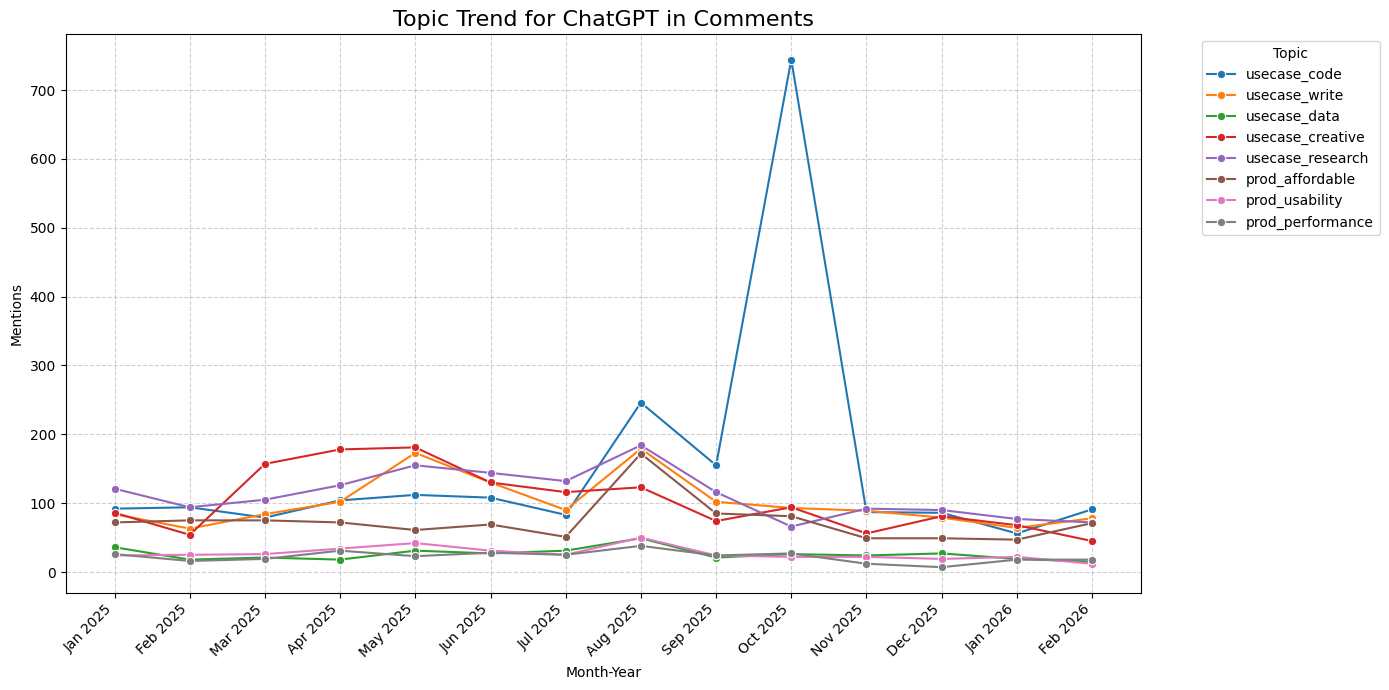

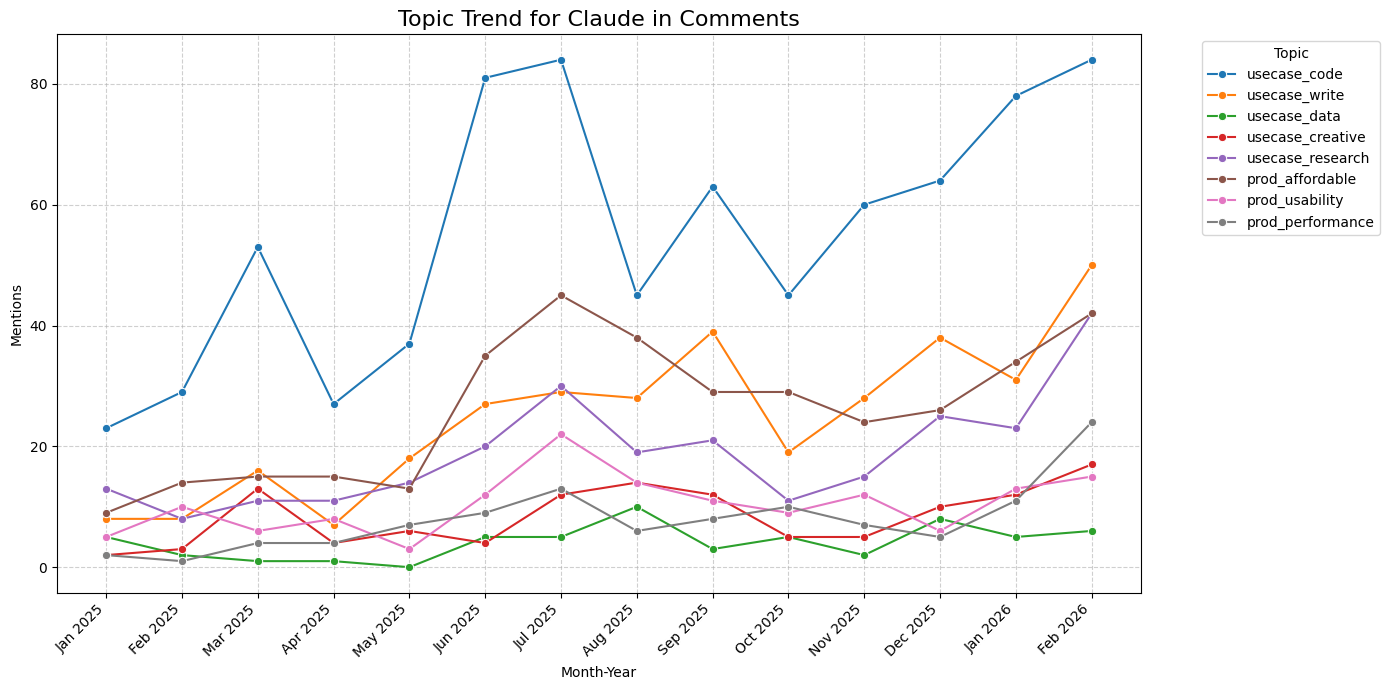

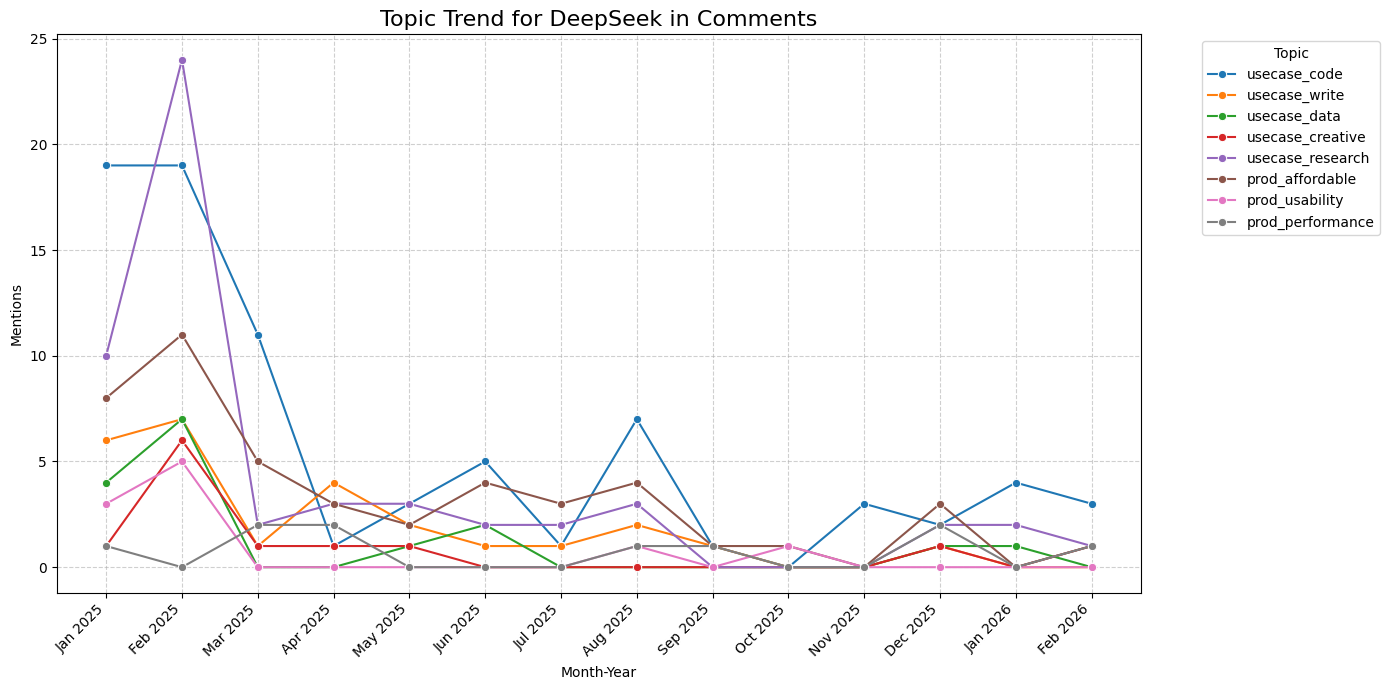

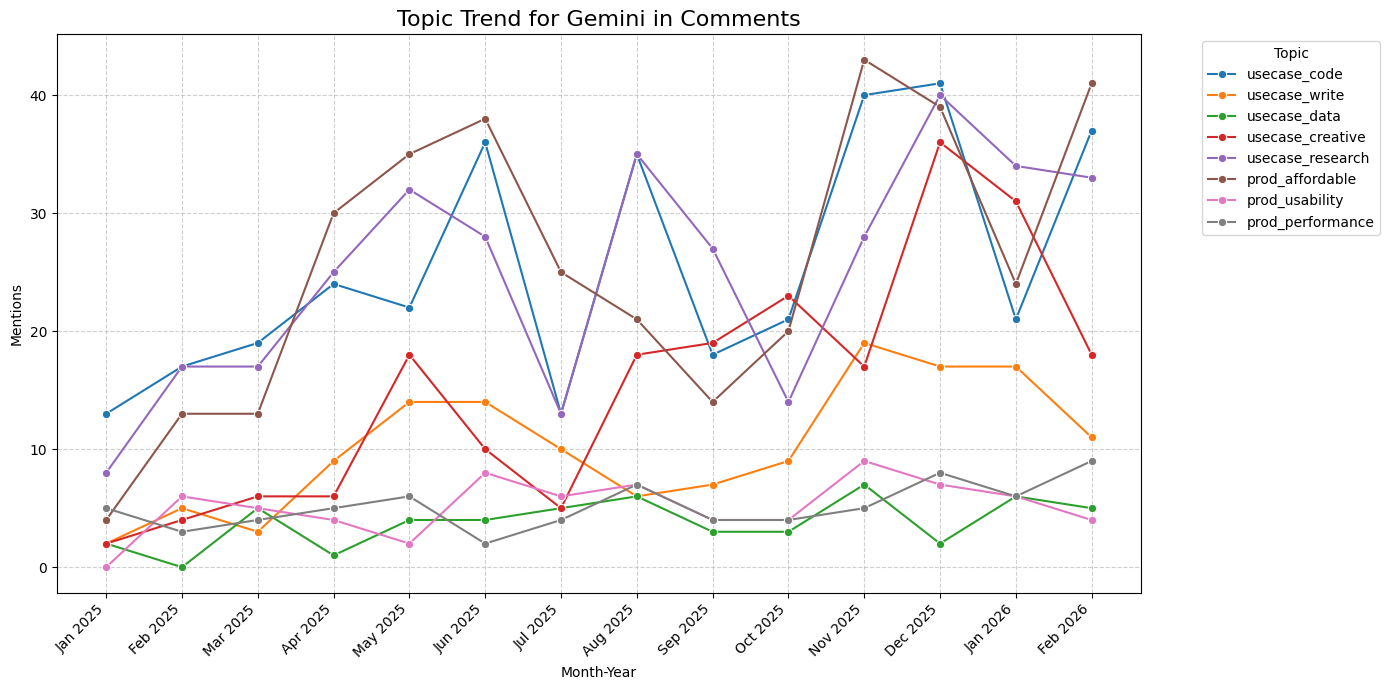

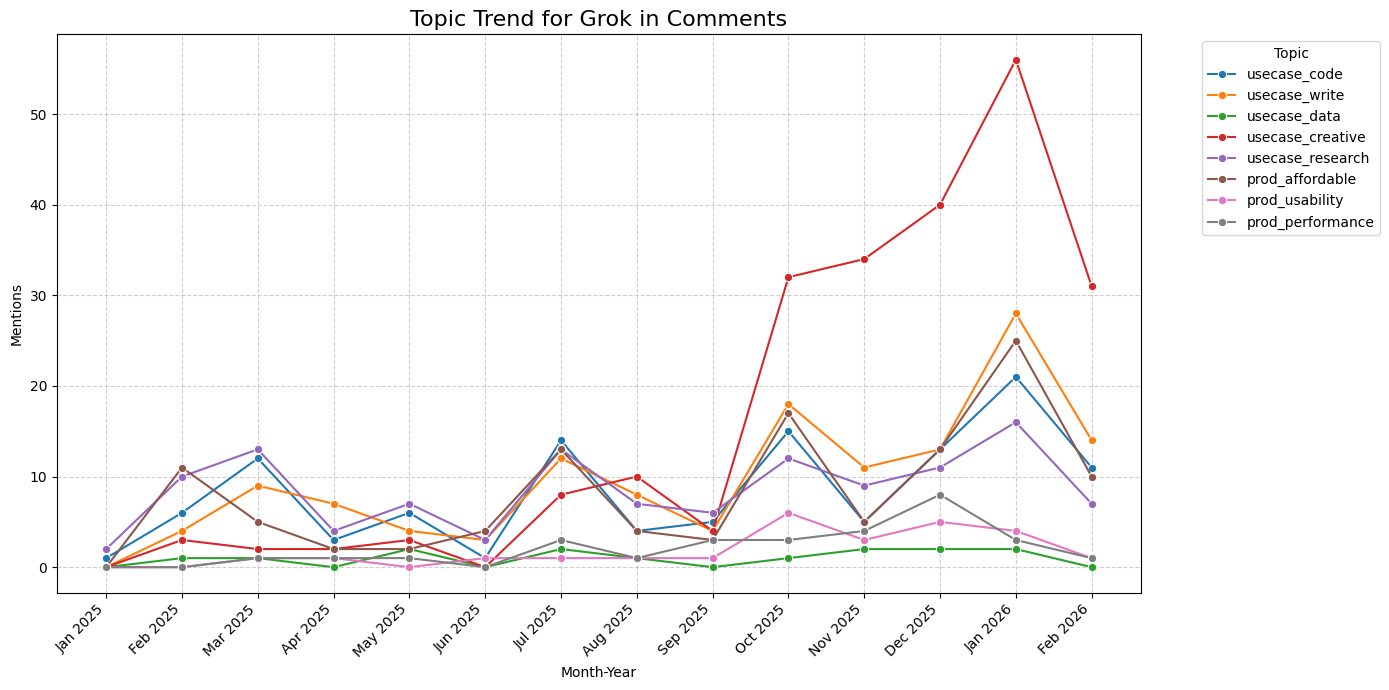

In [ ]:
def topic_trend(df, data_label):
    """One aggregation for all AIs and topics; split in pandas."""
    agg_exprs = [F.sum(F.col(t)).alias(t) for t in TOPICS_8]
    pdf = (df.groupBy("month-year","AI_Name").agg(*agg_exprs)
             .toPandas())
    pdf["dt"] = pd.to_datetime(pdf["month-year"], format="%b %Y")
    pdf = pdf.sort_values("dt").drop(columns=["dt"])

    for ai in AI_NAMES:
        sub = pdf[pdf["AI_Name"] == ai].drop(columns=["AI_Name"])
        if sub.empty: continue
        melted = sub.melt(id_vars=["month-year"], value_vars=TOPICS_8,
                          var_name="Topic", value_name="Count")
        plt.figure(figsize=(14,7))
        sns.lineplot(data=melted, x="month-year", y="Count", hue="Topic", marker="o")
        plt.title(f"Topic Trend for {ai} in {data_label}s", fontsize=16)
        plt.xlabel("Month-Year"); plt.ylabel("Mentions")
        plt.xticks(rotation=45, ha="right")
        plt.legend(title="Topic", bbox_to_anchor=(1.05,1), loc="upper left")
        plt.grid(True, linestyle="--", alpha=0.6); plt.tight_layout(); plt.show()

topic_trend(post,    "Post")
topic_trend(comment, "Comment")

## Topic EDA

In [ ]:
agg_avg = [F.avg(col(t)).alias(f"avg_{t}") for t in TOPIC]

print("Average Topic Prevalence by AI — Post:")
post.groupBy("AI_Name").agg(*agg_avg).orderBy("AI_Name").show(truncate=False)

print("Average Topic Prevalence by AI — Comment:")
comment.groupBy("AI_Name").agg(*agg_avg).orderBy("AI_Name").show(truncate=False)

Average Topic Prevalence by AI — Post:
+--------+-------------------+-------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+----------------------+----------------------+
|AI_Name |avg_usecase_code   |avg_usecase_write  |avg_usecase_data    |avg_usecase_creative|avg_usecase_research|avg_prod_affordable |avg_prod_usability |avg_prod_performance|avg_user_churn      |avg_sentiment_positive|avg_sentiment_negative|
+--------+-------------------+-------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+----------------------+----------------------+
|ChatGPT |0.19827586206896552|0.15024630541871922|0.05541871921182266 |0.14716748768472906 |0.16748768472906403 |0.1268472906403941  |0.07204433497536945|0.07327586206896551 |0.034482758620689655|0.2524630541871921    |0.08497536945

# Distribution Analysis

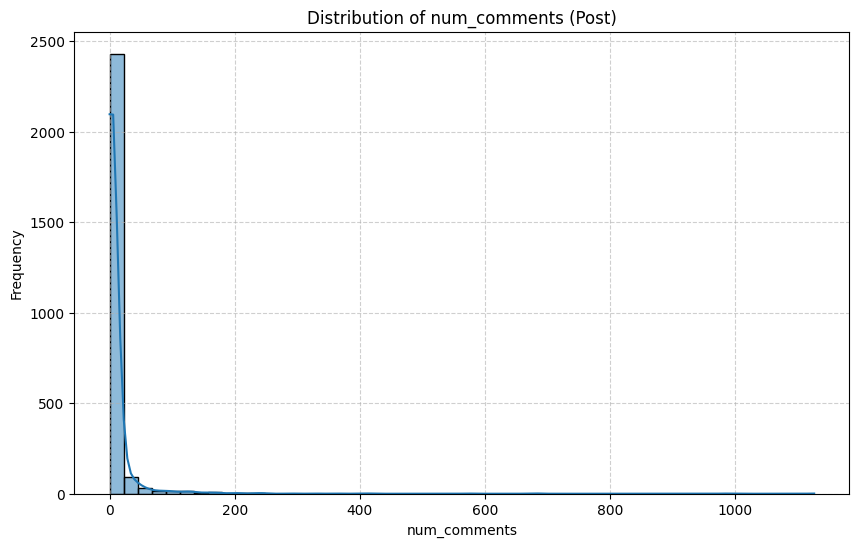

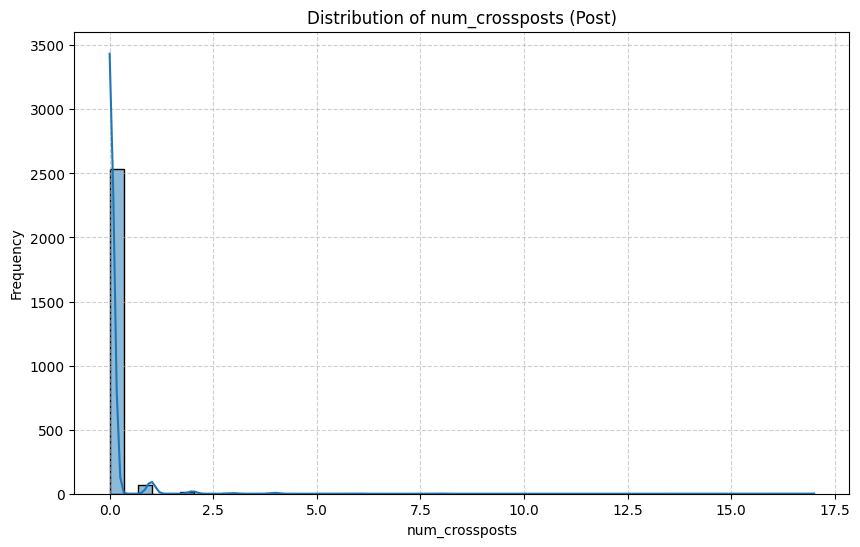

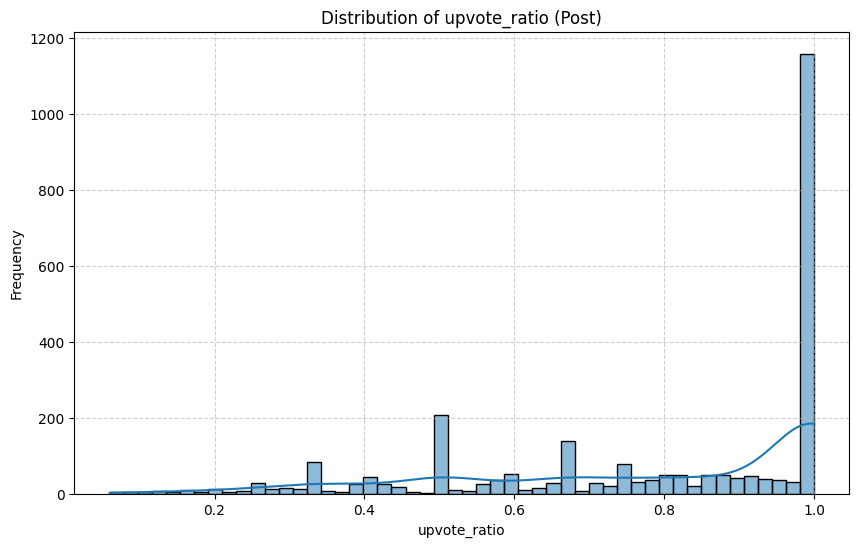

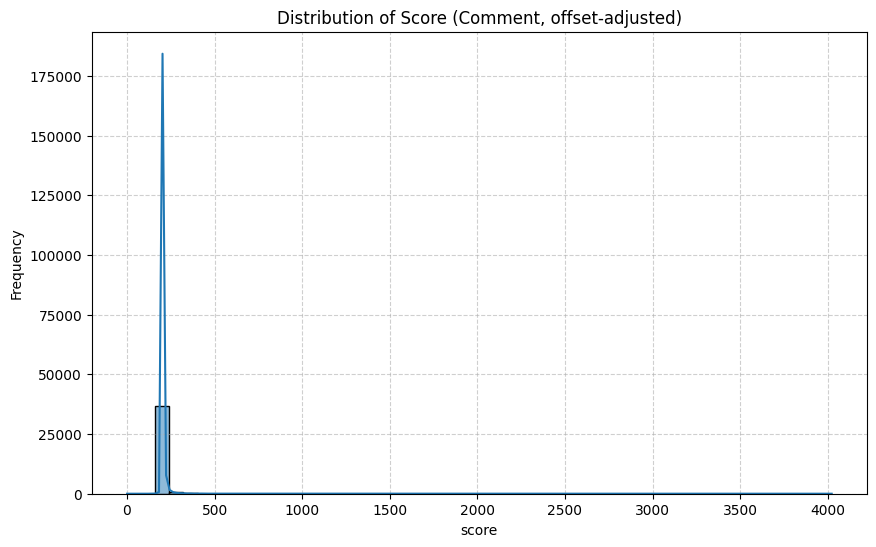

Score statistics (Comment):
+-------+-----------------+
|summary|            score|
+-------+-----------------+
|  count|            37373|
|   mean|208.6909801193375|
| stddev|45.20841237342483|
|    min|                1|
|    25%|              204|
|    50%|              204|
|    75%|              205|
|    max|             4022|
+-------+-----------------+



In [ ]:
def hist_plot(series, title, xlabel):
    plt.figure(figsize=(10,6))
    sns.histplot(series, bins=50, kde=True)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel("Frequency")
    plt.grid(True, linestyle="--", alpha=0.6); plt.show()

# Post distributions — all pulled in one .select().toPandas() call
post_dist = post.select("num_comments","num_crossposts","upvote_ratio").toPandas()
hist_plot(post_dist["num_comments"],    "Distribution of num_comments (Post)",    "num_comments")
hist_plot(post_dist["num_crossposts"],  "Distribution of num_crossposts (Post)",  "num_crossposts")
hist_plot(post_dist["upvote_ratio"],    "Distribution of upvote_ratio (Post)",    "upvote_ratio")

# Comment score distribution
score_pdf = comment.select("score").toPandas()
hist_plot(score_pdf["score"], "Distribution of Score (Comment, offset-adjusted)", "score")
print("Score statistics (Comment):")
comment.select("score").summary().show()

# In-Depth Analysis

## Impact Analysis

+-------+-------------------+
|summary|       impact_score|
+-------+-------------------+
|  count|               2627|
|    min|                0.0|
|    25%|0.12476424932031795|
|    75%|0.29213498342866084|
|    max|                1.0|
+-------+-------------------+



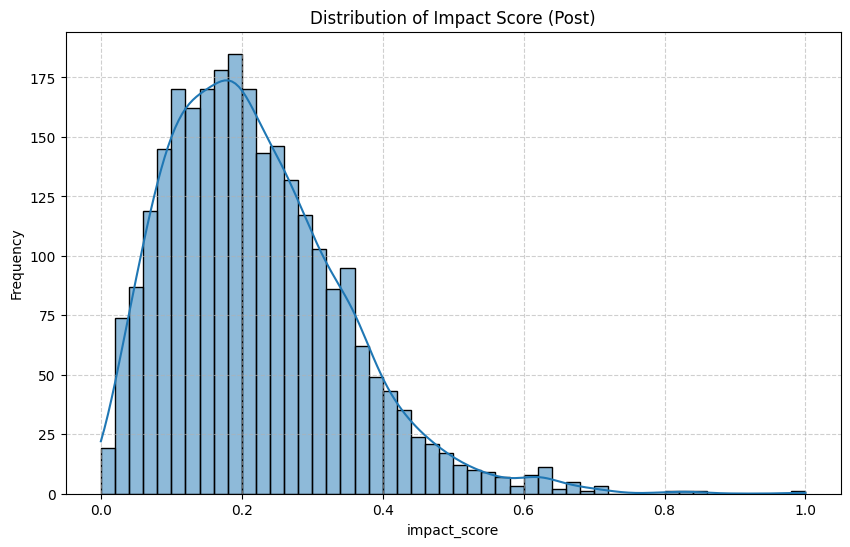

+-------+------------------+
|summary|      impact_score|
+-------+------------------+
|  count|             37373|
|    min|               0.0|
|    25%| 6.649628499257955|
|    75%|15.202209843543935|
|    max| 246.0641193546075|
+-------+------------------+



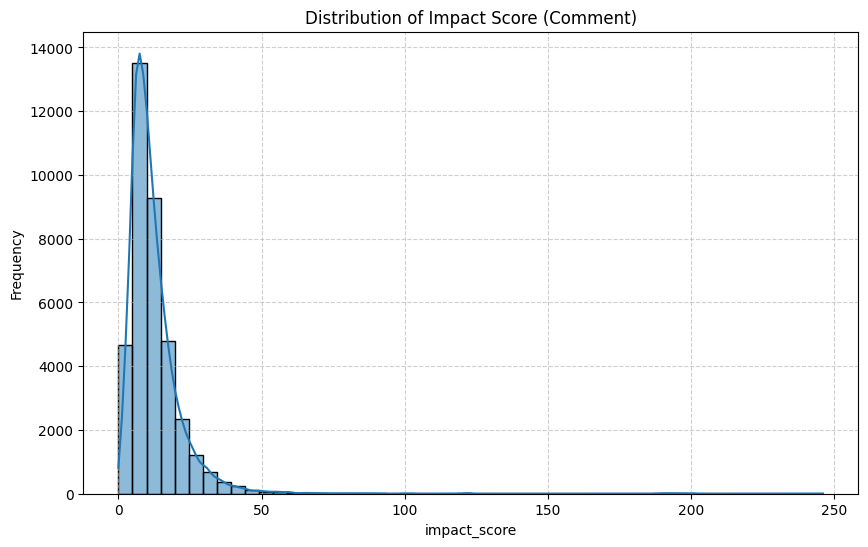

Sentiment Score stats by AI (Post):
+--------+-----+--------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+
|AI_Name |count|min                 |25%                |50%                |75%                |max               |mean               |stddev             |
+--------+-----+--------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+
|ChatGPT |1624 |0.0                 |0.18469851353581226|0.2556424981366645 |0.35023958496420465|0.9081795056710499|0.2746931280066602 |0.1279514929809771 |
|Claude  |351  |0.006405860880649411|0.20560558615781713|0.28205219428374406|0.3639861245413554 |1.0               |0.29872108961627947|0.13719124308906955|
|DeepSeek|82   |0.05144724434372082 |0.1722997657710933 |0.25888523699903493|0.33425913860180817|0.8212370892692717|0.2713300385052865 |0.13739429568134848|
|Gemini  |294  |8.6254

In [ ]:
# Post impact score
post.select("impact_score").summary("count","min","25%","75%","max").show()
hist_plot(post.select("impact_score").toPandas()["impact_score"],
          "Distribution of Impact Score (Post)", "impact_score")

# Comment impact score
comment.select("impact_score").summary("count","min","25%","75%","max").show()
hist_plot(comment.select("impact_score").toPandas()["impact_score"],
          "Distribution of Impact Score (Comment)", "impact_score")

# Sentiment score stats by AI (Post)
print("Sentiment Score stats by AI (Post):")
post.groupBy("AI_Name").agg(
    F.count("sentiment_score").alias("count"),
    F.min("sentiment_score").alias("min"),
    F.expr("percentile_approx(sentiment_score, 0.25)").alias("25%"),
    F.expr("percentile_approx(sentiment_score, 0.50)").alias("50%"),
    F.expr("percentile_approx(sentiment_score, 0.75)").alias("75%"),
    F.max("sentiment_score").alias("max"),
    F.avg("sentiment_score").alias("mean"),
    F.stddev("sentiment_score").alias("stddev")
).orderBy("AI_Name").show(truncate=False)

## Per-AI / Sentiment / Topic — Average Impact Score (Post)

Single `groupBy` aggregation replaces ~240 individual Spark jobs.

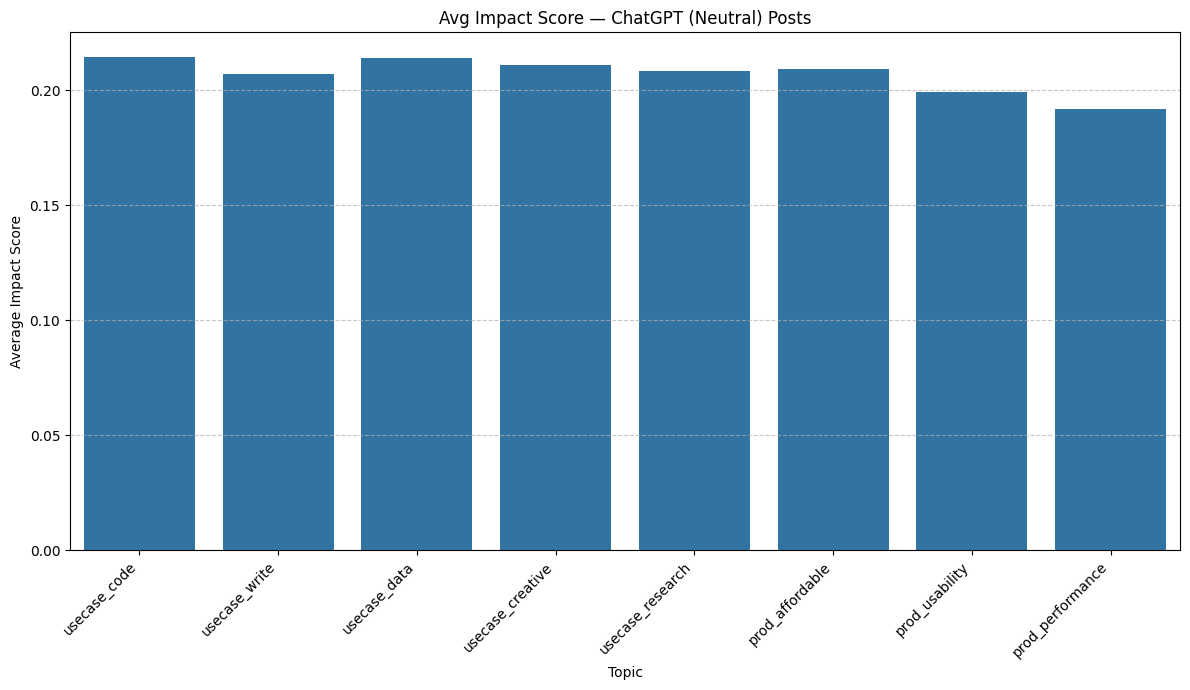

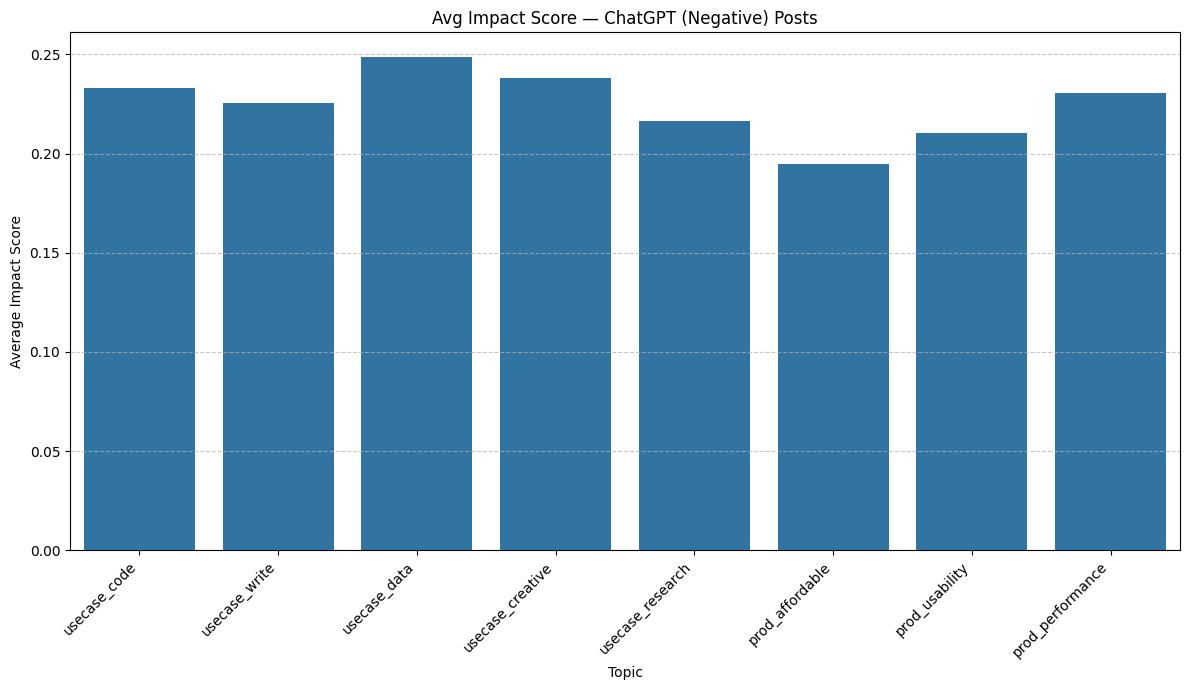

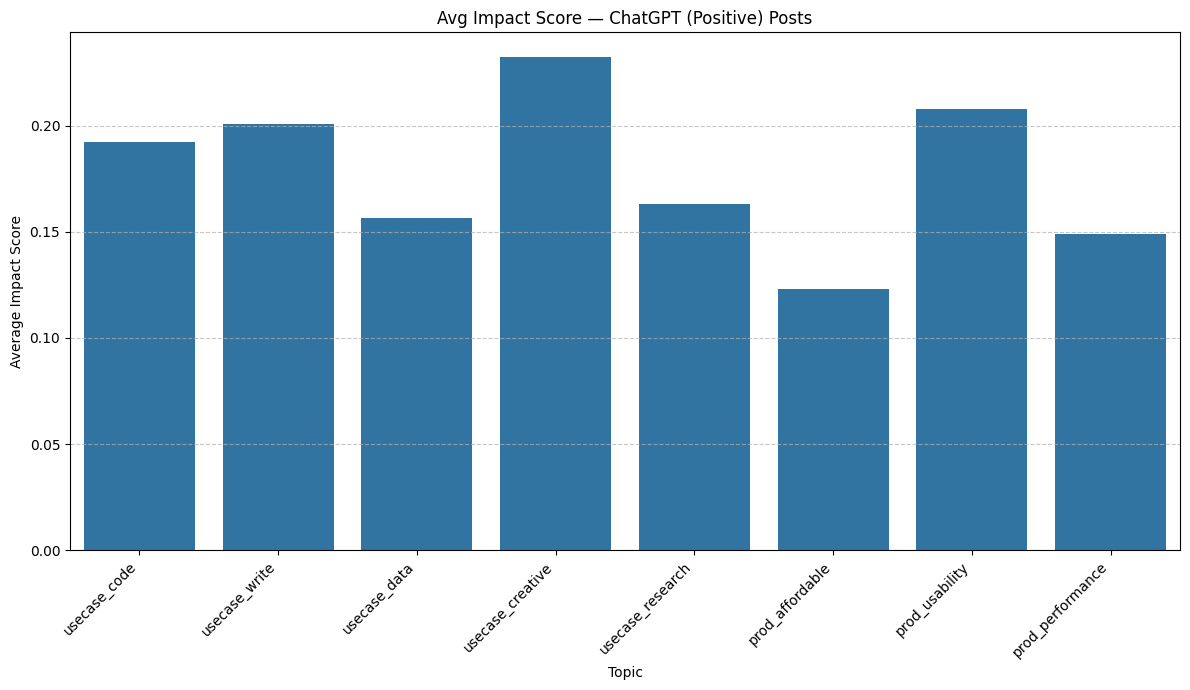

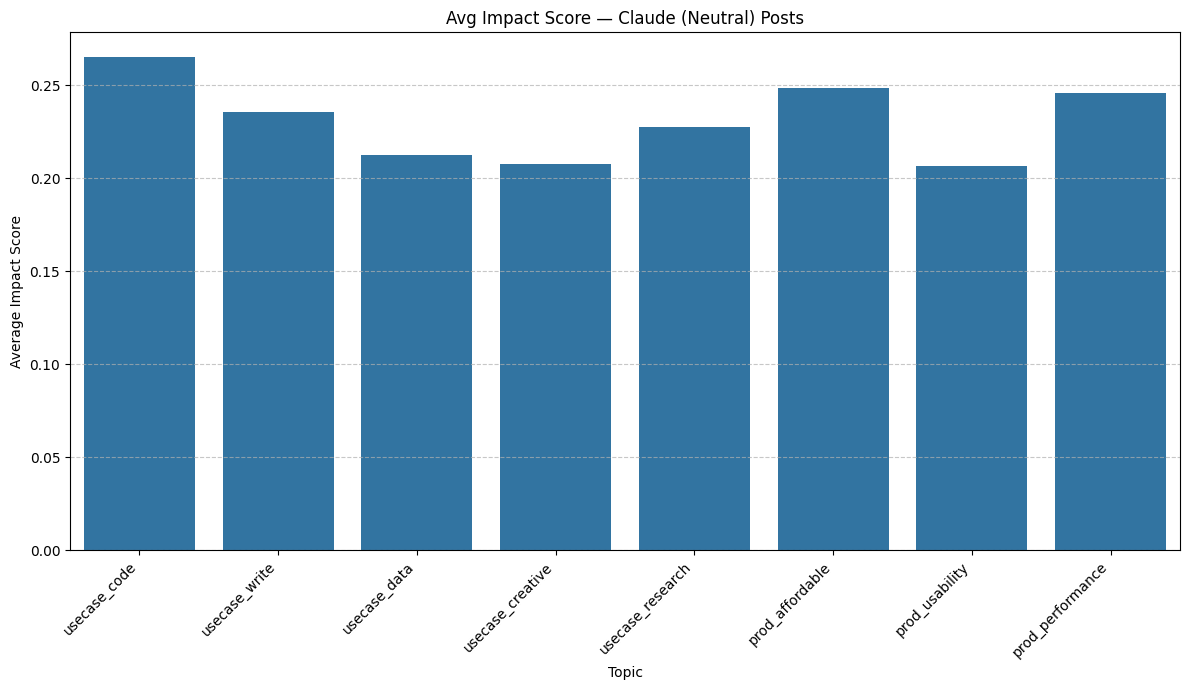

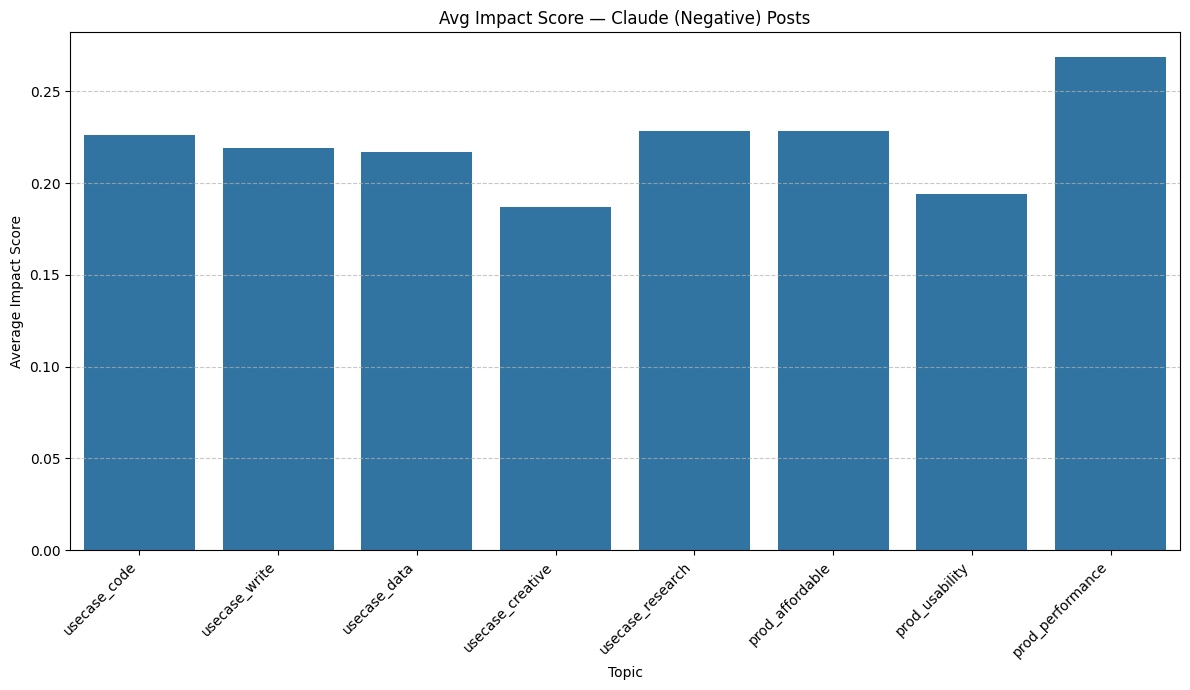

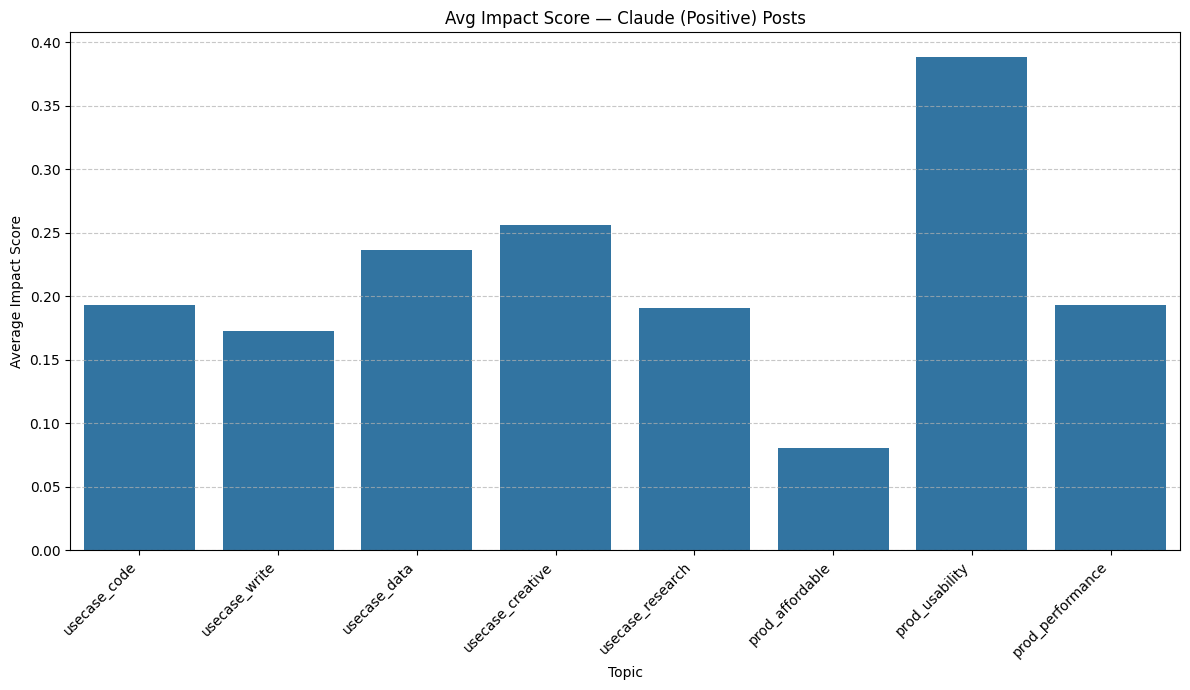

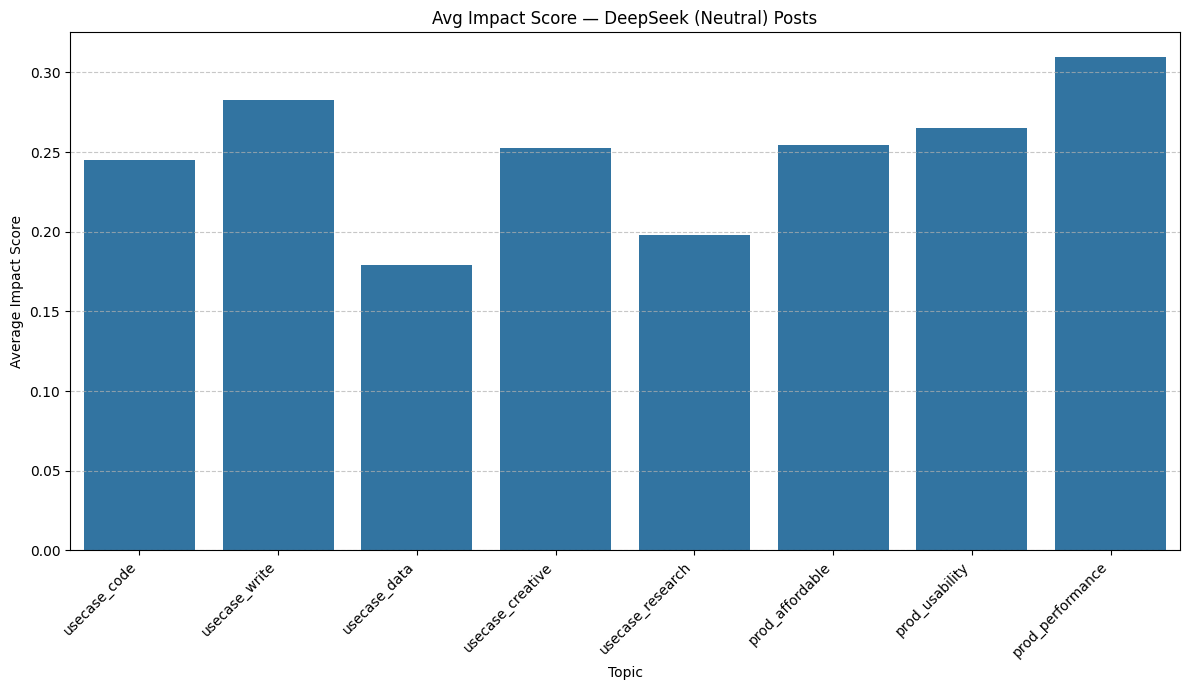

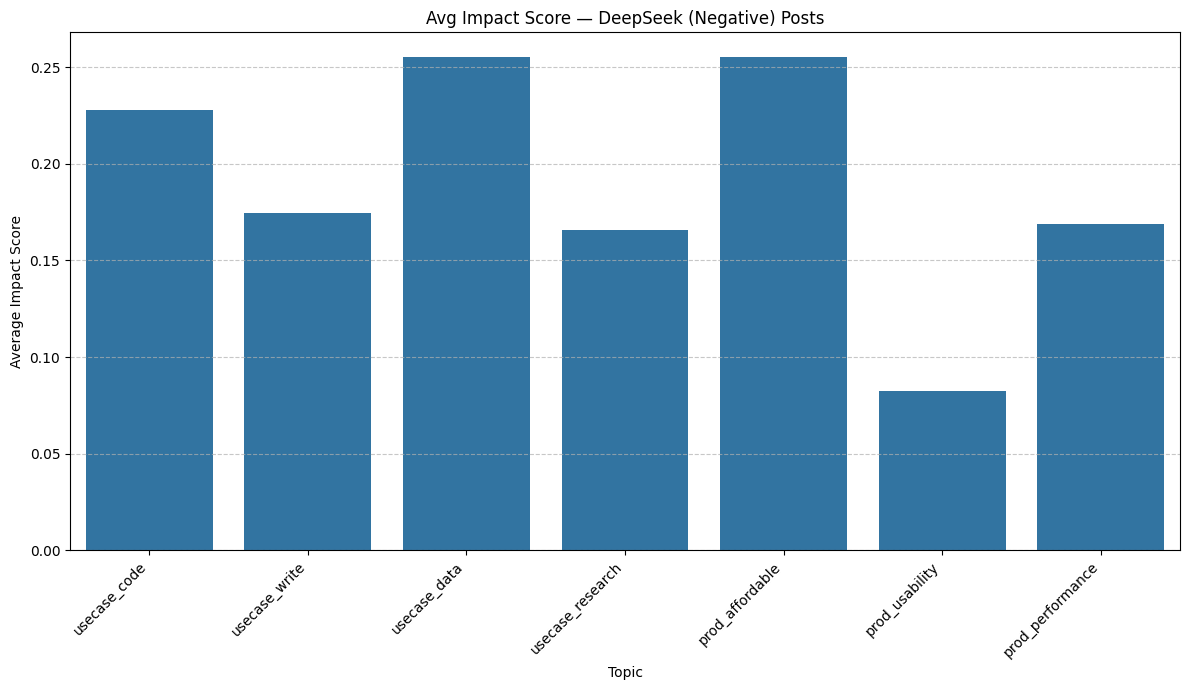

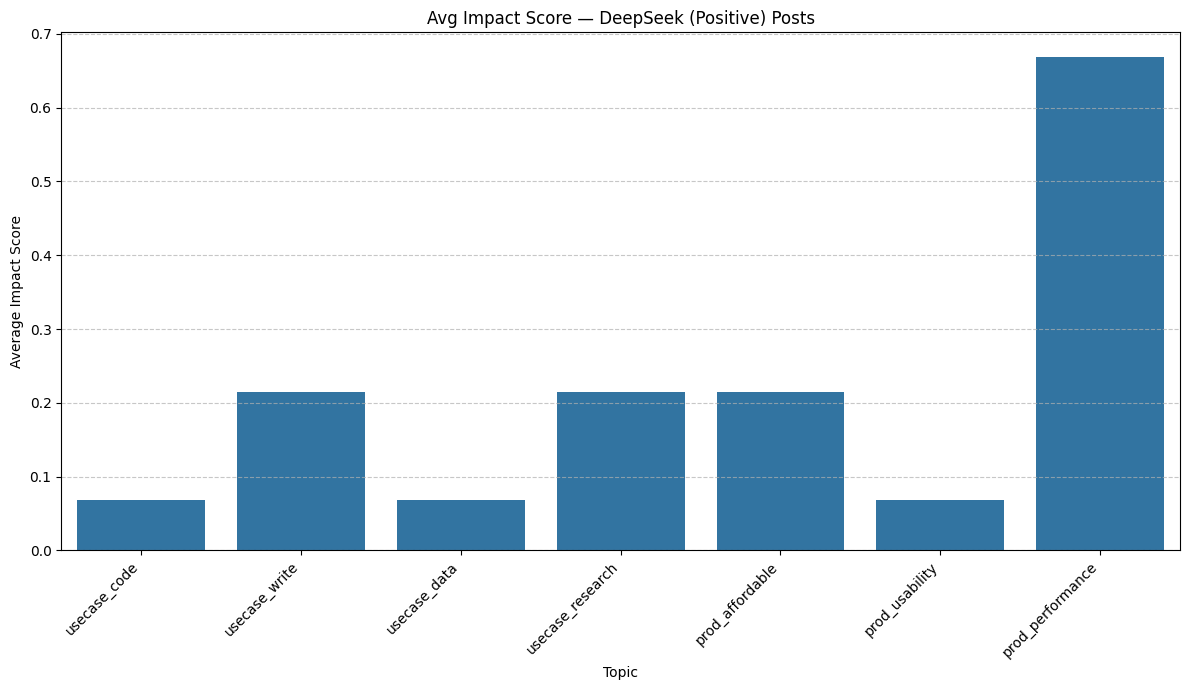

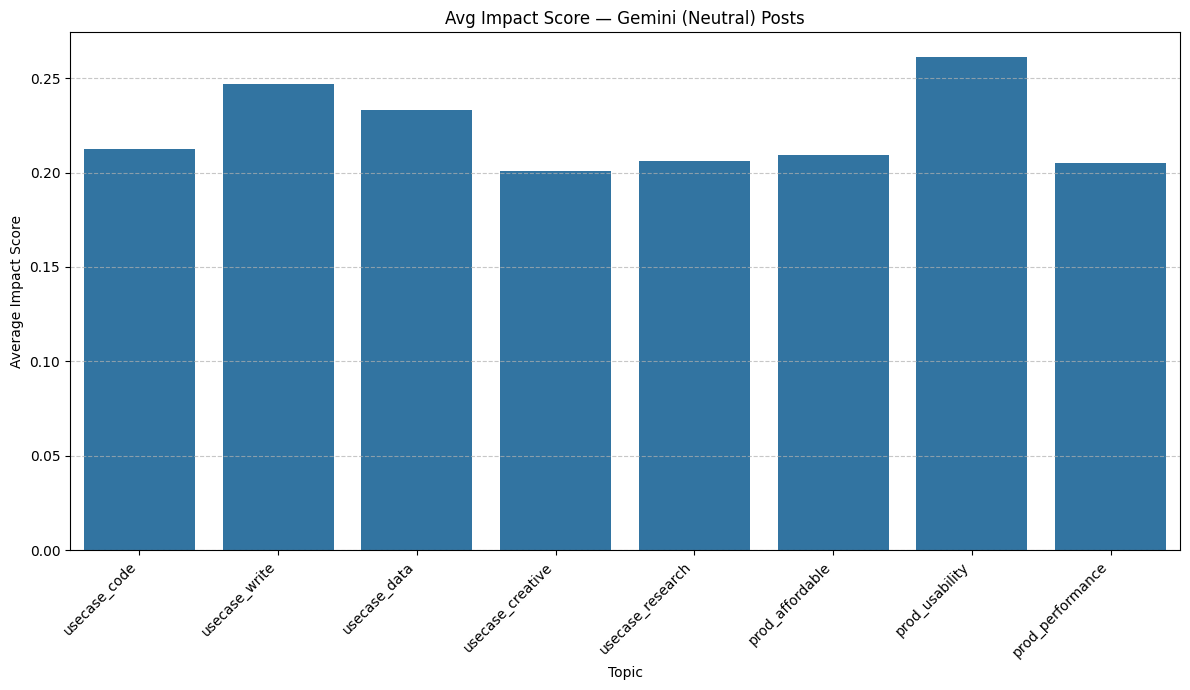

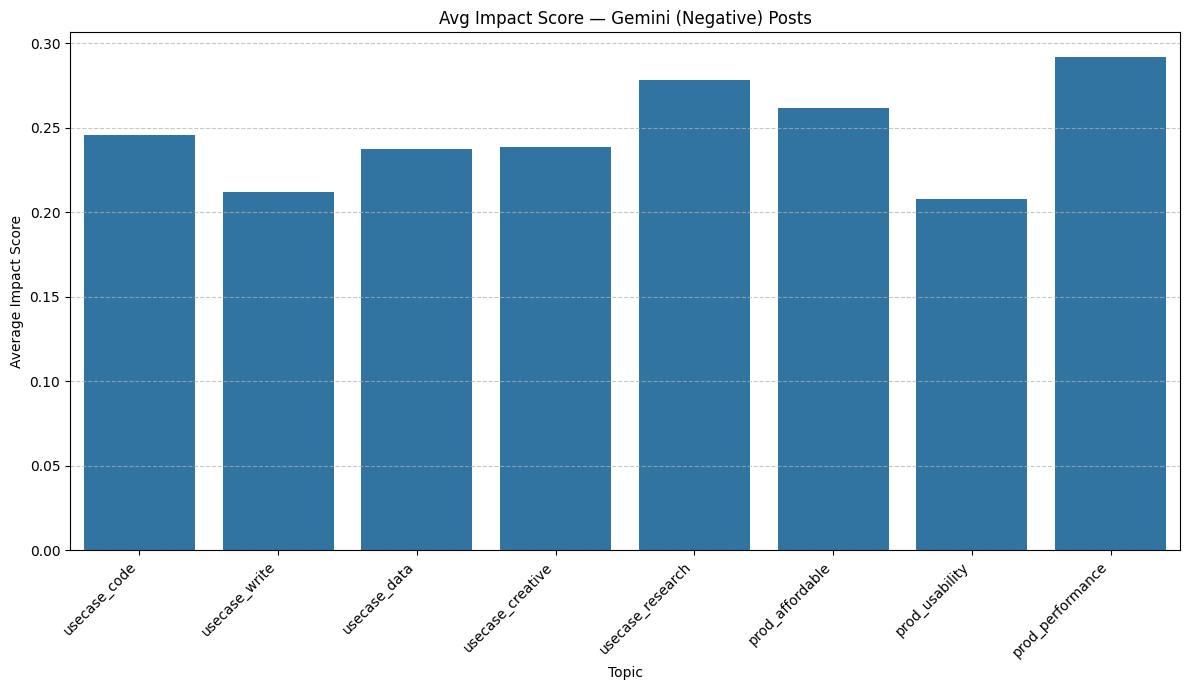

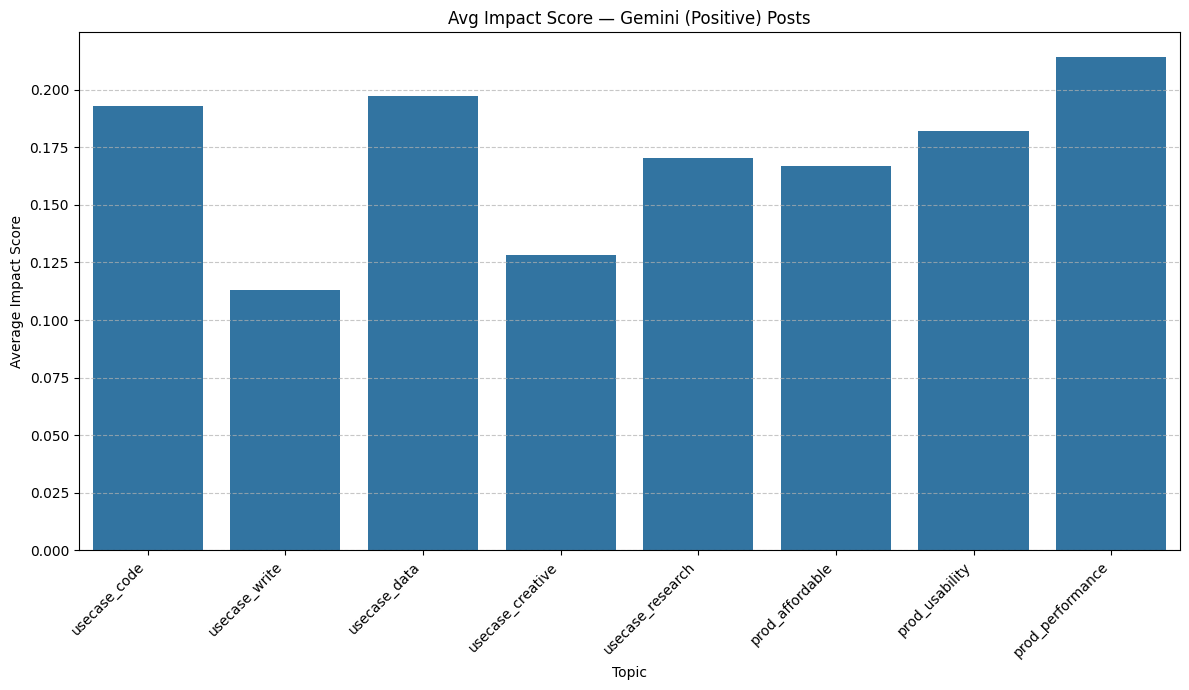

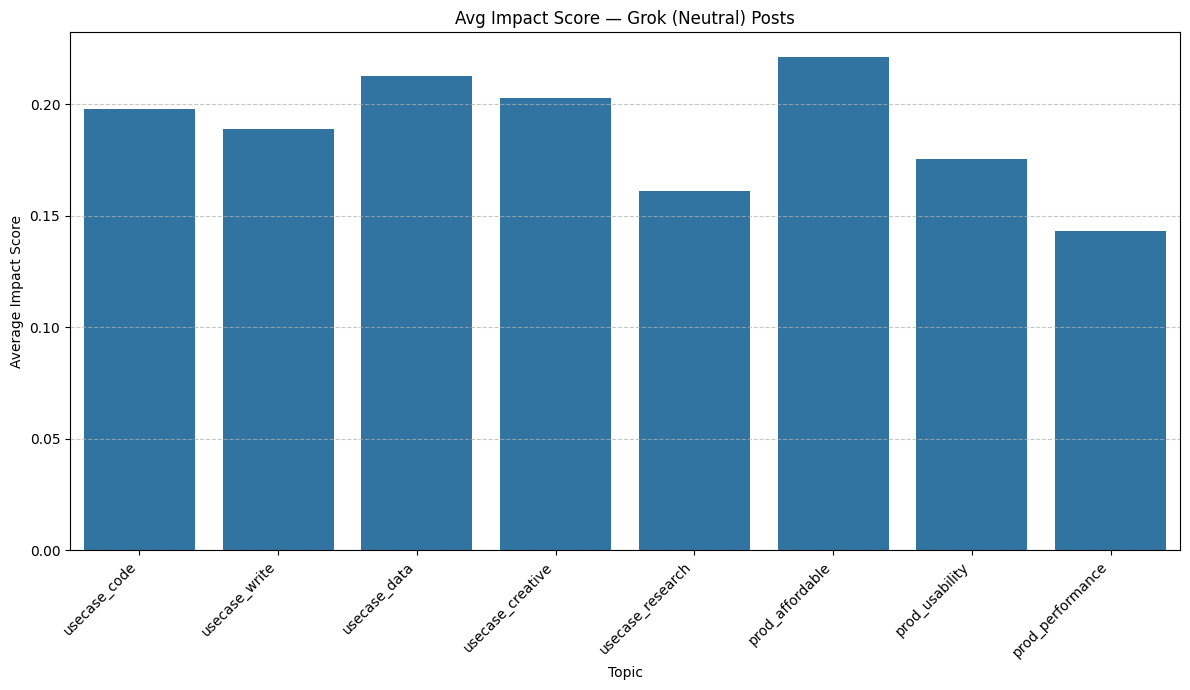

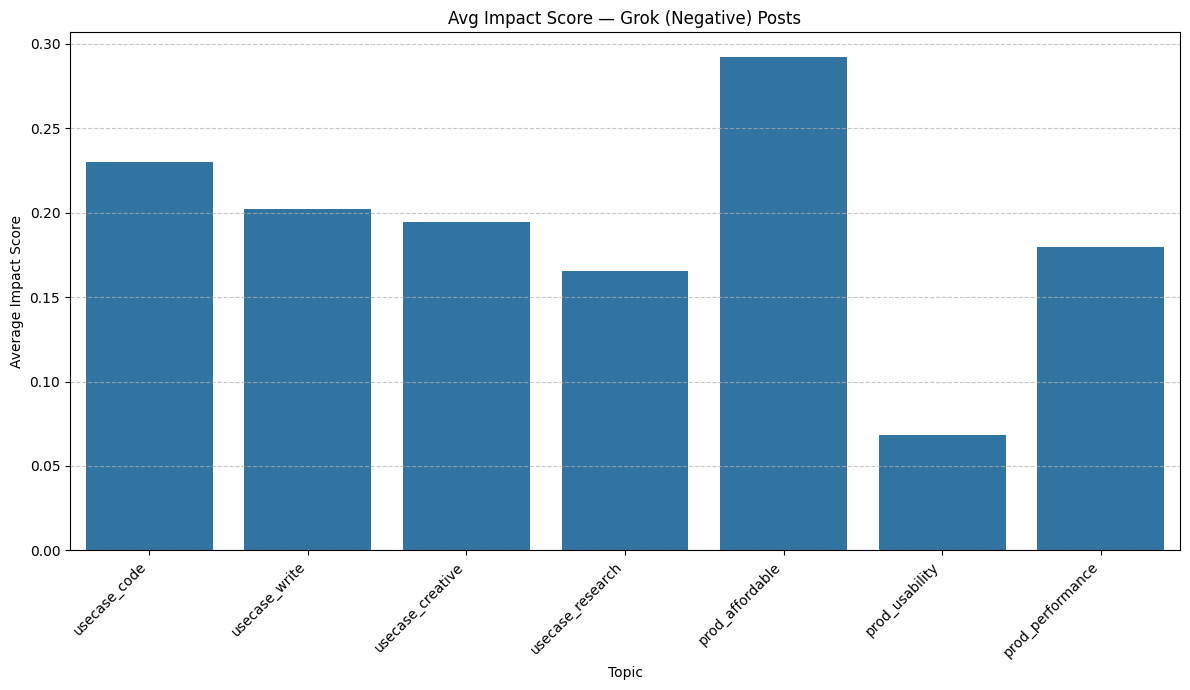

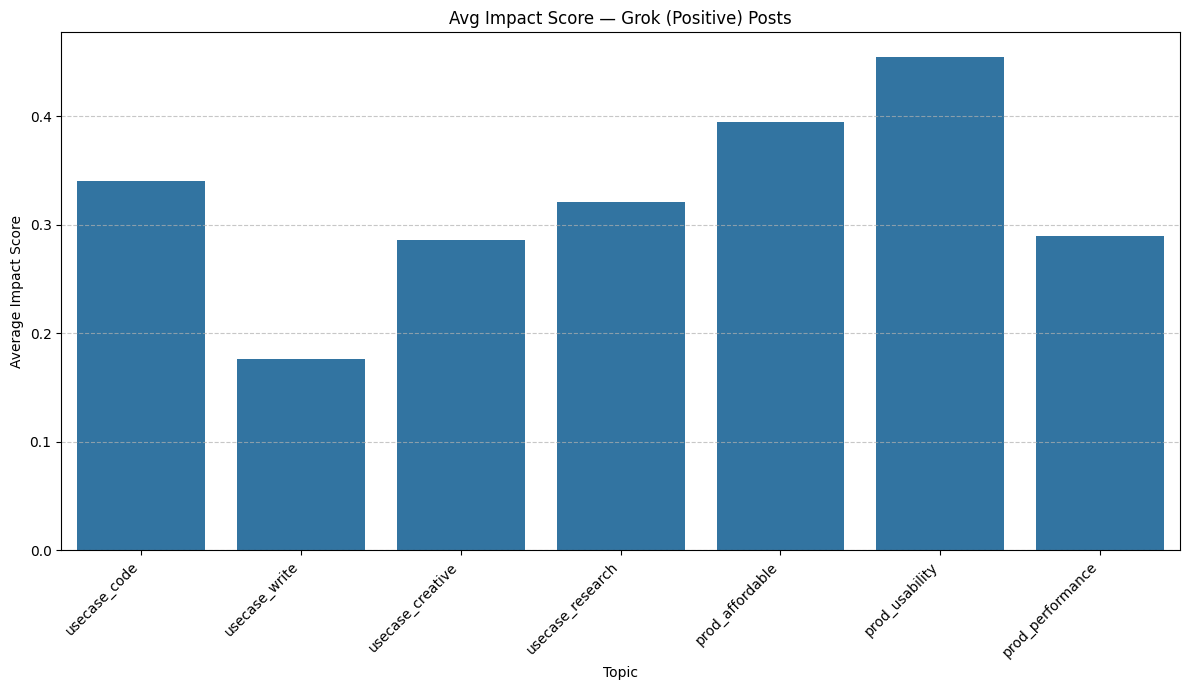

In [ ]:
def plot_bar(df_row, topics, title, score_col):
    vals = df_row[topics].values[0]
    d = pd.DataFrame({"topic": topics, "avg": vals}).dropna()
    if d.empty:
        print(f"No data for: {title}")
        return
    plt.figure(figsize=(12, 7))
    sns.barplot(x="topic", y="avg", data=d)
    plt.title(title)
    plt.xlabel("Topic"); plt.ylabel(score_col)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout(); plt.show()

SENT_LABELS = {0.0:"Neutral", 1.0:"Negative", 2.0:"Positive"}

# ONE Spark job: avg(impact_score) when topic_col==1, for every AI×sentiment×topic
agg_impact_post = [
    F.avg(F.when(F.col(t) == 1, F.col("impact_score"))).alias(t) for t in TOPICS_8
]
impact_post_pdf = (post
    .groupBy("AI_Name", "sentiment")
    .agg(*agg_impact_post)
    .toPandas())

for ai in AI_NAMES:
    for sv, sl in SENT_LABELS.items():
        row = impact_post_pdf[
            (impact_post_pdf["AI_Name"] == ai) & (impact_post_pdf["sentiment"] == sv)
        ]
        plot_bar(row, TOPICS_8,
                 f"Avg Impact Score — {ai} ({sl}) Posts",
                 "Average Impact Score")

## Per-AI / Sentiment / Topic — Average Sentiment Score (Post)

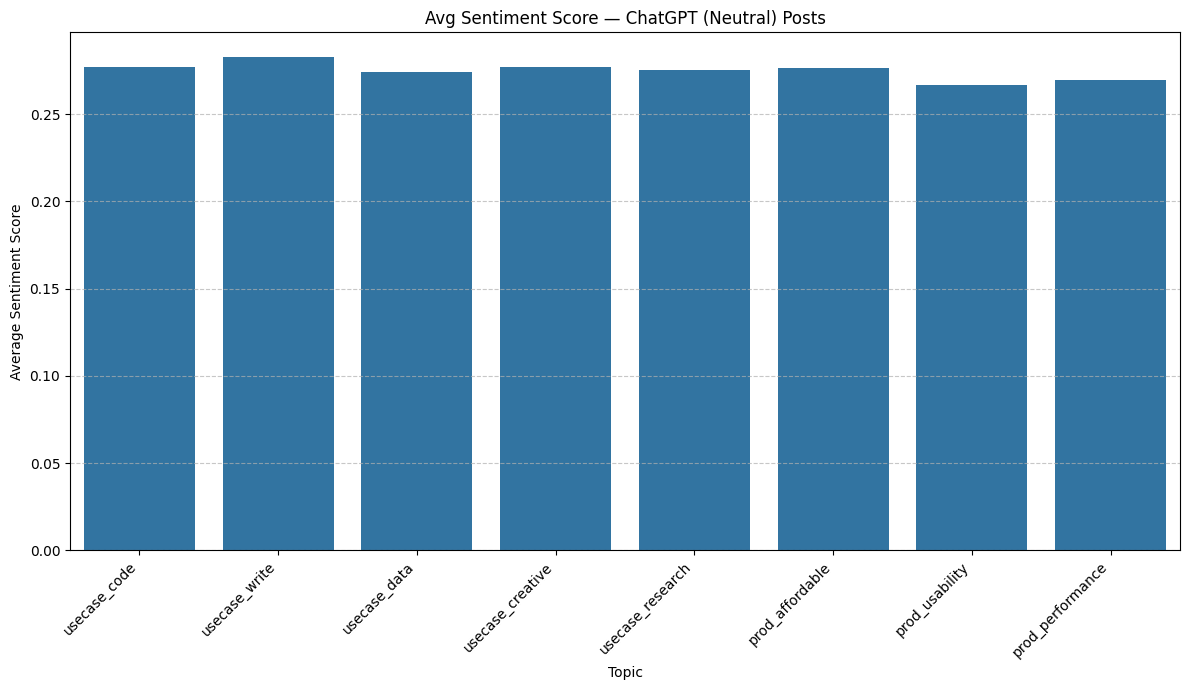

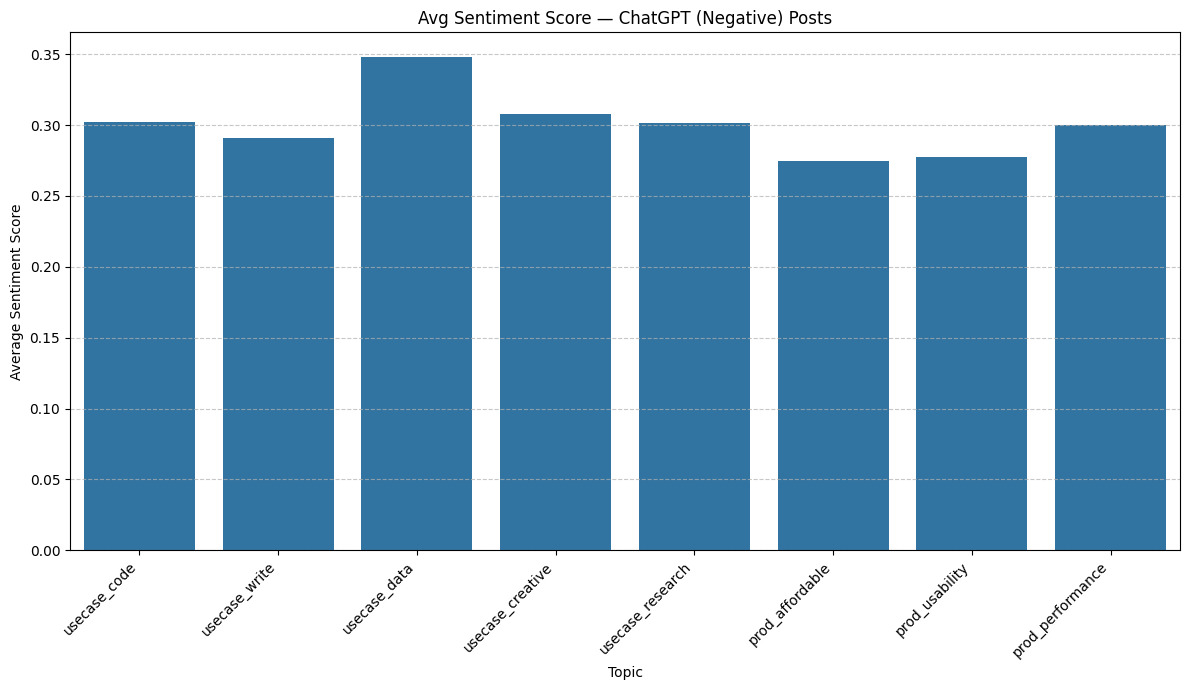

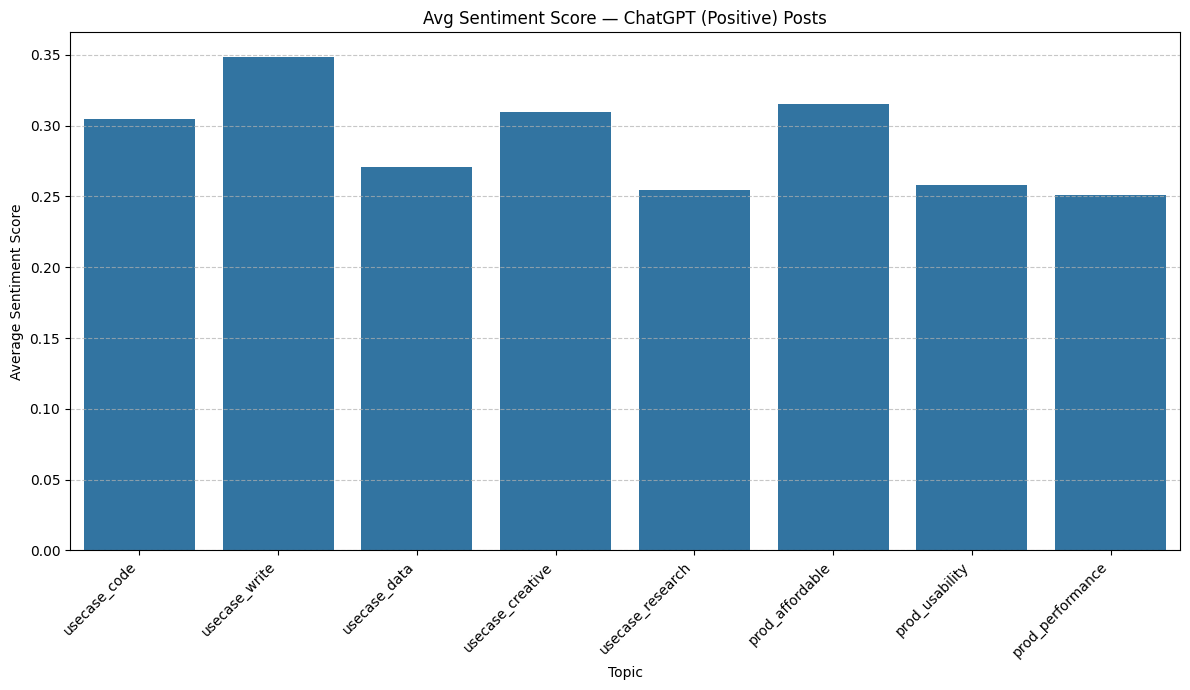

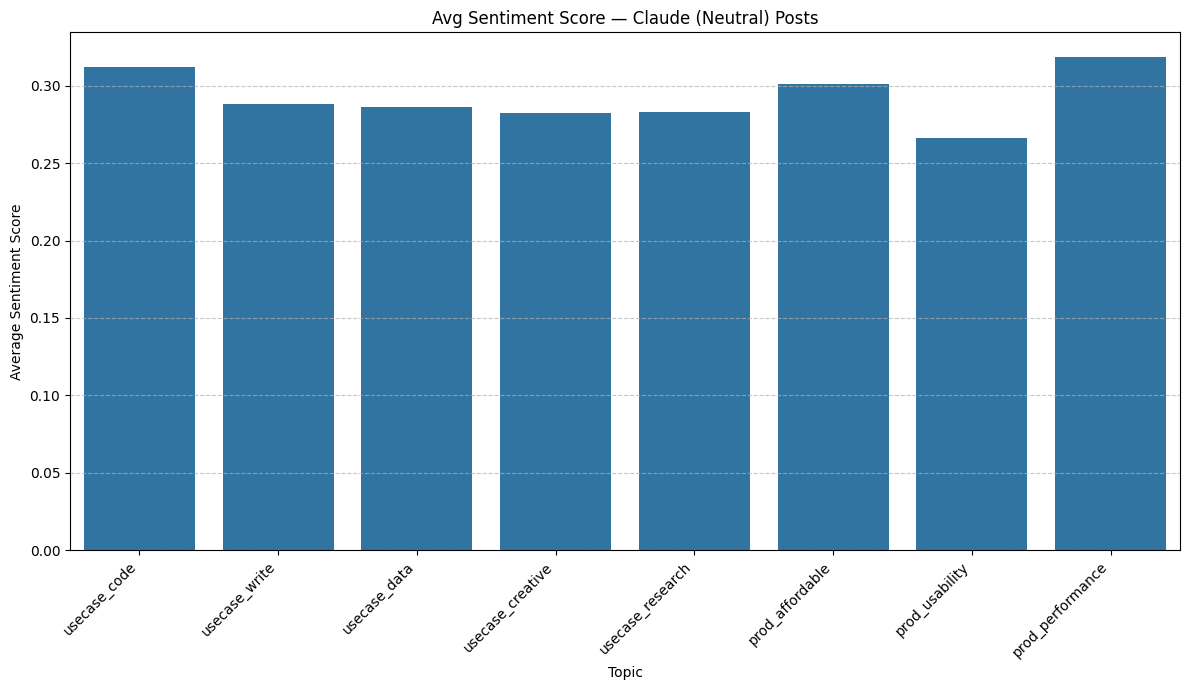

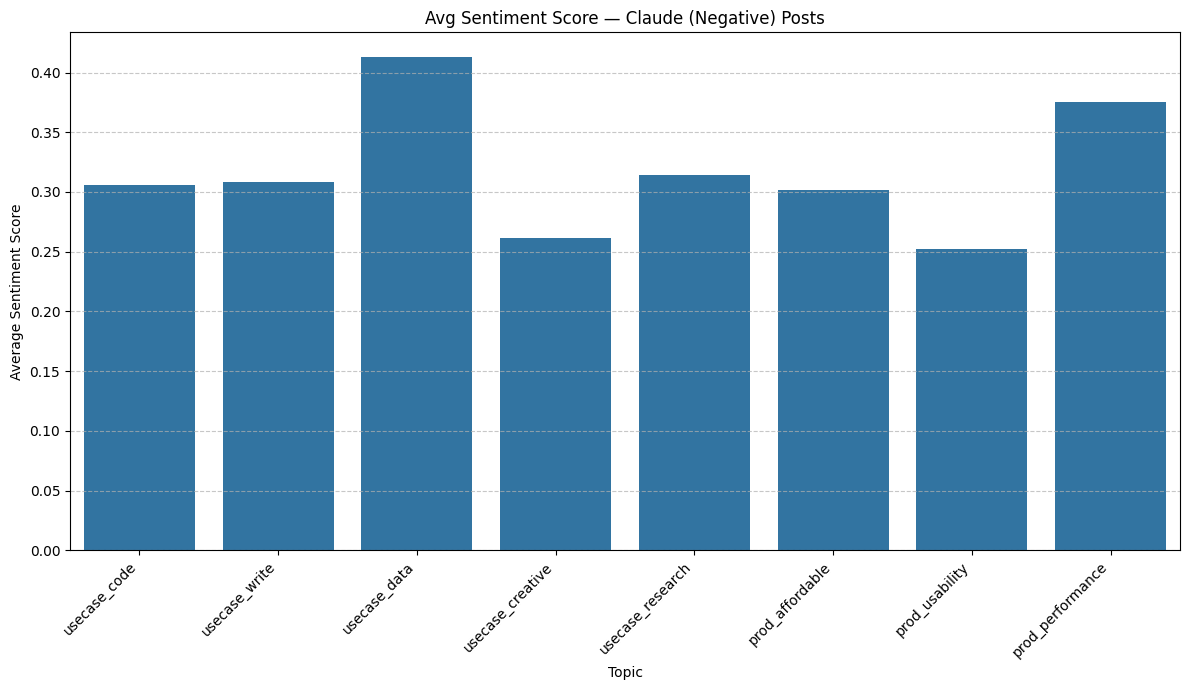

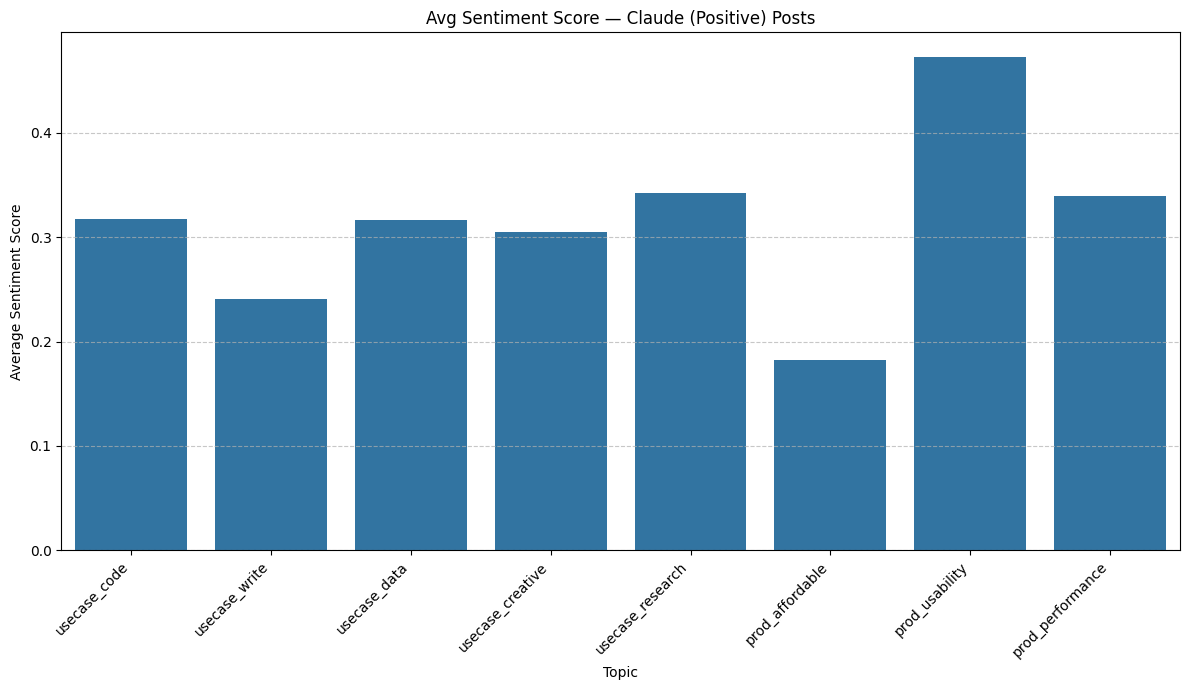

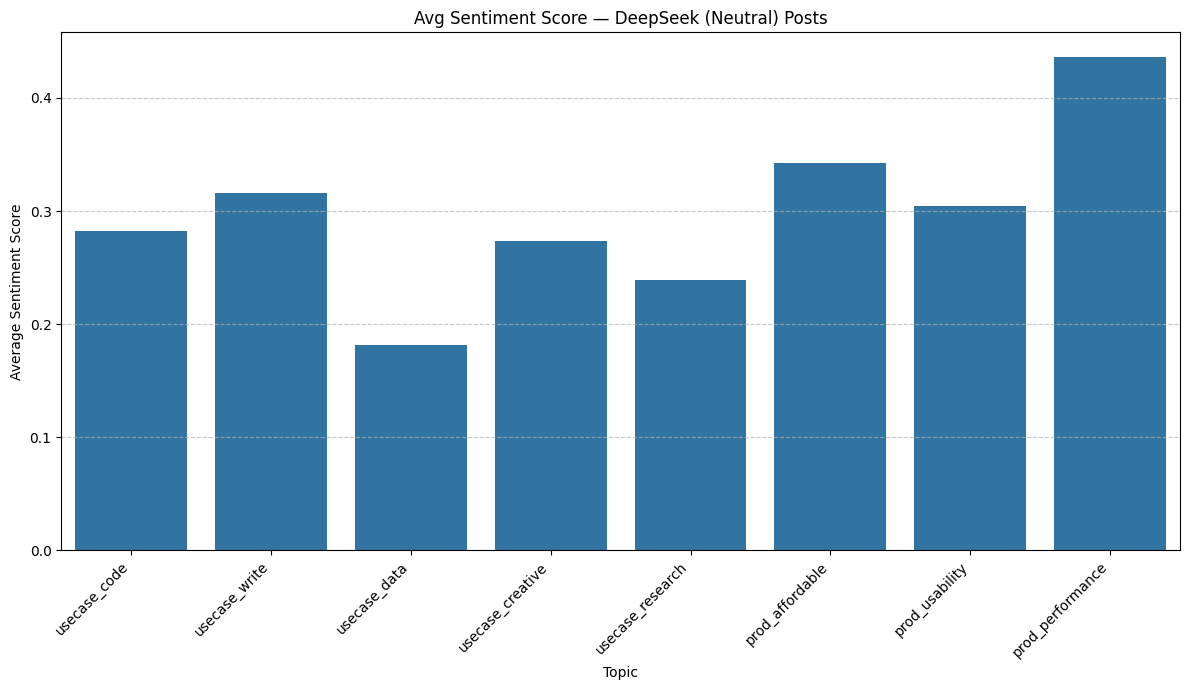

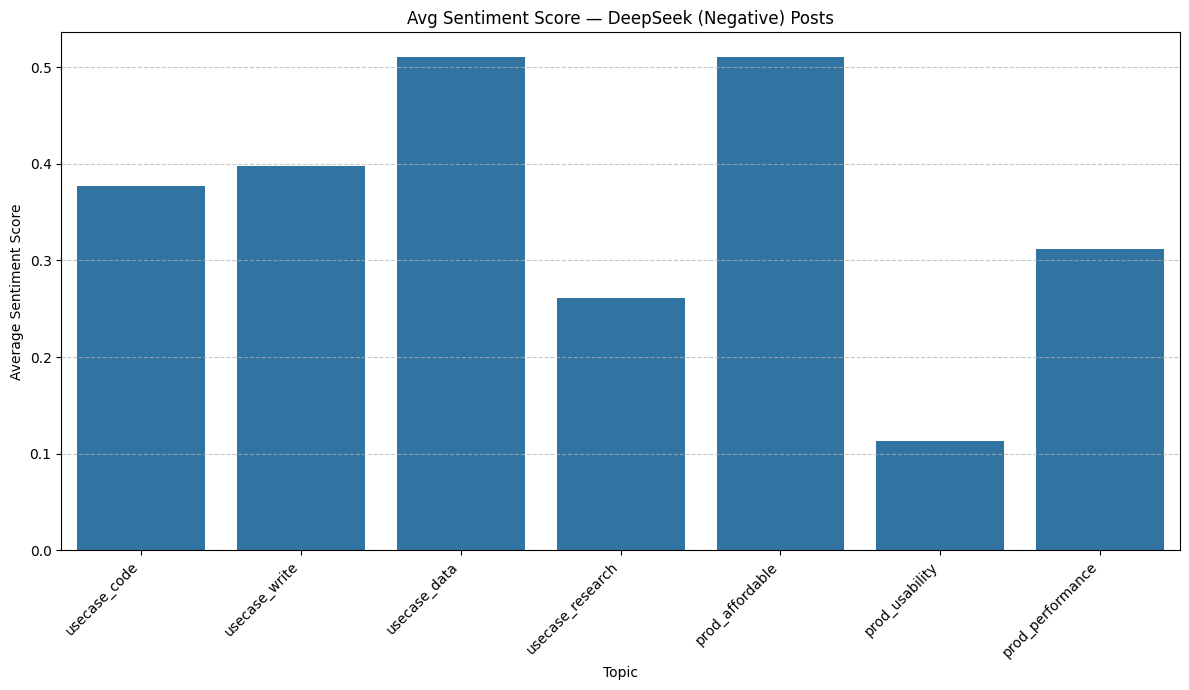

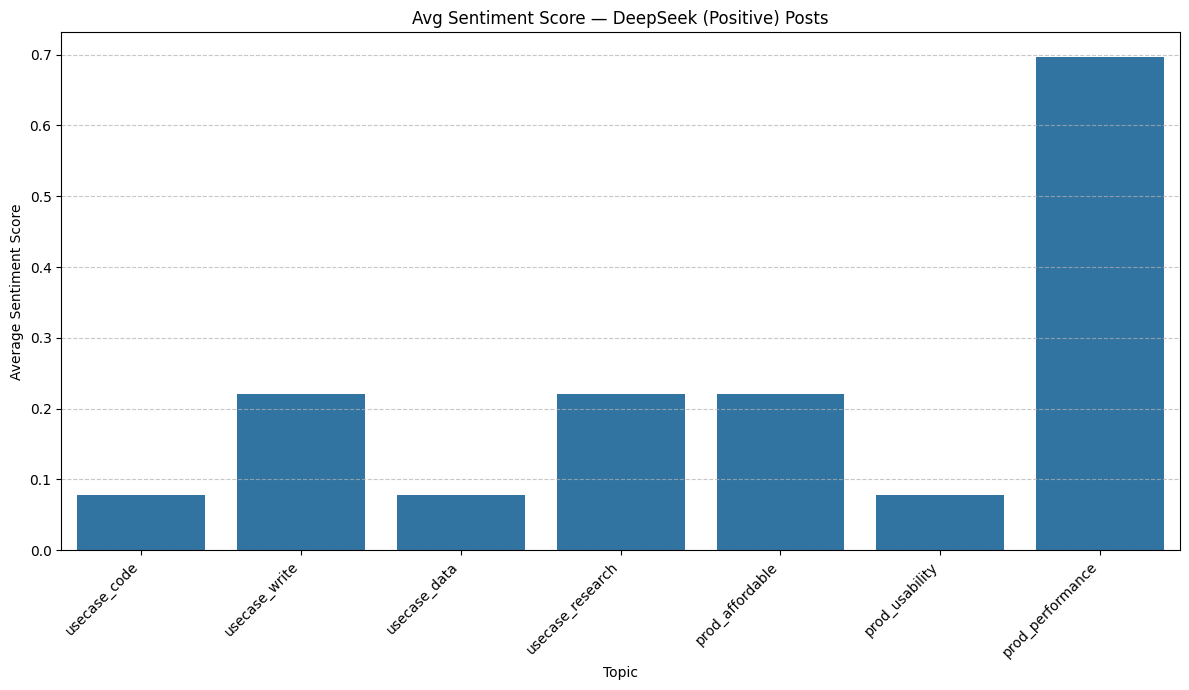

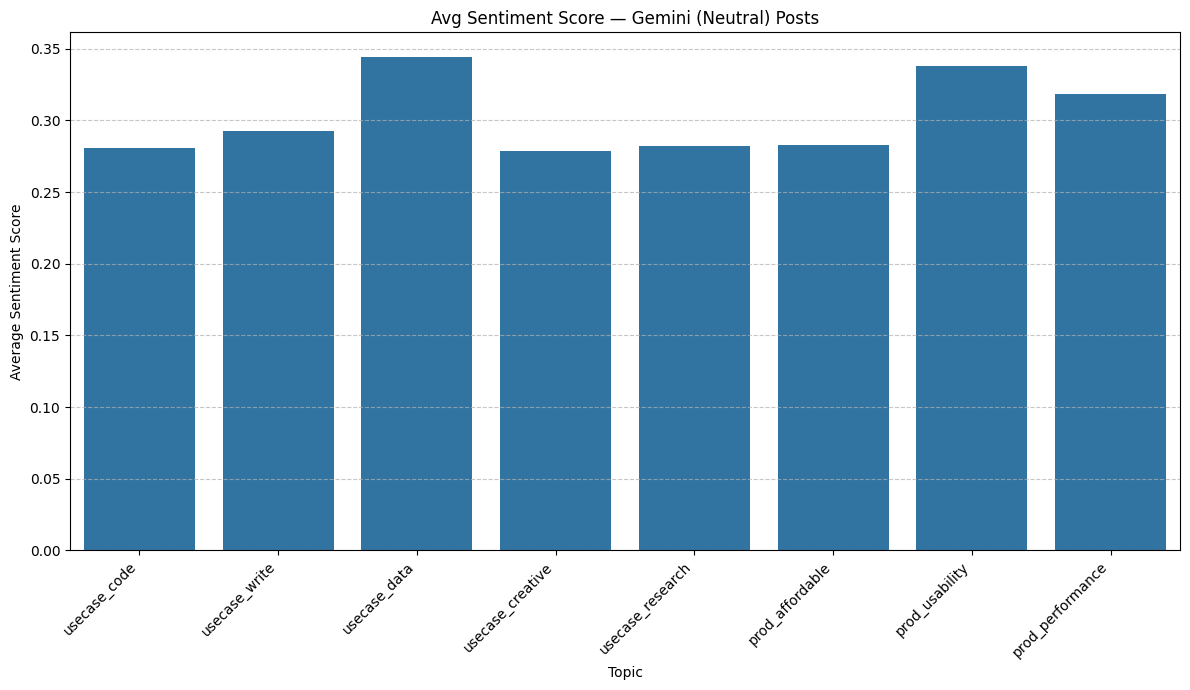

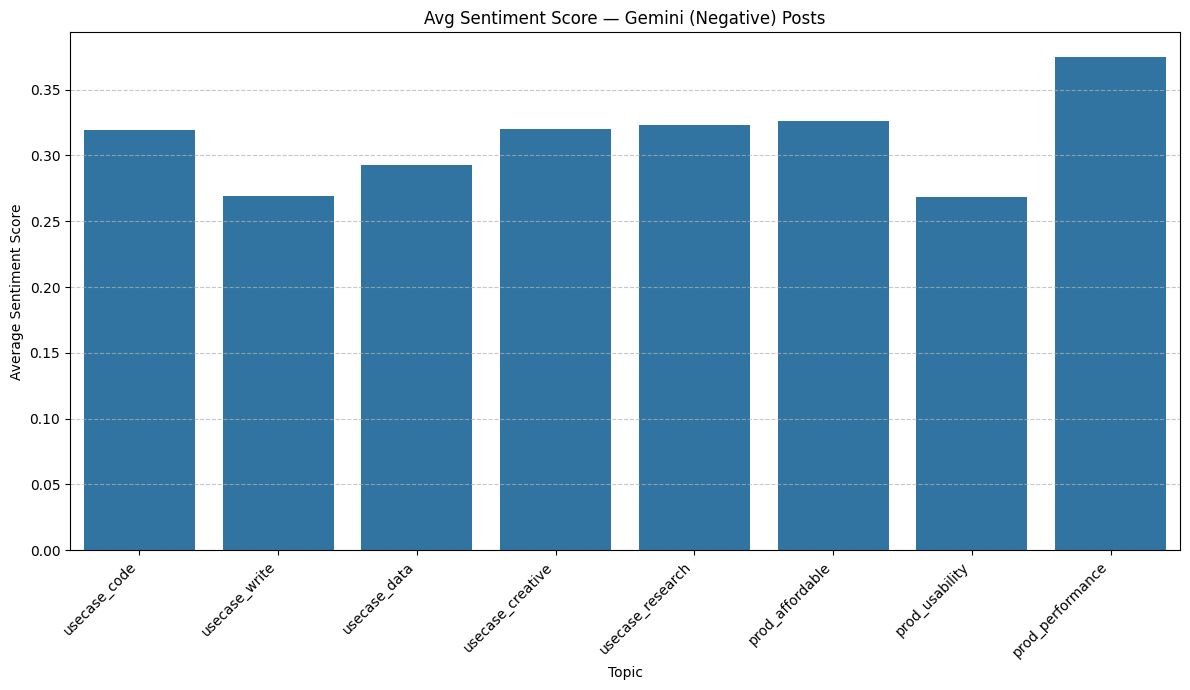

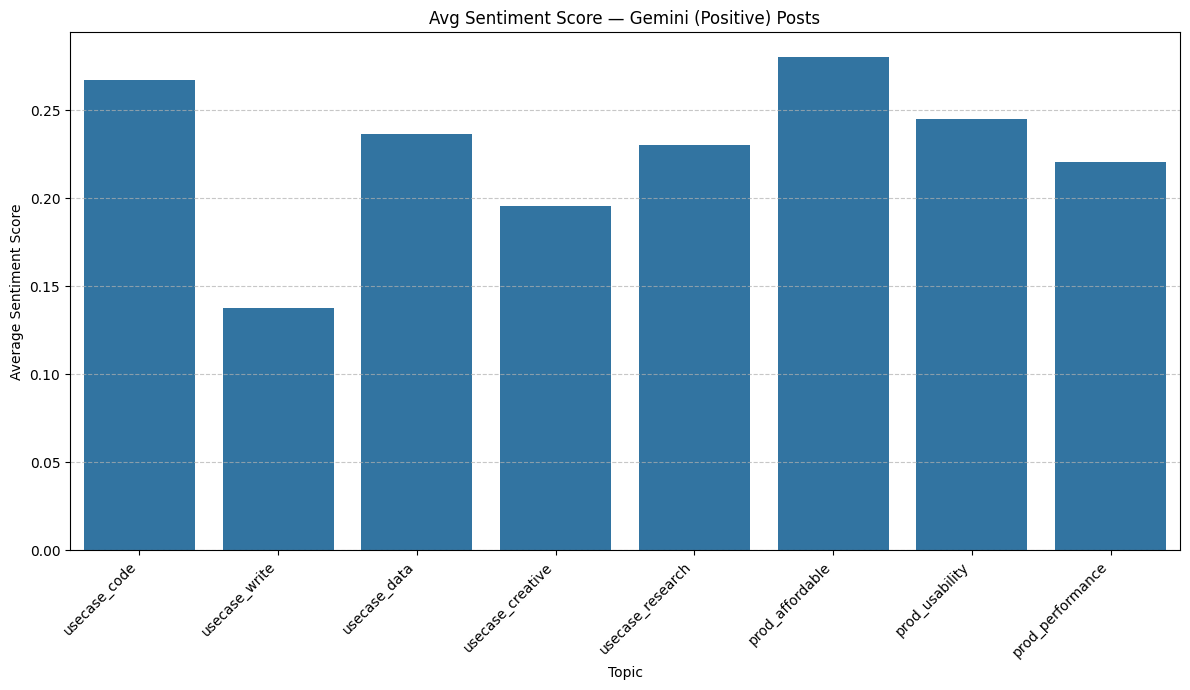

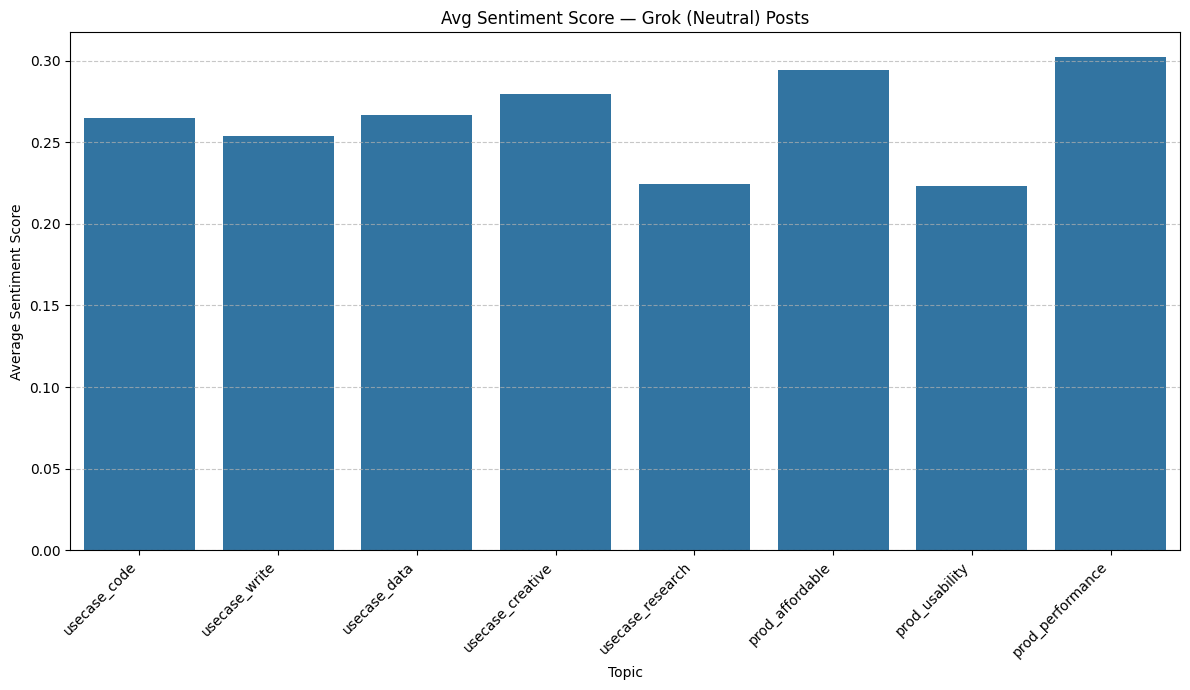

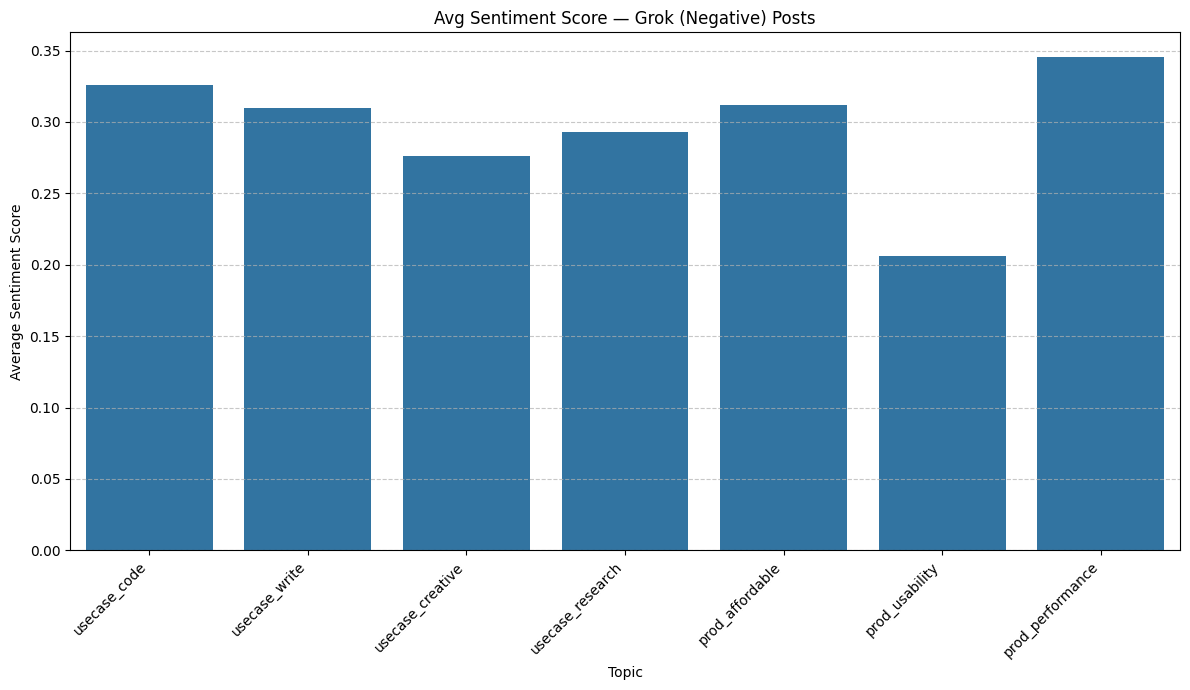

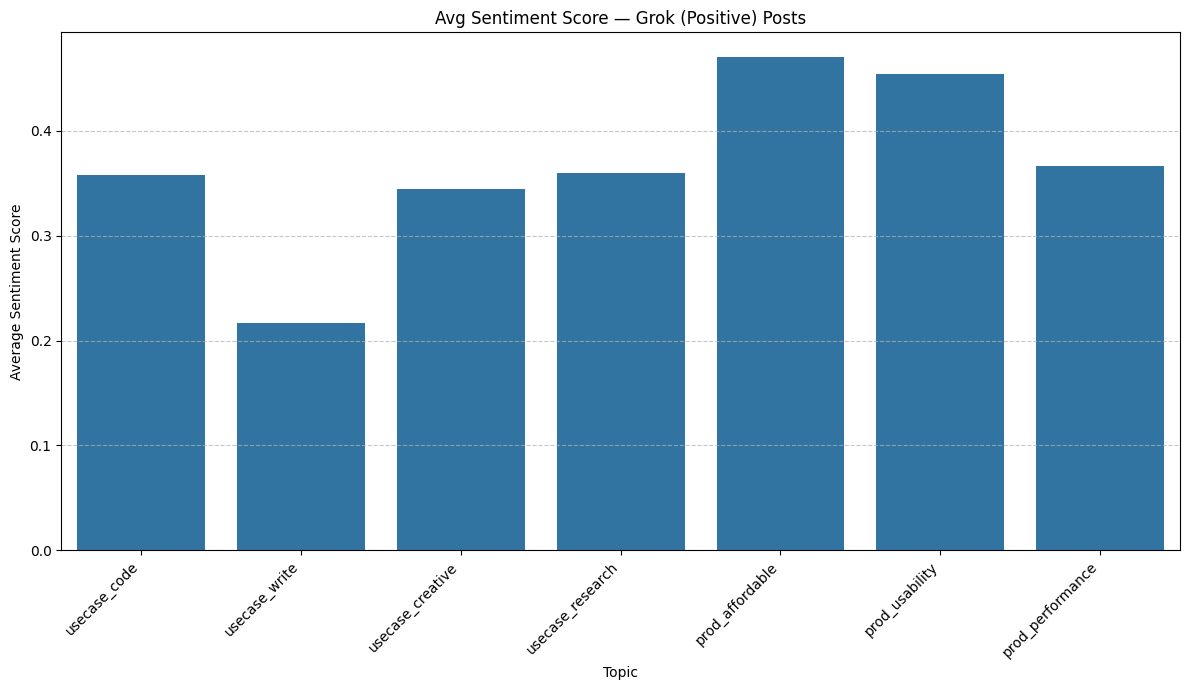

In [ ]:
# ONE Spark job
agg_sent_post = [
    F.avg(F.when(F.col(t) == 1, F.col("sentiment_score"))).alias(t) for t in TOPICS_8
]
sent_post_pdf = (post
    .groupBy("AI_Name", "sentiment")
    .agg(*agg_sent_post)
    .toPandas())

for ai in AI_NAMES:
    for sv, sl in SENT_LABELS.items():
        row = sent_post_pdf[
            (sent_post_pdf["AI_Name"] == ai) & (sent_post_pdf["sentiment"] == sv)
        ]
        plot_bar(row, TOPICS_8,
                 f"Avg Sentiment Score — {ai} ({sl}) Posts",
                 "Average Sentiment Score")

In [ ]:
sent_post_pdf

,AI_Name,sentiment,usecase_code,usecase_write,usecase_data,usecase_creative,usecase_research,prod_affordable,prod_usability,prod_performance
0,ChatGPT,1.0,0.301832,0.290795,0.347975,0.307872,0.301713,0.274959,0.277405,0.300262
1,Gemini,2.0,0.267190,0.137759,0.236259,0.195450,0.230266,0.280149,0.244845,0.220268
2,DeepSeek,0.0,0.282419,0.316383,0.181557,0.273148,0.239067,0.342695,0.304173,0.436215
3,Gemini,1.0,0.319383,0.269097,0.292482,0.319928,0.322816,0.326218,0.268340,0.374731
4,DeepSeek,2.0,0.078640,0.220188,0.078640,NaN,0.220188,0.220188,0.078640,0.696645
5,Grok,1.0,0.325527,0.310069,NaN,0.275890,0.292852,0.312124,0.206362,0.345450
6,Grok,2.0,0.357393,0.216899,NaN,0.344973,0.359855,0.470375,0.454508,0.366488
7,DeepSeek,1.0,0.376545,0.397688,0.510434,NaN,0.260693,0.510434,0.112751,0.311592
8,ChatGPT,0.0,0.276986,0.282718,0.273914,0.276834,0.275049,0.276631,0.266439,0.269739
9,Gemini,0.0,0.280837,0.292752,0.344287,0.278534,0.282327,0.283031,0.337992,0.318290


### Diagnosing Missing `usecase_creative` Data for DeepSeek

In [ ]:
deepseek_creative_posts = post.filter(
    (F.col("AI_Name") == "DeepSeek") & (F.col("usecase_creative") == 1)
)

print("Count of DeepSeek posts tagged with 'usecase_creative':")
deepseek_creative_posts.count()

print("\nSentiment counts for DeepSeek posts tagged with 'usecase_creative':")
deepseek_creative_sentiment_counts = deepseek_creative_posts.groupBy("sentiment").count()
deepseek_creative_sentiment_counts.show()

Count of DeepSeek posts tagged with 'usecase_creative':

Sentiment counts for DeepSeek posts tagged with 'usecase_creative':
+---------+-----+
|sentiment|count|
+---------+-----+
|      0.0|    6|
+---------+-----+



## Per-AI / Sentiment / Topic — Average Impact Score (Comment)

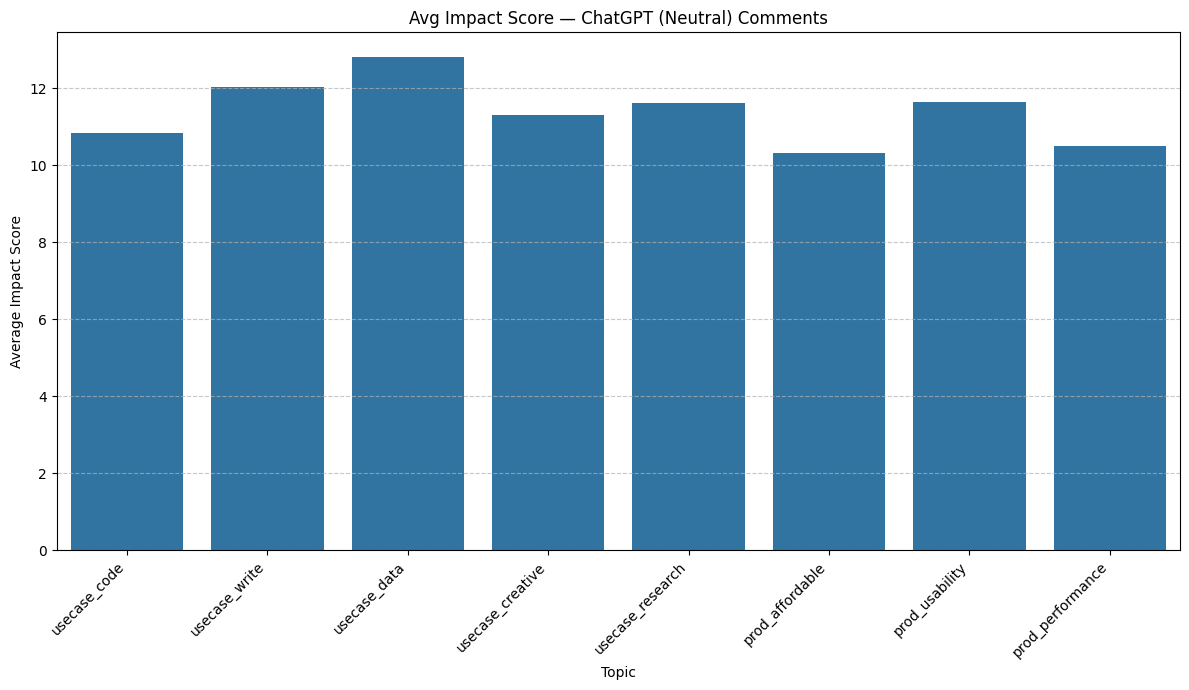

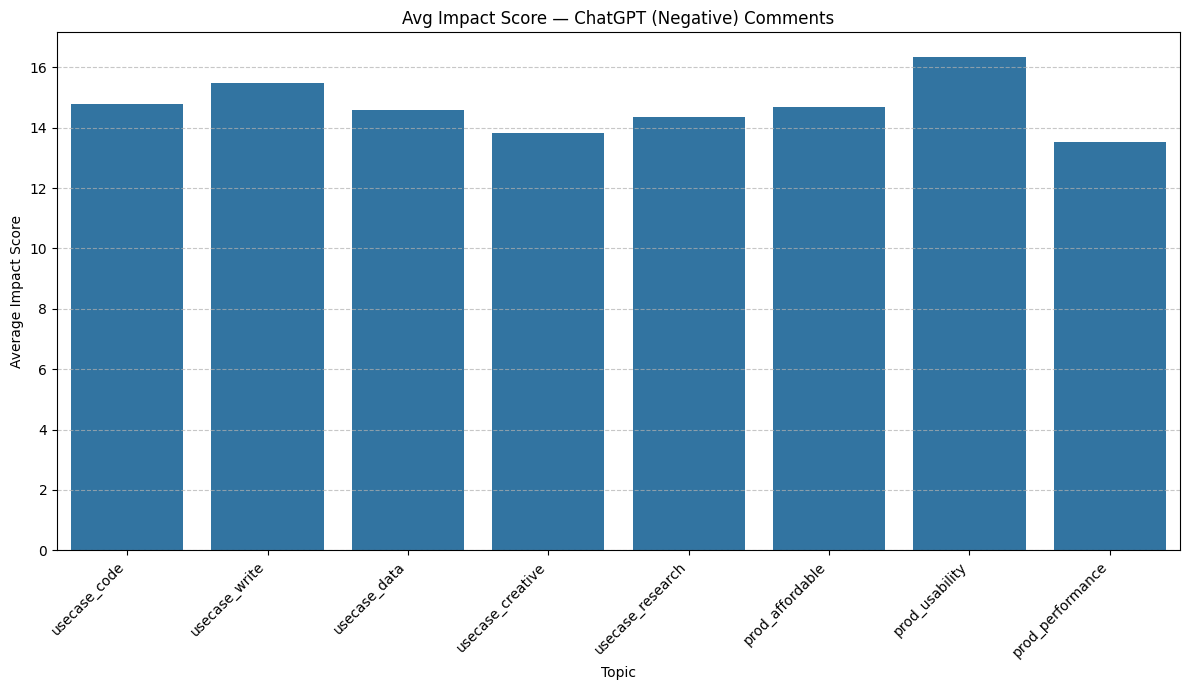

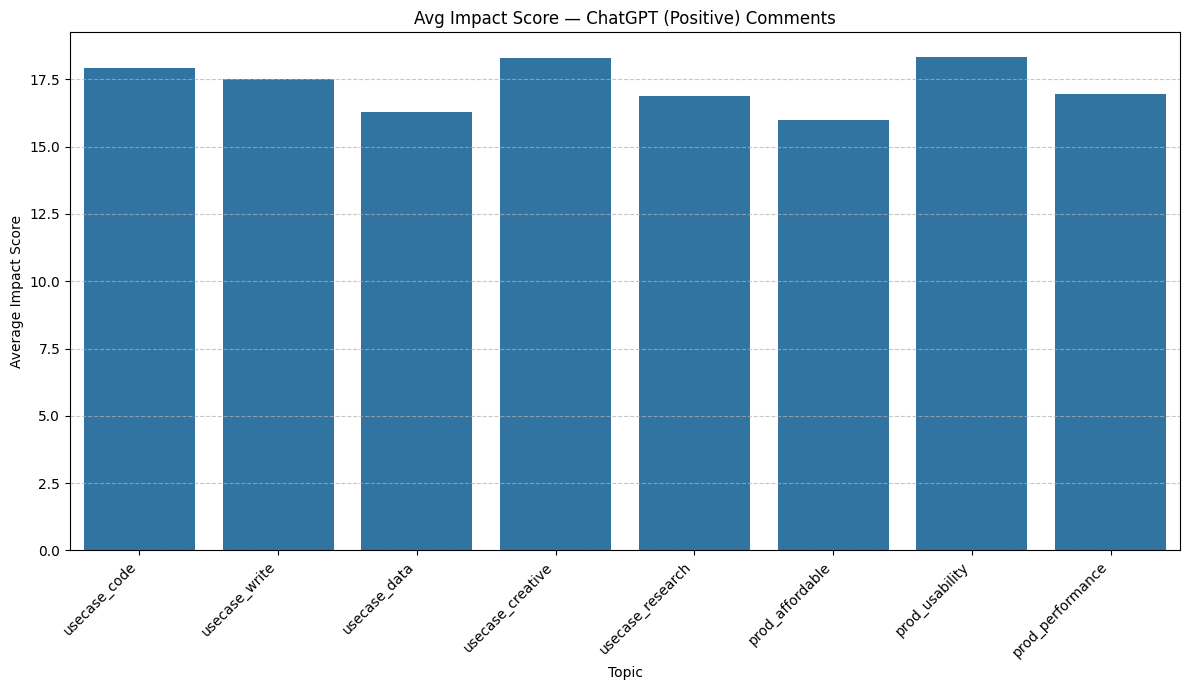

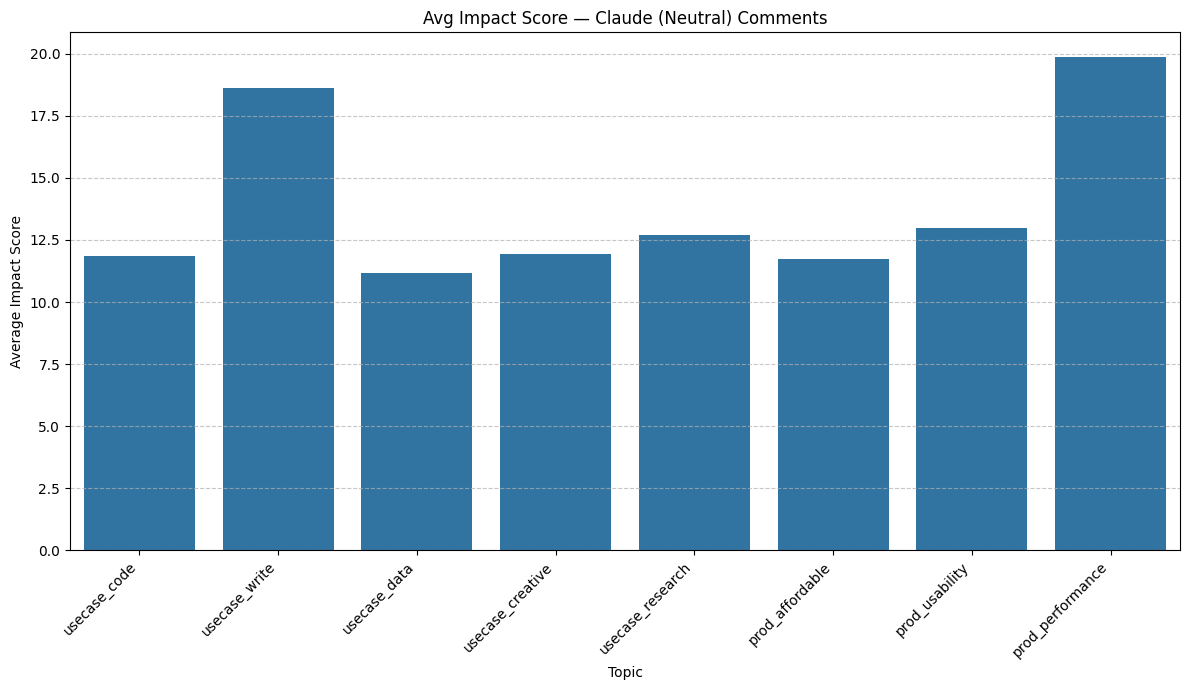

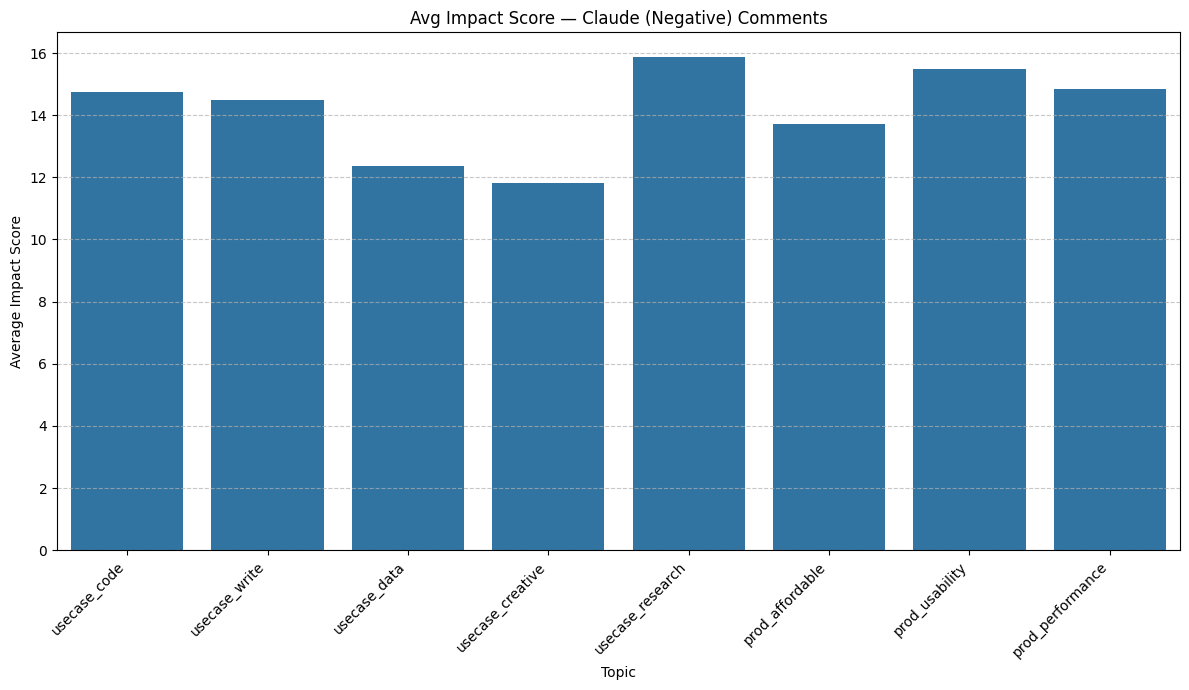

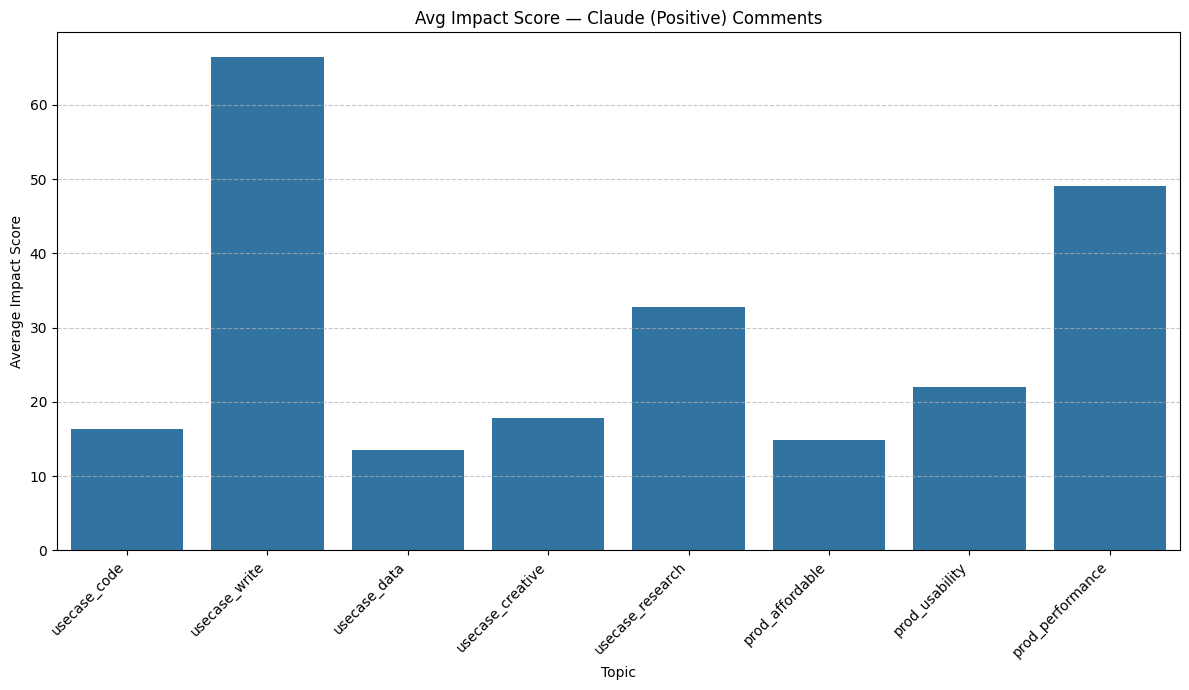

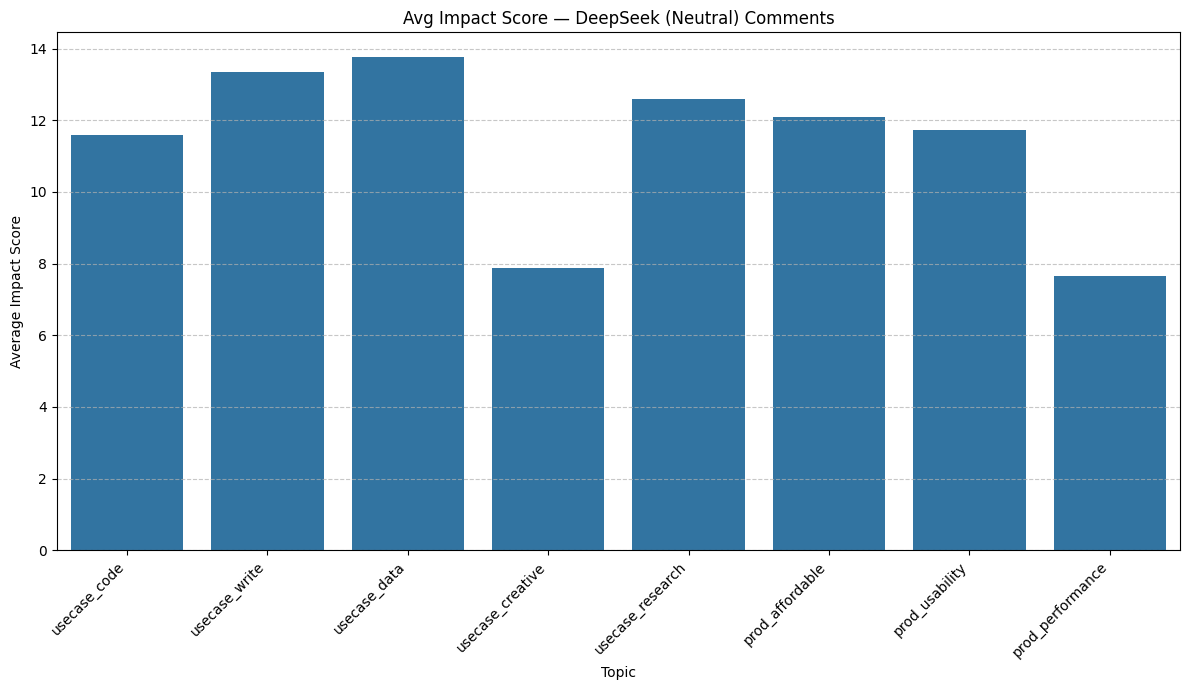

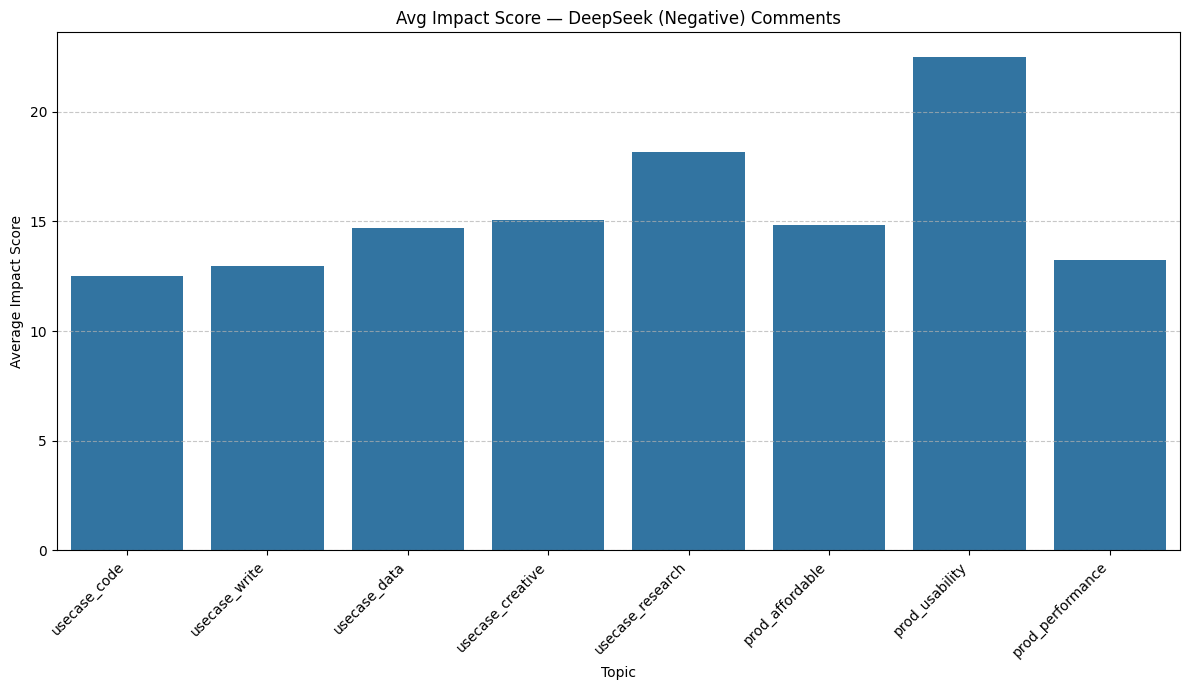

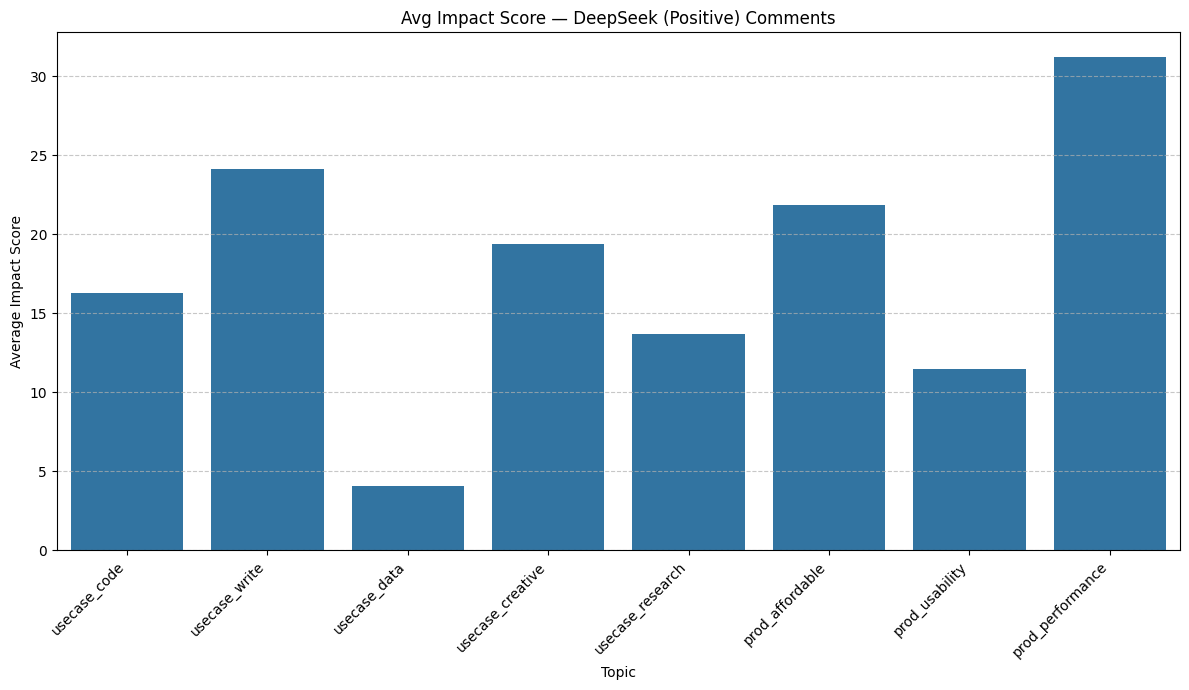

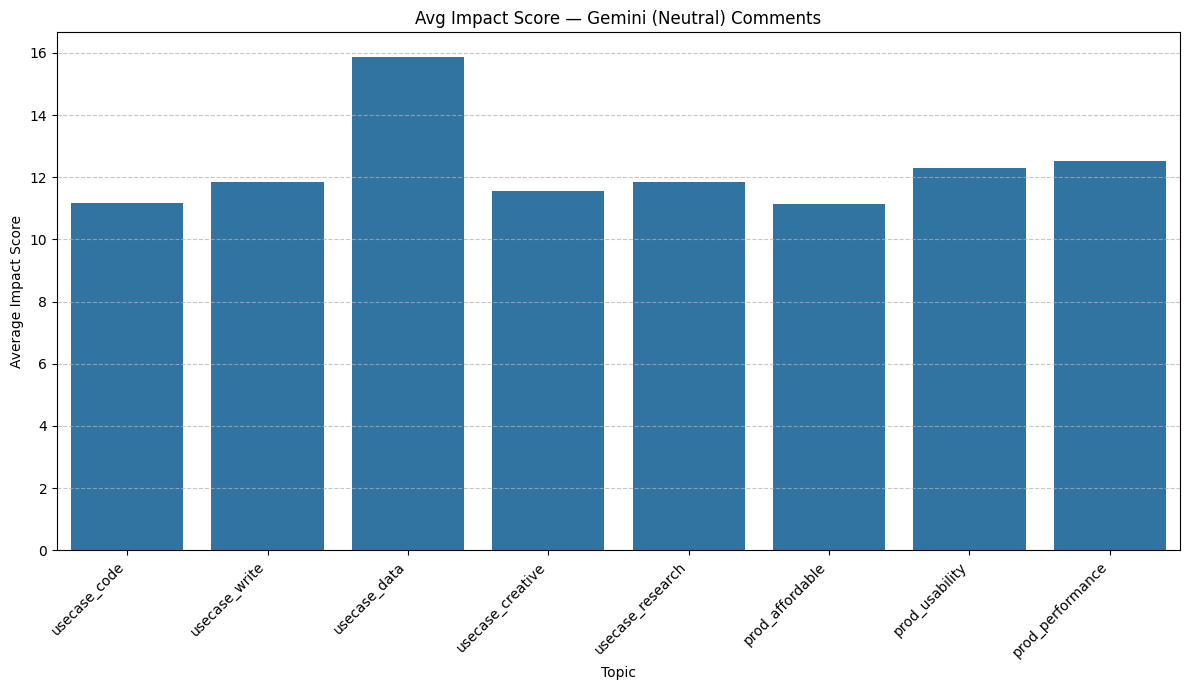

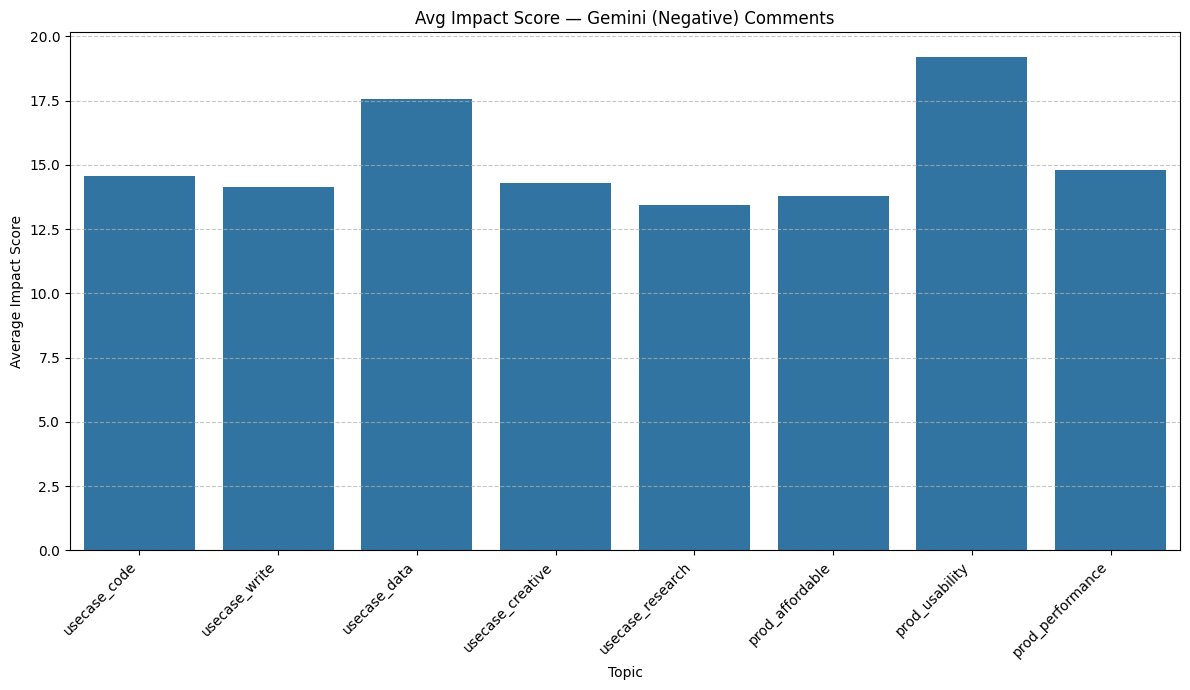

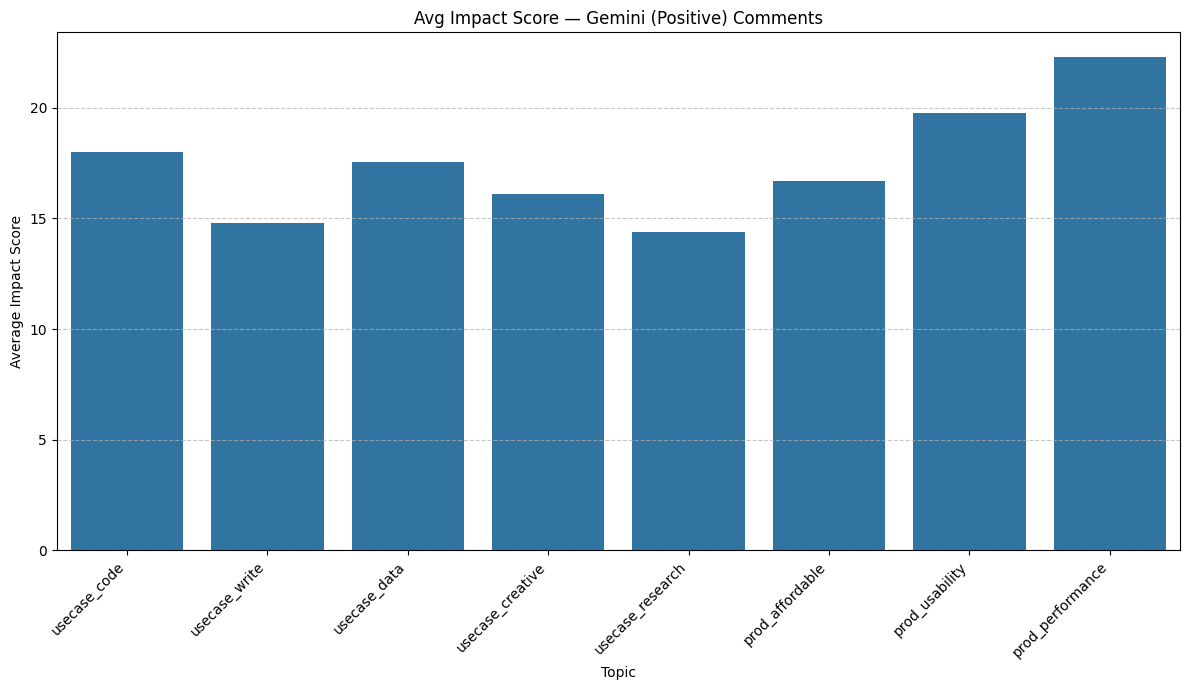

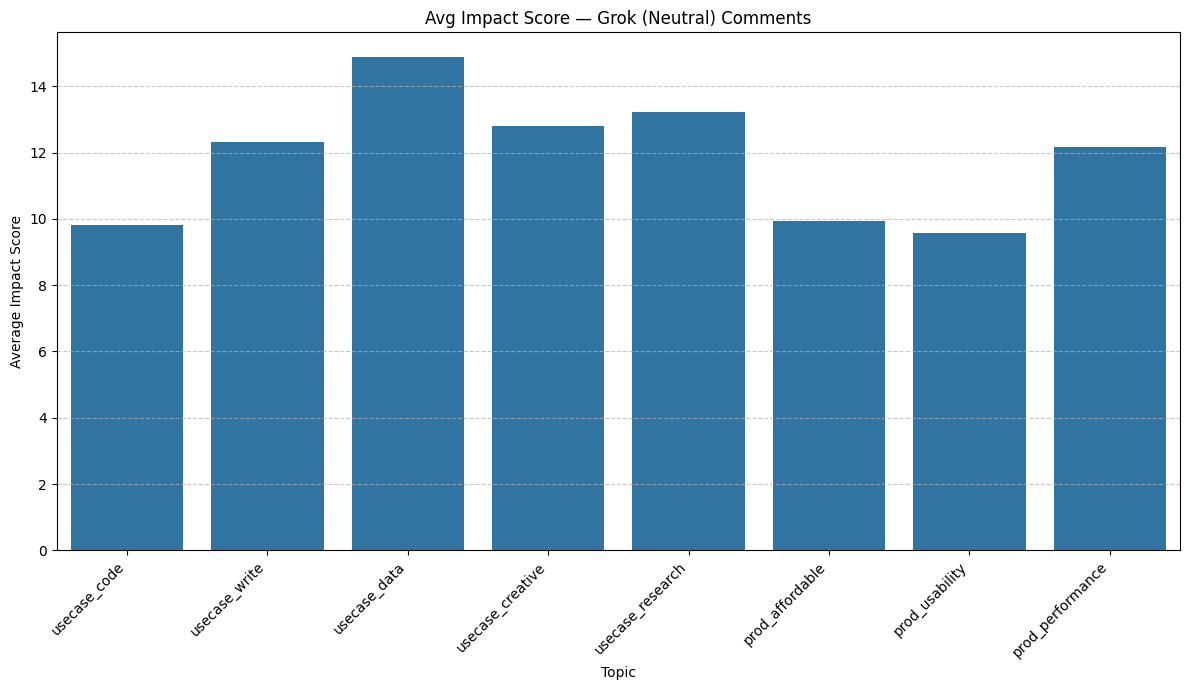

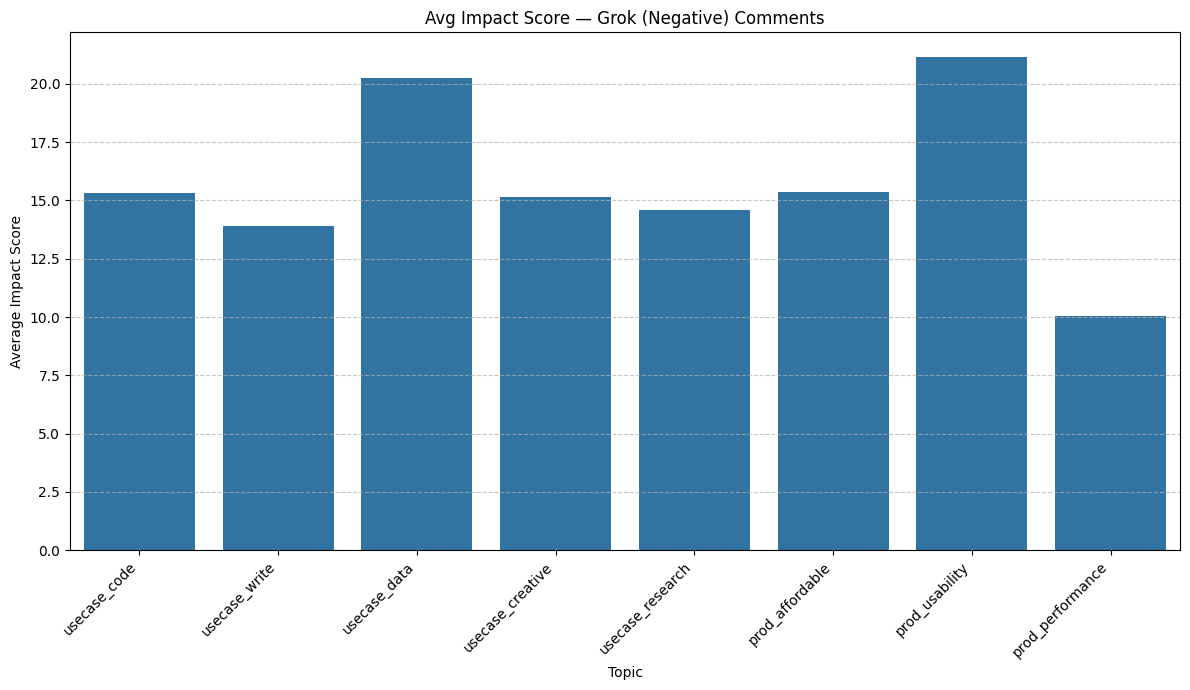

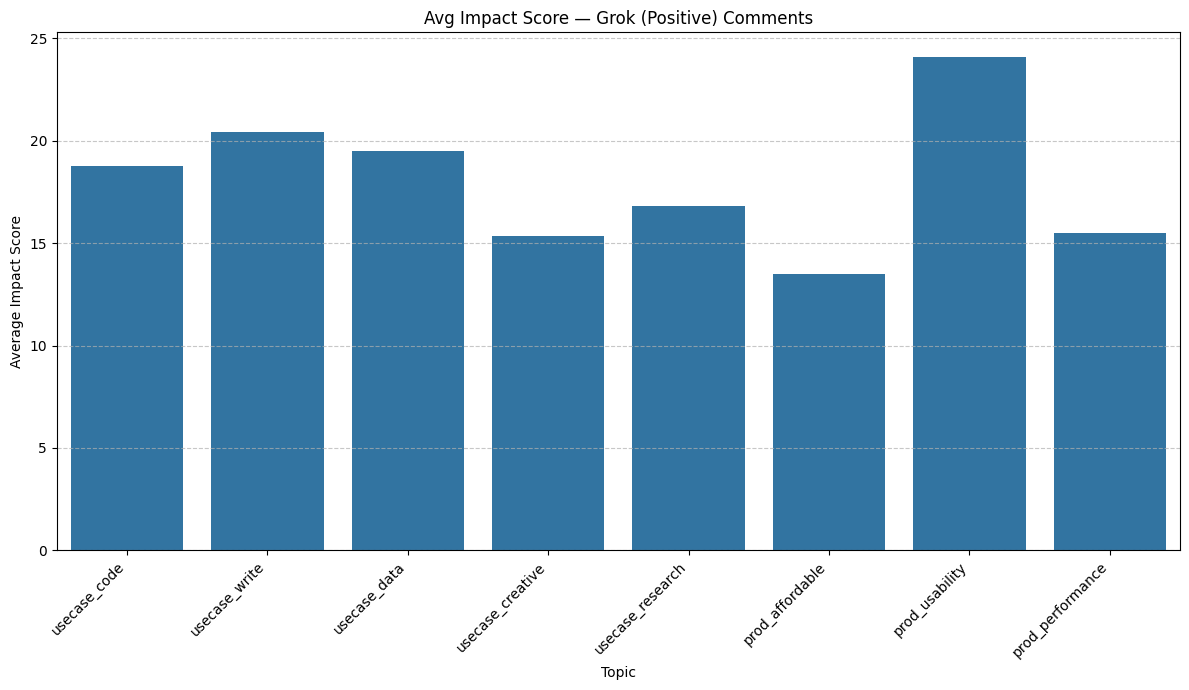

In [ ]:
# ONE Spark job
agg_impact_com = [
    F.avg(F.when(F.col(t) == 1, F.col("impact_score"))).alias(t) for t in TOPICS_8
]
impact_com_pdf = (comment
    .groupBy("AI_Name", "sentiment")
    .agg(*agg_impact_com)
    .toPandas())

for ai in AI_NAMES:
    for sv, sl in SENT_LABELS.items():
        row = impact_com_pdf[
            (impact_com_pdf["AI_Name"] == ai) & (impact_com_pdf["sentiment"] == sv)
        ]
        plot_bar(row, TOPICS_8,
                 f"Avg Impact Score — {ai} ({sl}) Comments",
                 "Average Impact Score")

In [ ]:
display(impact_com_pdf)

,AI_Name,sentiment,usecase_code,usecase_write,usecase_data,usecase_creative,usecase_research,prod_affordable,prod_usability,prod_performance
0,ChatGPT,1.0,14.786227,15.477344,14.584173,13.825919,14.369850,14.698610,16.344989,13.530737
1,Gemini,2.0,17.991436,14.786324,17.554682,16.095781,14.386248,16.673411,19.756388,22.291998
2,DeepSeek,0.0,11.584394,13.337077,13.767381,7.870170,12.587036,12.105338,11.729477,7.664140
3,Gemini,1.0,14.566459,14.132334,17.578485,14.276320,13.447937,13.797632,19.195839,14.814378
4,DeepSeek,2.0,16.300003,24.161310,4.073334,19.363708,13.683860,21.829774,11.490223,31.230465
5,Grok,1.0,15.333161,13.889722,20.259968,15.143059,14.571952,15.355239,21.150839,10.028069
6,Grok,2.0,18.786495,20.444847,19.480065,15.332815,16.837469,13.479590,24.094993,15.474972
7,DeepSeek,1.0,12.516518,12.963510,14.688942,15.068520,18.183487,14.846524,22.501512,13.227930
8,Gemini,0.0,11.183493,11.847161,15.870505,11.572825,11.855620,11.156567,12.293748,12.534257
9,ChatGPT,0.0,10.854290,12.048229,12.818024,11.320691,11.615159,10.318437,11.643117,10.517248


## Radar Charts — Negative vs Positive Impact per Brand (Post)

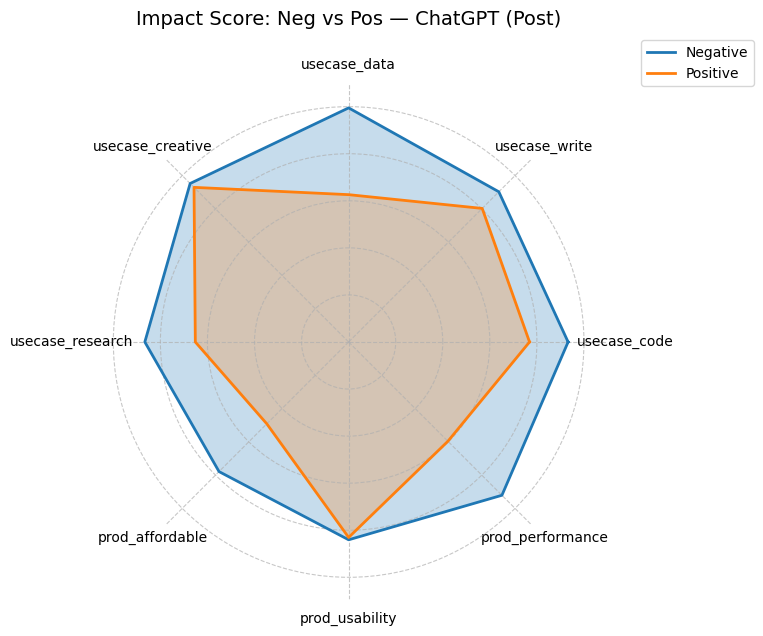

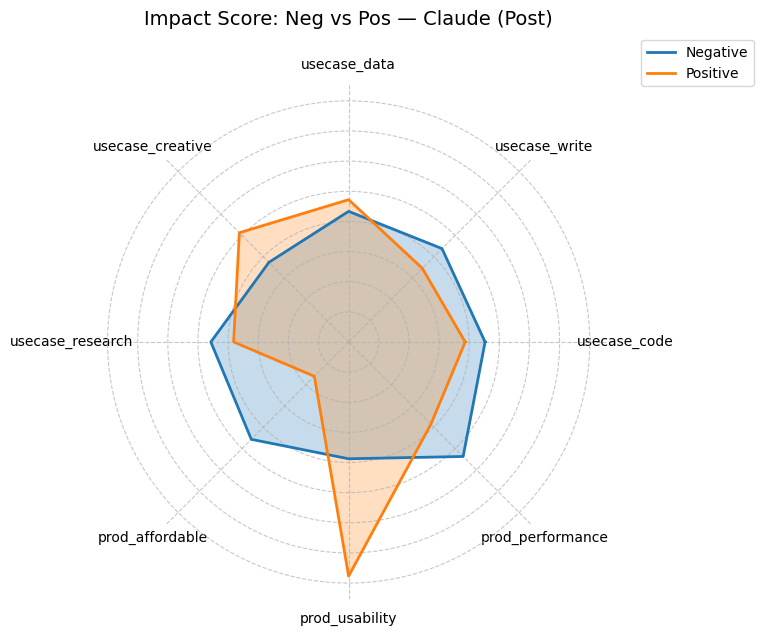

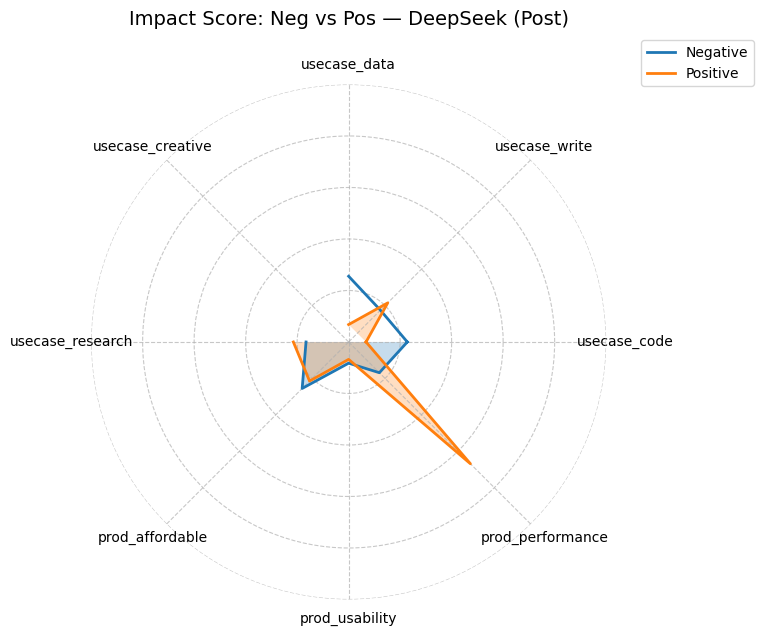

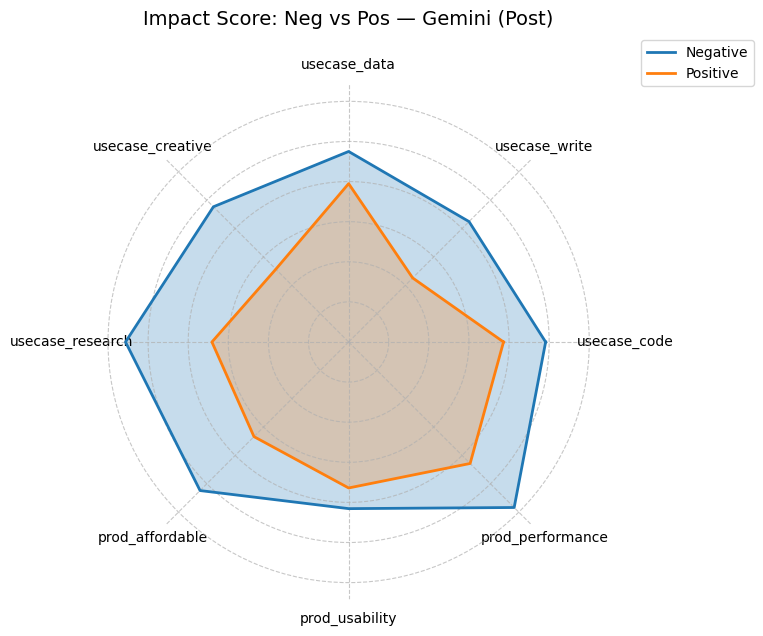

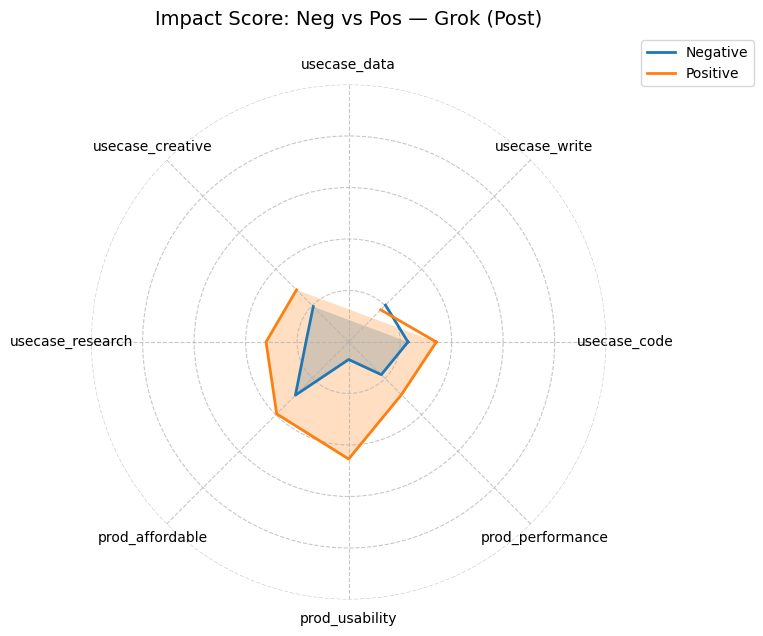

In [ ]:
def radar_chart(df_plot, title):
    if df_plot.empty or df_plot.sum().sum() == 0:
        print(f"No data: {title}"); return
    cats = list(df_plot.index); N = len(cats)
    angles = [n / N * 2 * np.pi for n in range(N)] + [0]
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    for label in df_plot.columns:
        vals = df_plot[label].tolist() + [df_plot[label].tolist()[0]]
        ax.plot(angles, vals, linewidth=2, label=label)
        ax.fill(angles, vals, alpha=0.25)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats, fontsize=10)
    ax.set_yticklabels([])
    mx = df_plot.values.max()
    ax.set_ylim(0, mx * 1.1 if mx > 0 else 1)
    ax.set_title(title, size=14, y=1.1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.spines["polar"].set_visible(False)
    plt.tight_layout(); plt.show()

# impact_post_pdf already computed above — no extra Spark job
for ai in AI_NAMES:
    d = {}
    for sv_str, sv_num in [("Negative", 1.0), ("Positive", 2.0)]:
        row = impact_post_pdf[
            (impact_post_pdf["AI_Name"] == ai) & (impact_post_pdf["sentiment"] == sv_num)
        ]
        d[sv_str] = row[TOPICS_8].values[0].tolist() if not row.empty else [0.0]*len(TOPICS_8)
    radar_chart(pd.DataFrame(d, index=TOPICS_8),
                f"Impact Score: Neg vs Pos — {ai} (Post)")

## Radar Charts — Negative vs Positive Impact per Brand (Comment)

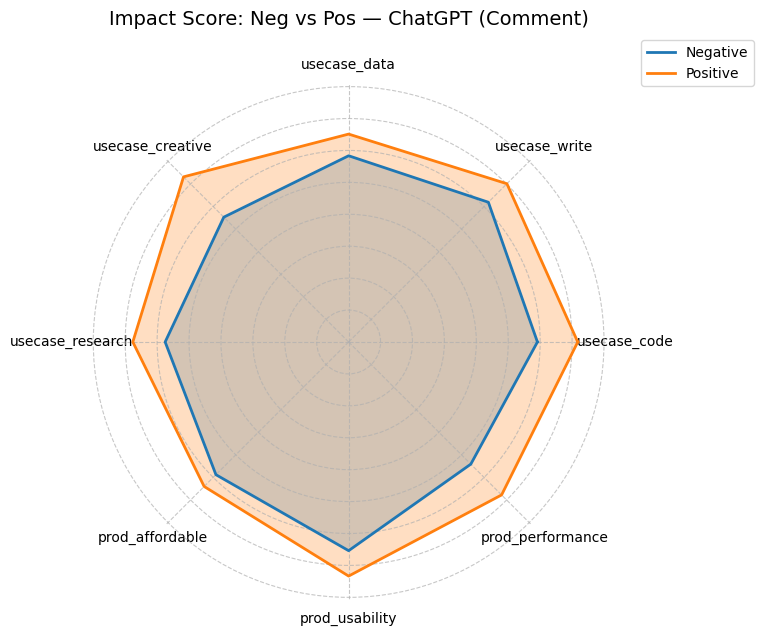

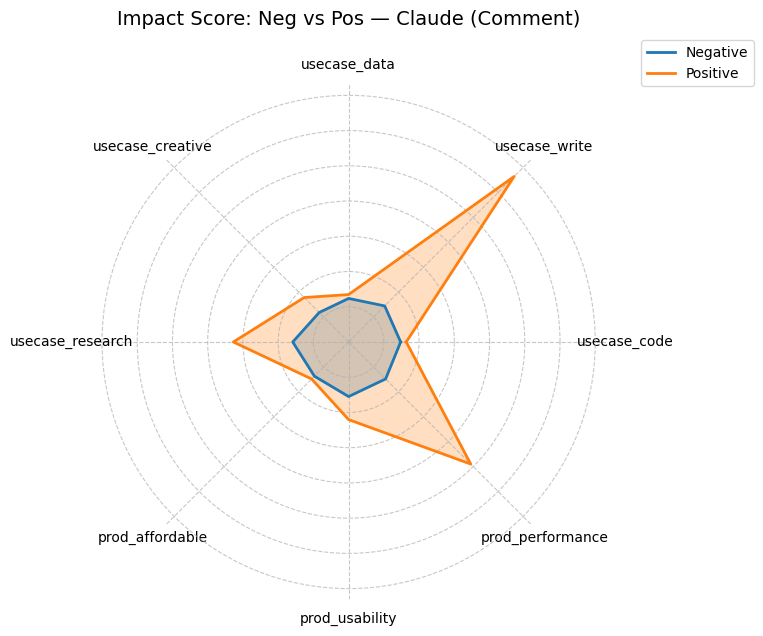

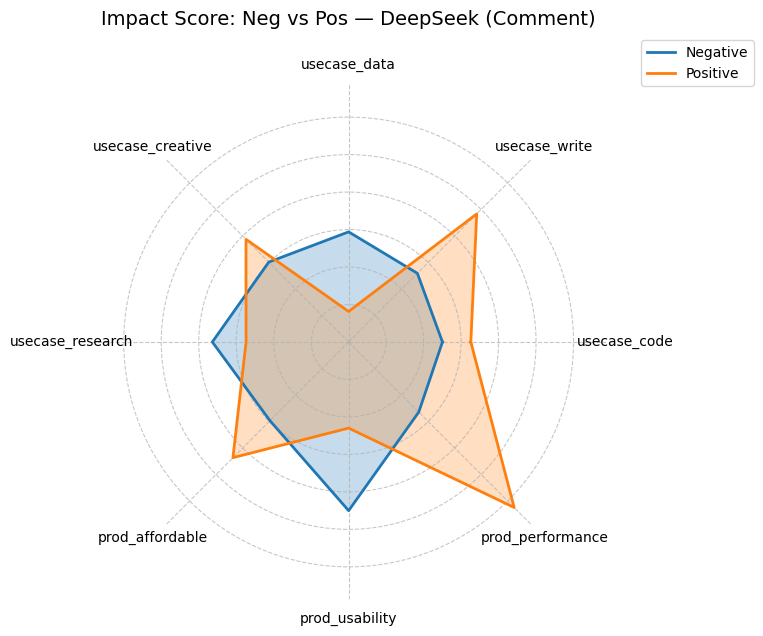

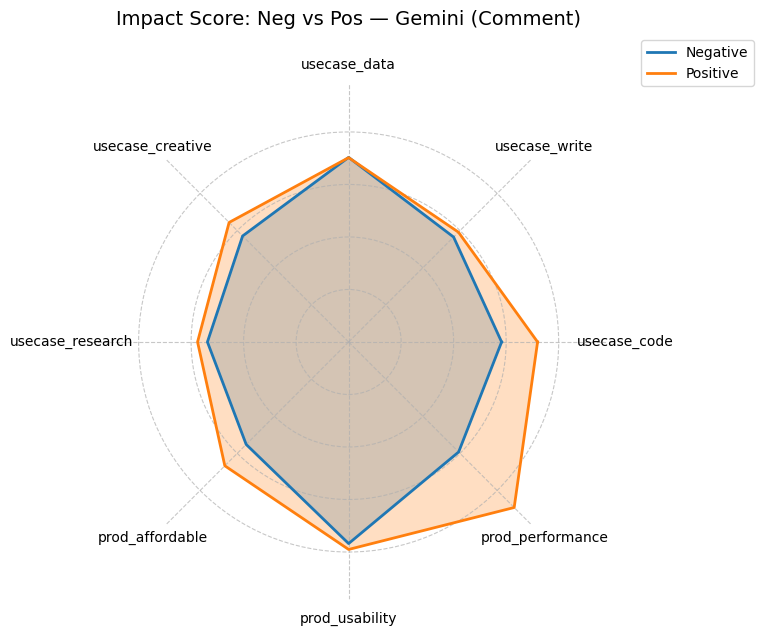

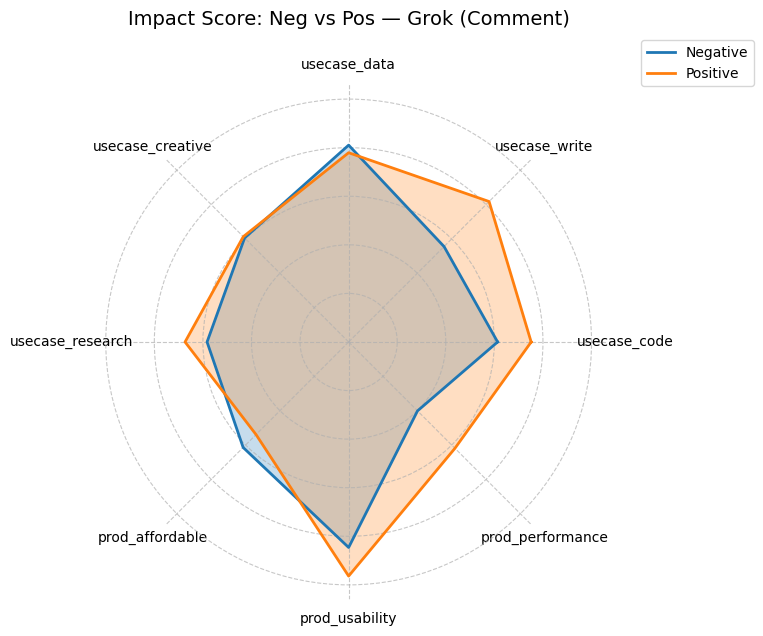

In [ ]:
# impact_com_pdf already computed above — no extra Spark job
for ai in AI_NAMES:
    d = {}
    for sv_str, sv_num in [("Negative", 1.0), ("Positive", 2.0)]:
        row = impact_com_pdf[
            (impact_com_pdf["AI_Name"] == ai) & (impact_com_pdf["sentiment"] == sv_num)
        ]
        d[sv_str] = row[TOPICS_8].values[0].tolist() if not row.empty else [0.0]*len(TOPICS_8)
    radar_chart(pd.DataFrame(d, index=TOPICS_8),
                f"Impact Score: Neg vs Pos — {ai} (Comment)")

## Radar Charts — Brand Comparison by Sentiment (Post)

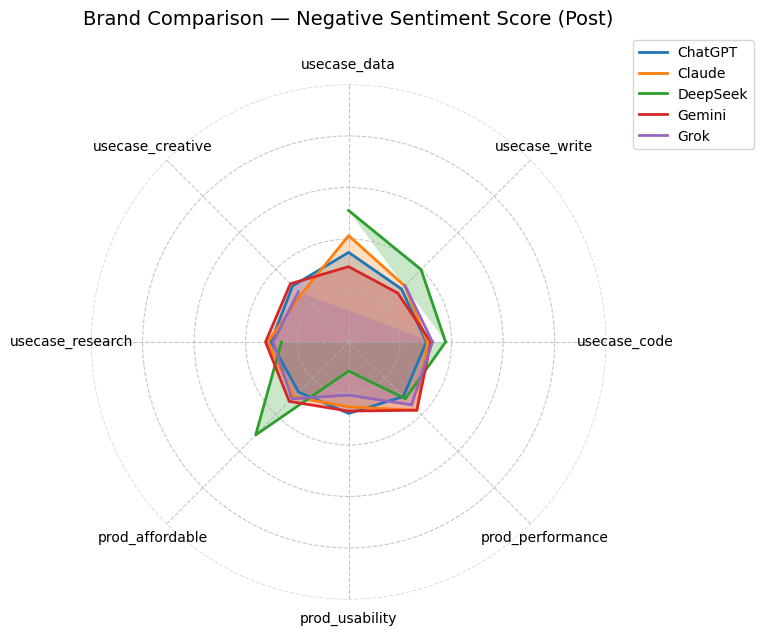

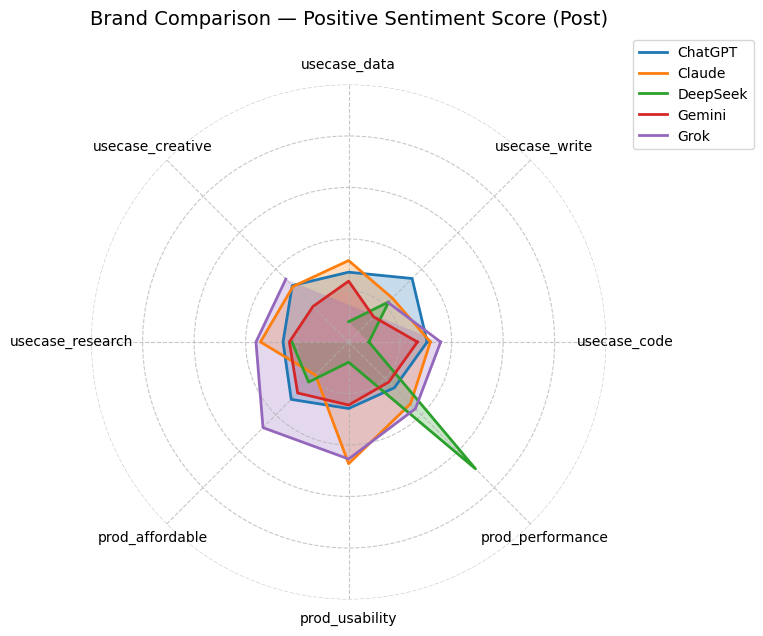

In [ ]:
# sent_post_pdf already computed above — no extra Spark job
for sv, sl in [("Negative", 1.0), ("Positive", 2.0)]:
    d = {}
    for ai in AI_NAMES:
        row = sent_post_pdf[
            (sent_post_pdf["AI_Name"] == ai) & (sent_post_pdf["sentiment"] == sl)
        ]
        d[ai] = row[TOPICS_8].values[0].tolist() if not row.empty else [0.0]*len(TOPICS_8)
    radar_chart(pd.DataFrame(d, index=TOPICS_8),
                f"Brand Comparison — {sv} Sentiment Score (Post)")

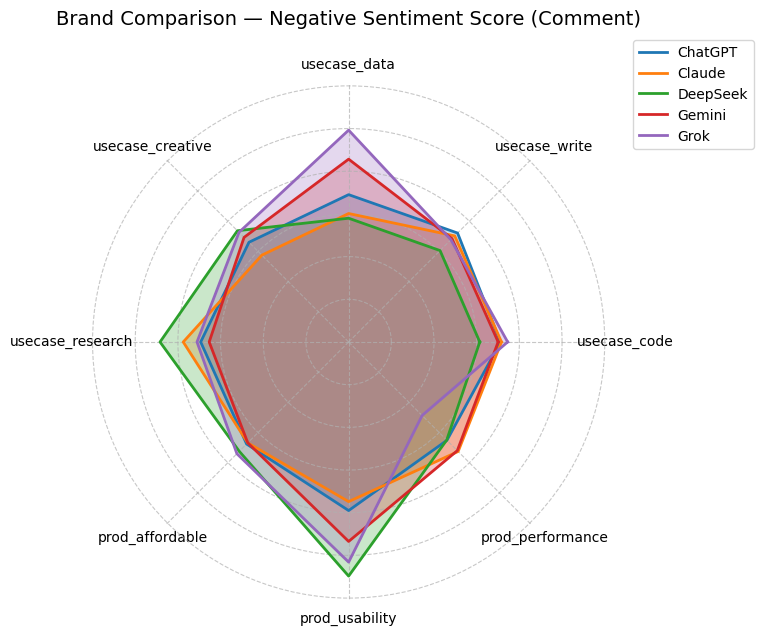

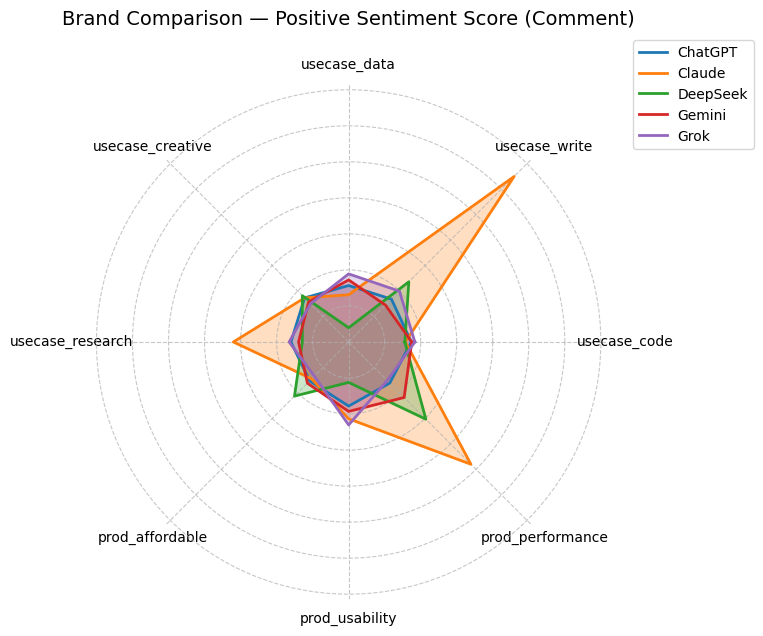

In [ ]:
# ONE Spark job to aggregate sentiment scores for comments
agg_sent_com = [
    F.avg(F.when(F.col(t) == 1, F.col("sentiment_score"))).alias(t) for t in TOPICS_8
]
sent_com_pdf = (comment
    .groupBy("AI_Name", "sentiment")
    .agg(*agg_sent_com)
    .toPandas())

# Generate radar charts for brand comparison by sentiment for comments
for sv, sl in [("Negative", 1.0), ("Positive", 2.0)]:
    d = {}
    for ai in AI_NAMES:
        row = sent_com_pdf[
            (sent_com_pdf["AI_Name"] == ai) & (sent_com_pdf["sentiment"] == sl)
        ]
        # Ensure that if row is empty, we still provide a list of zeros for consistency
        d[ai] = row[TOPICS_8].values[0].tolist() if not row.empty else [0.0]*len(TOPICS_8)

    # Check if 'd' contains any non-zero data before plotting
    # This handles cases where all sentiment scores for a given AI/sentiment are NaN or 0
    # The radar_chart function also has checks, but this provides a cleaner console output.
    if any(any(val for val in vals if pd.notna(val)) for vals in d.values()):
        radar_chart(pd.DataFrame(d, index=TOPICS_8),
                    f"Brand Comparison — {sv} Sentiment Score (Comment)")
    else:
        print(f"No significant data to plot for Brand Comparison — {sv} Sentiment Score (Comment)")

In [ ]:
print("Counting DeepSeek and Grok posts by topic and sentiment (1.0 Negative, 2.0 Positive):")

# Filter posts for DeepSeek and Grok, and sentiments 1.0 (Negative) and 2.0 (Positive)
filtered_post = post.filter(F.col("AI_Name").isin("DeepSeek", "Grok") & F.col("sentiment").isin(1.0, 2.0))

# Create aggregation expressions for each topic to count occurrences
agg_exprs_post = [F.sum(F.when(F.col(t) == 1, 1).otherwise(0)).alias(f"count_{t}") for t in TOPICS_8]

# Group by AI_Name and sentiment, then apply aggregation expressions
post_topic_sentiment_counts = filtered_post.groupBy("AI_Name", "sentiment").agg(*agg_exprs_post).orderBy("AI_Name", "sentiment")

print("\nPost counts by AI, Sentiment (Negative/Positive) and Topic:")
post_topic_sentiment_counts.show(truncate=False)


print("\nCounting DeepSeek and Grok comments by topic and sentiment (1.0 Negative, 2.0 Positive):")

# Filter comments for DeepSeek and Grok, and sentiments 1.0 (Negative) and 2.0 (Positive)
filtered_comment = comment.filter(F.col("AI_Name").isin("DeepSeek", "Grok") & F.col("sentiment").isin(1.0, 2.0))

# Create aggregation expressions for each topic to count occurrences
agg_exprs_comment = [F.sum(F.when(F.col(t) == 1, 1).otherwise(0)).alias(f"count_{t}") for t in TOPICS_8]

# Group by AI_Name and sentiment, then apply aggregation expressions
comment_topic_sentiment_counts = filtered_comment.groupBy("AI_Name", "sentiment").agg(*agg_exprs_comment).orderBy("AI_Name", "sentiment")

print("\nComment counts by AI, Sentiment (Negative/Positive) and Topic:")
comment_topic_sentiment_counts.show(truncate=False)

Counting DeepSeek and Grok posts by topic and sentiment (1.0 Negative, 2.0 Positive):

Post counts by AI, Sentiment (Negative/Positive) and Topic:
+--------+---------+------------------+-------------------+------------------+----------------------+----------------------+---------------------+--------------------+----------------------+
|AI_Name |sentiment|count_usecase_code|count_usecase_write|count_usecase_data|count_usecase_creative|count_usecase_research|count_prod_affordable|count_prod_usability|count_prod_performance|
+--------+---------+------------------+-------------------+------------------+----------------------+----------------------+---------------------+--------------------+----------------------+
|DeepSeek|1.0      |3                 |2                  |1                 |0                     |3                     |1                    |1                   |2                     |
|DeepSeek|2.0      |1                 |2                  |1                 |0          